In [1]:
# ============================================================
# EXPLORACIÓN COMPLETA DE LA BASE LATINOBARÓMETRO 2024
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# ------------------------------------------------------------
# 1. CARGA DE LA BASE LIMPIA
# ------------------------------------------------------------
path = '/Users/usuario/Documents/UBA/2025/Trimestre 3/Taller de programación/TPs/Exposiciones/Exposición 2/latinobarometro24_basefinal.csv'

print("="*70)
print("EXPLORACIÓN DE LATINOBARÓMETRO 2024 - BASE FINAL")
print("="*70)

try:
    df = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    print(f"✓ Base cargada exitosamente")
    print(f"✓ Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
except FileNotFoundError:
    print(f"✗ Error: No se encuentra el archivo en la ruta especificada")
    print(f"Ruta buscada: {path}")
    raise
except Exception as e:
    print(f"✗ Error al cargar el archivo: {e}")
    raise

EXPLORACIÓN DE LATINOBARÓMETRO 2024 - BASE FINAL
✓ Base cargada exitosamente
✓ Dimensiones: 19214 filas × 40 columnas


In [3]:
# ------------------------------------------------------------
# 2. INSPECCIÓN INICIAL
# ------------------------------------------------------------
print("\n" + "="*70)
print("2. INSPECCIÓN INICIAL DE LA BASE")
print("="*70)

# Información general
print("\n INFORMACIÓN GENERAL:")
print("-"*40)
print(df.info())

# Primeras y últimas filas
print("\n PRIMERAS 3 FILAS:")
print("-"*40)
print(df.head(3))

print("\n ÚLTIMAS 3 FILAS:")
print("-"*40)
print(df.tail(3))

# Nombres de columnas
print("\n LISTA DE COLUMNAS:")
print("-"*40)
cols = df.columns.tolist()
print(f"Total columnas: {len(cols)}")
print("\nPrimeras 20 columnas:")
for i, col in enumerate(cols[:20], 1):
    print(f"{i:2d}. {col}")

if len(cols) > 20:
    print(f"... y {len(cols)-20} columnas más")



2. INSPECCIÓN INICIAL DE LA BASE

📊 INFORMACIÓN GENERAL:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19214 entries, 0 to 19213
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   pais                               19214 non-null  float64
 1   sexo                               19214 non-null  object 
 2   edad                               19210 non-null  float64
 3   satisfaccion_vida                  19067 non-null  object 
 4   situacion_pais                     18768 non-null  object 
 5   economia_actual                    19117 non-null  object 
 6   economia_vs12m                     19037 non-null  object 
 7   economia_12m_futuro                18194 non-null  object 
 8   confianza_interpersonal            18843 non-null  object 
 9   preferencia_democracia             17952 non-null  object 
 10  satisfaccion_democr


3. ANÁLISIS DE VALORES FALTANTES (MISSING VALUES)

📈 RESUMEN DE MISSING VALUES:
----------------------------------------
• Total de celdas en la base: 768,560
• Celdas con datos faltantes: 31,400 (4.1%)
• Variables sin missing values: 3
• Variables con >20% missing: 2
• Variables con >50% missing: 0

🏆 TOP 15 VARIABLES CON MÁS VALORES FALTANTES:
----------------------------------------
 1. corrupcion_0a10                 4,708 ( 24.5%)
 2. ideologia_izq_der               4,138 ( 21.5%)
 3. nivel_democratico_pais          3,621 ( 18.8%)
 4. raza_etnia                      1,825 (  9.5%)
 5. mercado_unico_desarrollo        1,333 (  6.9%)
 6. preferencia_democracia          1,262 (  6.6%)
 7. educacion_anios                 1,117 (  5.8%)
 8. elecciones_limpias              1,024 (  5.3%)
 9. economia_12m_futuro             1,020 (  5.3%)
10. inmigrantes_aumentan_crimen       888 (  4.6%)
11. aprueba_presidente                819 (  4.3%)
12. impacto_inmigracion_pais          702 (  3.7%

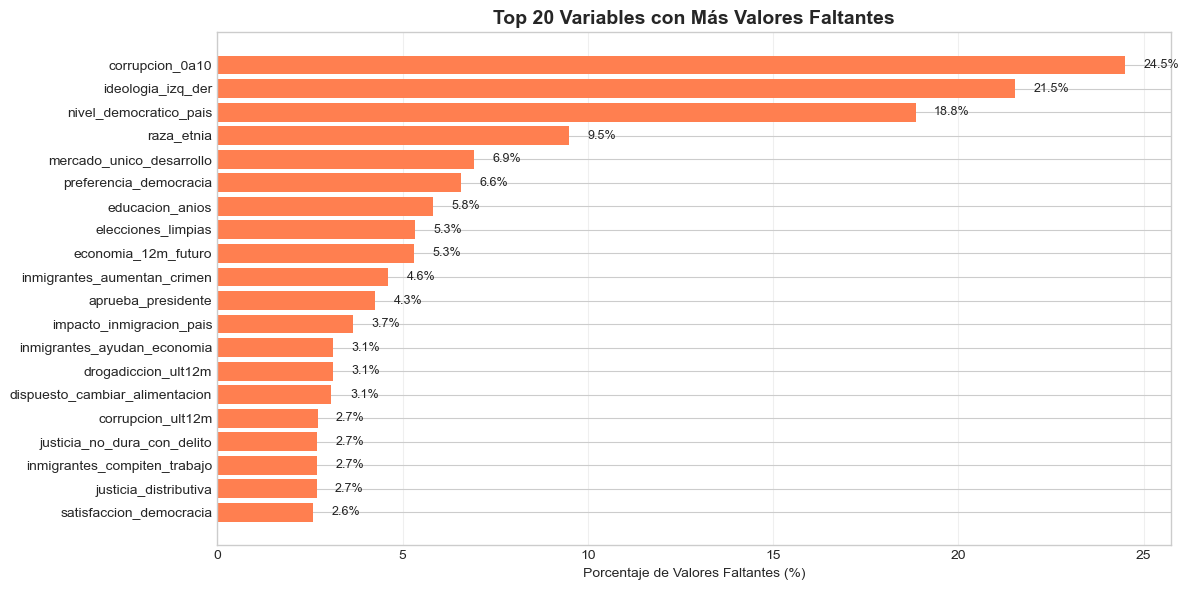

In [4]:
# ------------------------------------------------------------
# 3. ANÁLISIS DE VALORES FALTANTES
# ------------------------------------------------------------
print("\n" + "="*70)
print("3. ANÁLISIS DE VALORES FALTANTES (MISSING VALUES)")
print("="*70)

# Calcular porcentaje de missing por columna
missing_series = df.isna().sum()
missing_pct = (missing_series / len(df)) * 100

# Crear DataFrame ordenado
missing_df = pd.DataFrame({
    'Variable': missing_series.index,
    'N_Missing': missing_series.values,
    '%_Missing': missing_pct.values
}).sort_values('%_Missing', ascending=False).reset_index(drop=True)

print(f"\n RESUMEN DE MISSING VALUES:")
print("-"*40)
print(f"• Total de celdas en la base: {df.shape[0] * df.shape[1]:,}")
print(f"• Celdas con datos faltantes: {df.isna().sum().sum():,} ({df.isna().sum().sum()/(df.shape[0]*df.shape[1])*100:.1f}%)")
print(f"• Variables sin missing values: {(missing_df['N_Missing'] == 0).sum()}")
print(f"• Variables con >20% missing: {(missing_df['%_Missing'] > 20).sum()}")
print(f"• Variables con >50% missing: {(missing_df['%_Missing'] > 50).sum()}")

# Top 15 variables con más missing
print("\n TOP 15 VARIABLES CON MÁS VALORES FALTANTES:")
print("-"*40)
top_missing = missing_df.head(15)
for i, row in top_missing.iterrows():
    print(f"{i+1:2d}. {row['Variable']:30s} {row['N_Missing']:6,} ({row['%_Missing']:5.1f}%)")

# Gráfico de missing values
plt.figure(figsize=(12, 6))
top_missing_plot = missing_df.head(20).sort_values('%_Missing')
bars = plt.barh(top_missing_plot['Variable'], top_missing_plot['%_Missing'], color='coral')
plt.xlabel('Porcentaje de Valores Faltantes (%)')
plt.title('Top 20 Variables con Más Valores Faltantes', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Añadir etiquetas de valor
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()



4. ANÁLISIS DE VARIABLES NUMÉRICAS

🔢 VARIABLES NUMÉRICAS IDENTIFICADAS: 7
----------------------------------------
 1. pais
 2. edad
 3. aprueba_presidente
 4. ideologia_izq_der
 5. nivel_democratico_pais
 6. corrupcion_0a10
 7. educacion_anios

📊 ESTADÍSTICAS DESCRIPTIVAS (principales variables numéricas):
----------------------------------------
                          count  %_missing   mean    std   min    25%   50%  \
edad                    19210.0        0.0  41.76  16.80  16.0  27.00  40.0   
ideologia_izq_der       15076.0       21.5   5.28   3.16   0.0   3.75   5.0   
nivel_democratico_pais  15593.0       18.8   5.86   5.15   1.0   4.00   5.0   
corrupcion_0a10         14506.0       24.5   6.84   2.96   0.0   5.00   7.0   
educacion_anios         18097.0        5.8  10.78   4.39   1.0   7.00  12.0   

                         75%   max  
edad                    55.0  95.0  
ideologia_izq_der        7.0  10.0  
nivel_democratico_pais   7.0  96.0  
corrupcion_0a10         1

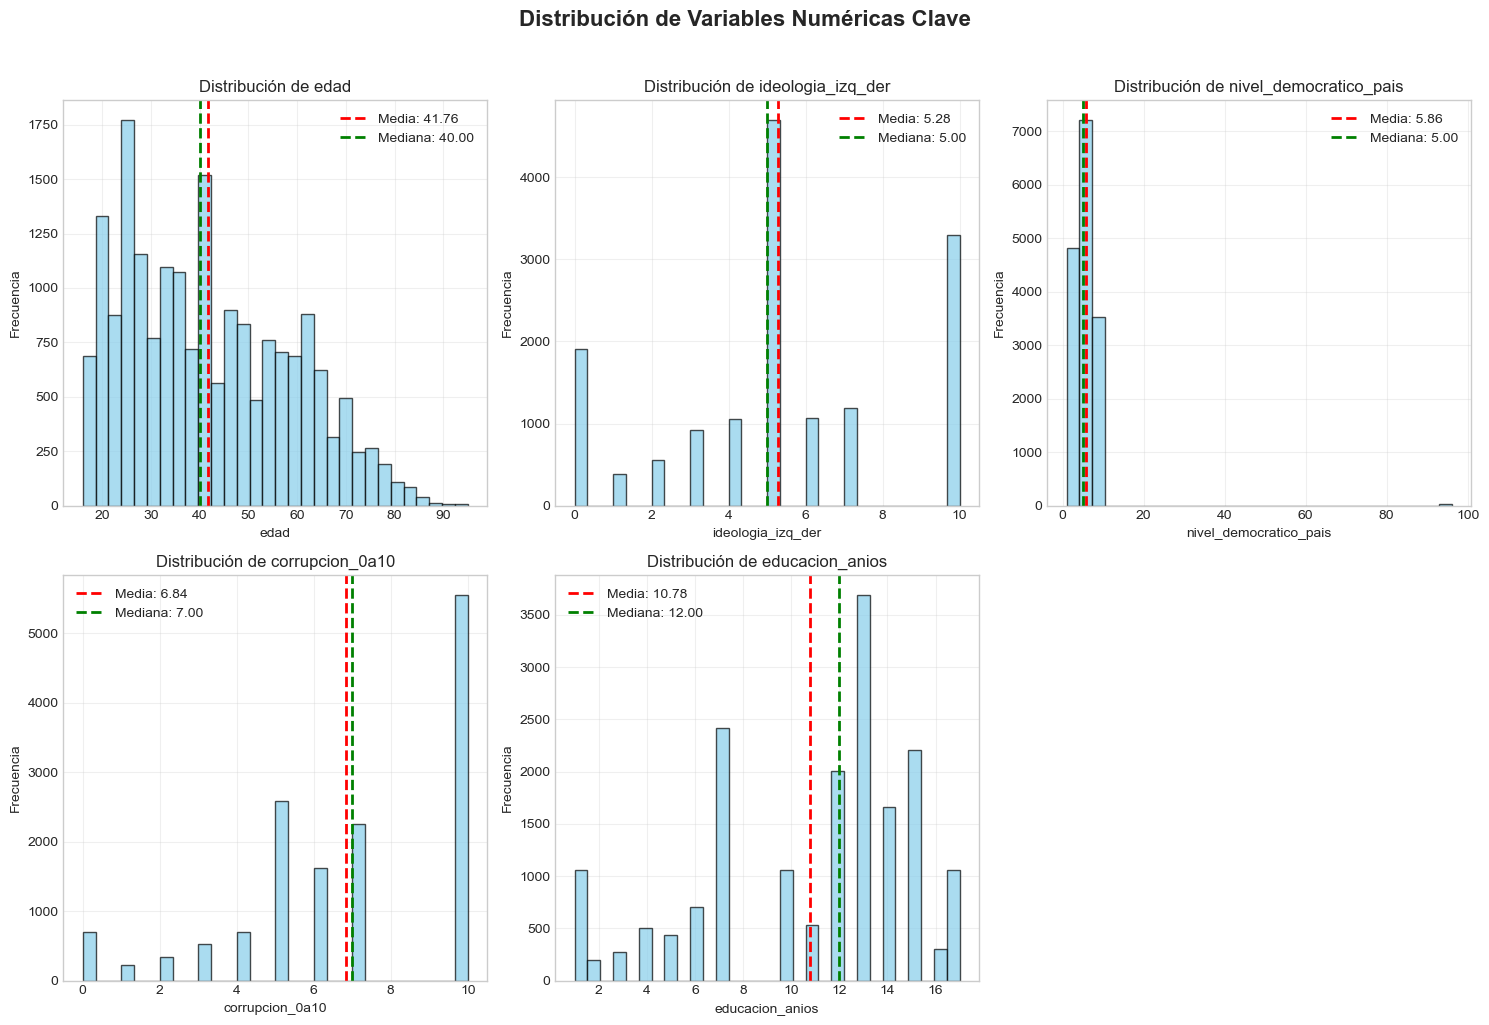

In [6]:
# ------------------------------------------------------------
# 4. ANÁLISIS DE VARIABLES NUMÉRICAS
# ------------------------------------------------------------
print("\n" + "="*70)
print("4. ANÁLISIS DE VARIABLES NUMÉRICAS")
print("="*70)

# Identificar variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n VARIABLES NUMÉRICAS IDENTIFICADAS: {len(numeric_cols)}")
print("-"*40)
for i, col in enumerate(numeric_cols[:25], 1):
    print(f"{i:2d}. {col}")

if len(numeric_cols) > 25:
    print(f"... y {len(numeric_cols)-25} más")

# Estadísticas descriptivas básicas
print("\n ESTADÍSTICAS DESCRIPTIVAS (principales variables numéricas):")
print("-"*40)

if len(numeric_cols) > 0:
    # Seleccionar algunas numéricas importantes (o todas si son pocas)
    if 'edad' in df.columns:
        num_to_show = ['edad', 'ideologia_izq_der', 'nivel_democratico_pais', 
                      'corrupcion_0a10', 'educacion_anios']
        num_to_show = [col for col in num_to_show if col in df.columns]
    else:
        num_to_show = numeric_cols[:10]  # Primeras 10 si no encontramos las esperadas
    
    desc_stats = df[num_to_show].describe().T.round(2)
    desc_stats['%_missing'] = (df[num_to_show].isna().sum() / len(df) * 100).round(1)
    desc_stats = desc_stats[['count', '%_missing', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
    print(desc_stats)
    
    # Histogramas de variables numéricas clave
    print("\n📈 HISTOGRAMAS DE VARIABLES NUMÉRICAS CLAVE:")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(num_to_show[:6]):
        if col in df.columns:
            ax = axes[i]
            # Eliminar NaN para el histograma
            data = df[col].dropna()
            
            if len(data) > 0:
                ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
                ax.set_title(f'Distribución de {col}', fontsize=12)
                ax.set_xlabel(col)
                ax.set_ylabel('Frecuencia')
                ax.grid(alpha=0.3)
                
                # Añadir líneas de media y mediana
                ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data.mean():.2f}')
                ax.axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {data.median():.2f}')
                ax.legend()
    
    # Ocultar ejes vacíos
    for i in range(len(num_to_show[:6]), 6):
        axes[i].set_visible(False)
    
    plt.suptitle('Distribución de Variables Numéricas Clave', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [7]:
# ------------------------------------------------------------
# 5. ANÁLISIS DE VARIABLES CATEGÓRICAS
# ------------------------------------------------------------
print("\n" + "="*70)
print("5. ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*70)

# Identificar variables categóricas
# Primero buscar columnas con _lbl (etiquetadas)
categorical_lbl = [col for col in df.columns if col.endswith('_lbl')]
print(f"\n  VARIABLES CATEGÓRICAS ETIQUETADAS (_lbl): {len(categorical_lbl)}")
print("-"*40)

# Mostrar algunas con sus categorías
for i, col in enumerate(categorical_lbl[:10], 1):
    unique_vals = df[col].dropna().unique()
    print(f"{i:2d}. {col:30s} → {len(unique_vals)} categorías")
    if len(unique_vals) <= 5:  # Mostrar categorías si son pocas
        print(f"     {', '.join([str(v) for v in unique_vals[:5]])}")

if len(categorical_lbl) > 10:
    print(f"... y {len(categorical_lbl)-10} más")

# También buscar variables object/string que no sean _lbl
object_cols = [col for col in df.select_dtypes(include=['object']).columns 
               if not col.endswith('_lbl')]
if object_cols:
    print(f"\n VARIABLES OBJECT/TEXTO (sin _lbl): {len(object_cols)}")
    print("-"*40)
    for i, col in enumerate(object_cols[:5], 1):
        unique_vals = df[col].dropna().unique()
        print(f"{i:2d}. {col:30s} → {len(unique_vals)} valores únicos")
        if len(unique_vals) <= 3:
            print(f"     Ejemplos: {', '.join([str(v) for v in unique_vals[:3]])}")

# Análisis de frecuencia de variables categóricas clave
print("\n FRECUENCIAS DE VARIABLES CATEGÓRICAS CLAVE:")
print("-"*40)

# Lista de variables categóricas importantes para análisis político
key_categorical_vars = []
for var in ['sexo_lbl', 'satisfaccion_democracia_lbl', 'preferencia_democracia_lbl', 
            'justicia_distributiva_lbl', 'elecciones_limpias_lbl', 'clase_social_lbl',
            'situacion_pais_lbl', 'confianza_interpersonal_lbl']:
    if var in df.columns:
        key_categorical_vars.append(var)

for var in key_categorical_vars[:6]:  # Analizar primeras 6 para no saturar
    print(f"\n {var}:")
    print("-" * 30)
    
    # Calcular frecuencias
    freq = df[var].value_counts(dropna=False)
    freq_pct = df[var].value_counts(normalize=True, dropna=False) * 100
    
    # Crear DataFrame para mostrar
    freq_df = pd.DataFrame({
        'Categoría': freq.index,
        'Frecuencia': freq.values,
        '%': freq_pct.values.round(1)
    })
    
    # Mostrar las principales categorías
    print(freq_df.head(10).to_string(index=False))
    
    if len(freq) > 10:
        print(f"... y {len(freq)-10} categorías más")
    
    print(f"Total válidos: {df[var].notna().sum():,} ({df[var].notna().sum()/len(df)*100:.1f}%)")
    print(f"Missing: {df[var].isna().sum():,} ({df[var].isna().sum()/len(df)*100:.1f}%)")



5. ANÁLISIS DE VARIABLES CATEGÓRICAS

🏷️  VARIABLES CATEGÓRICAS ETIQUETADAS (_lbl): 0
----------------------------------------

📝 VARIABLES OBJECT/TEXTO (sin _lbl): 33
----------------------------------------
 1. sexo                           → 2 valores únicos
     Ejemplos: Mujer, Hombre
 2. satisfaccion_vida              → 4 valores únicos
 3. situacion_pais                 → 3 valores únicos
     Ejemplos: En retroceso, Estancado, Progresando
 4. economia_actual                → 5 valores únicos
 5. economia_vs12m                 → 5 valores únicos

📊 FRECUENCIAS DE VARIABLES CATEGÓRICAS CLAVE:
----------------------------------------



6. ANÁLISIS POR PAÍS

🌎 VARIABLE DE PAÍS IDENTIFICADA: 'pais'
----------------------------------------
Número de países distintos: 17
Muestra total: 19,214

📊 DISTRIBUCIÓN POR PAÍS (Top 10):
----------------------------------------
 Código  Frecuencia    %
   32.0        1210 6.30
   76.0        1204 6.27
  484.0        1200 6.25
  170.0        1200 6.25
  152.0        1200 6.25
  862.0        1200 6.25
  218.0        1200 6.25
  600.0        1200 6.25
  604.0        1200 6.25
  858.0        1200 6.25


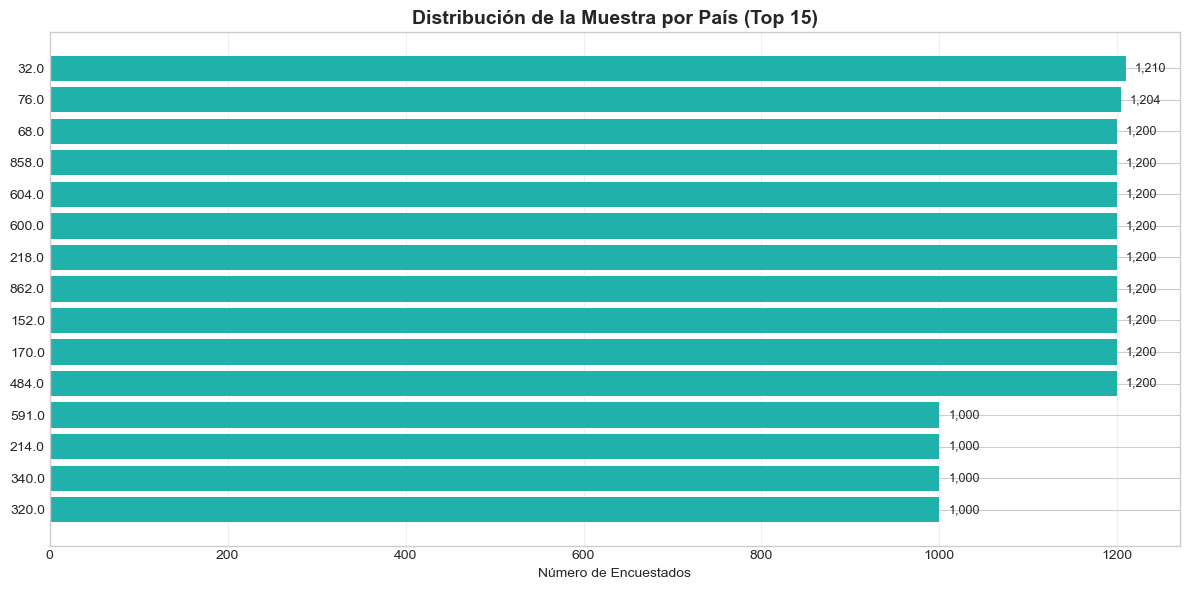


📐 REPRESENTATIVIDAD DE LA MUESTRA:
----------------------------------------
• País con mayor muestra: 32.0 (1,210.0 casos, 6.3%)
• País con menor muestra: 222.0 (1,000.0 casos, 5.2%)
• Diferencia entre mayor y menor: 210.0 casos


In [8]:
# ------------------------------------------------------------
# 6. ANÁLISIS DE PAÍSES (IDENPA)
# ------------------------------------------------------------
print("\n" + "="*70)
print("6. ANÁLISIS POR PAÍS")
print("="*70)

# Verificar si tenemos variable de país
country_var = None
for var in ['idenpa', 'pais', 'IDENPA', 'PAIS']:
    if var in df.columns:
        country_var = var
        break

if country_var:
    print(f"\n VARIABLE DE PAÍS IDENTIFICADA: '{country_var}'")
    print("-"*40)
    
    # Frecuencia por país
    country_counts = df[country_var].value_counts()
    country_pct = df[country_var].value_counts(normalize=True) * 100
    
    # Crear DataFrame
    country_df = pd.DataFrame({
        'Código': country_counts.index,
        'Frecuencia': country_counts.values,
        '%': country_pct.values.round(2)
    }).sort_values('Frecuencia', ascending=False)
    
    print(f"Número de países distintos: {len(country_df)}")
    print(f"Muestra total: {country_df['Frecuencia'].sum():,}")
    print("\n DISTRIBUCIÓN POR PAÍS (Top 10):")
    print("-"*40)
    print(country_df.head(10).to_string(index=False))
    
    # Gráfico de distribución por país
    plt.figure(figsize=(12, 6))
    top_countries = country_df.head(15).sort_values('Frecuencia')
    bars = plt.barh(top_countries['Código'].astype(str), top_countries['Frecuencia'], color='lightseagreen')
    plt.xlabel('Número de Encuestados')
    plt.title('Distribución de la Muestra por País (Top 15)', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # Añadir etiquetas
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 10, bar.get_y() + bar.get_height()/2, 
                 f'{int(width):,}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Análisis de representatividad
    print(f"\n REPRESENTATIVIDAD DE LA MUESTRA:")
    print("-"*40)
    print(f"• País con mayor muestra: {country_df.iloc[0]['Código']} ({country_df.iloc[0]['Frecuencia']:,} casos, {country_df.iloc[0]['%']:.1f}%)")
    print(f"• País con menor muestra: {country_df.iloc[-1]['Código']} ({country_df.iloc[-1]['Frecuencia']:,} casos, {country_df.iloc[-1]['%']:.1f}%)")
    print(f"• Diferencia entre mayor y menor: {country_df.iloc[0]['Frecuencia'] - country_df.iloc[-1]['Frecuencia']:,} casos")
    
else:
    print("  No se encontró variable de país en la base")



7. ANÁLISIS DE RELACIONES BÁSICAS

🔗 MATRIZ DE CORRELACIÓN (variables numéricas):
----------------------------------------

Matriz de correlación:
                        edad  ideologia_izq_der  nivel_democratico_pais  \
edad                    1.00               0.06                    0.06   
ideologia_izq_der       0.06               1.00                    0.09   
nivel_democratico_pais  0.06               0.09                    1.00   
corrupcion_0a10        -0.01               0.05                   -0.12   
educacion_anios        -0.26              -0.07                   -0.07   

                        corrupcion_0a10  educacion_anios  
edad                              -0.01            -0.26  
ideologia_izq_der                  0.05            -0.07  
nivel_democratico_pais            -0.12            -0.07  
corrupcion_0a10                    1.00            -0.00  
educacion_anios                   -0.00             1.00  


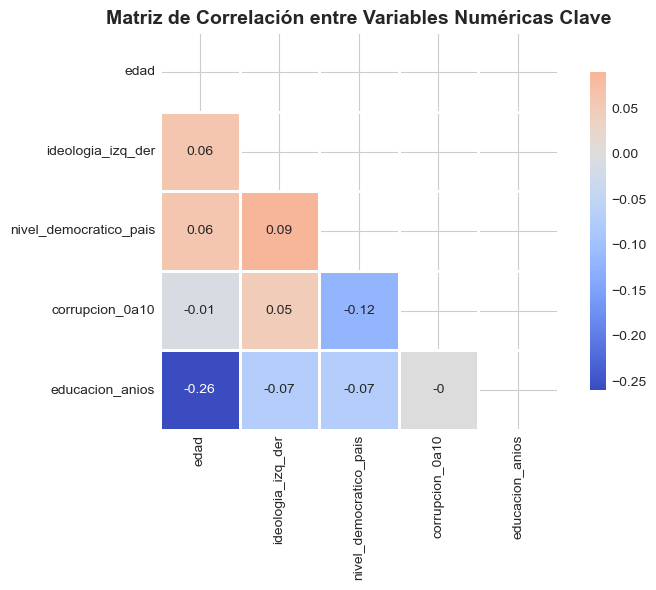


💡 CORRELACIONES FUERTES (|r| > 0.3):
----------------------------------------
No se encontraron correlaciones fuertes (|r| > 0.3)

8. ANÁLISIS PARA IDENTIFICACIÓN DE PERFILES POLÍTICOS

🎯 VARIABLES POTENCIALES PARA CLUSTERING DE PERFILES POLÍTICOS:
----------------------------------------
• Satisfacción Democrática:
    - satisfaccion_democracia (numérica, 2.6% missing)
• Preferencia Regímenes:
    - preferencia_democracia (numérica, 6.6% missing)
• Ideología:
    - ideologia_izq_der (numérica, 21.5% missing)
• Justicia:
    - justicia_distributiva (numérica, 2.7% missing)
• Confianza Institucional:
    - elecciones_limpias (numérica, 5.3% missing)
• Evaluación Económica:
    - situacion_pais (numérica, 2.3% missing)
    - economia_actual (numérica, 0.5% missing)
• Confianza Interpersonal:
    - confianza_interpersonal (numérica, 1.9% missing)
• Actitudes Sociales:
    - inmigrantes_ayudan_economia (numérica, 3.1% missing)

✅ Total de variables políticas identificadas: 9

📊 COMPLETITU

In [9]:
# ------------------------------------------------------------
# 7. ANÁLISIS DE RELACIONES BÁSICAS
# ------------------------------------------------------------
print("\n" + "="*70)
print("7. ANÁLISIS DE RELACIONES BÁSICAS")
print("="*70)

# Matriz de correlación para variables numéricas clave
print("\n MATRIZ DE CORRELACIÓN (variables numéricas):")
print("-"*40)

if len(numeric_cols) > 1:
    # Seleccionar numéricas relevantes para análisis político
    corr_vars = []
    for var in ['edad', 'ideologia_izq_der', 'nivel_democratico_pais', 
                'corrupcion_0a10', 'educacion_anios']:
        if var in df.columns:
            corr_vars.append(var)
    
    if len(corr_vars) > 2:
        # Calcular matriz de correlación
        corr_matrix = df[corr_vars].corr().round(2)
        
        print("\nMatriz de correlación:")
        print(corr_matrix)
        
        # Visualizar matriz de correlación
        plt.figure(figsize=(8, 6))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', 
                   center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
        plt.title('Matriz de Correlación entre Variables Numéricas Clave', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Identificar correlaciones fuertes
        print("\n CORRELACIONES FUERTES (|r| > 0.3):")
        print("-"*40)
        strong_corrs = []
        for i in range(len(corr_vars)):
            for j in range(i+1, len(corr_vars)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.3:
                    strong_corrs.append((corr_vars[i], corr_vars[j], corr_val))
        
        if strong_corrs:
            for var1, var2, corr in strong_corrs:
                direction = "positiva" if corr > 0 else "negativa"
                print(f"• {var1} ↔ {var2}: r = {corr:.2f} ({direction})")
        else:
            print("No se encontraron correlaciones fuertes (|r| > 0.3)")
else:
    print("No hay suficientes variables numéricas para análisis de correlación")

# ------------------------------------------------------------
# 8. ANÁLISIS ESPECÍFICO PARA PERFILES POLÍTICOS
# ------------------------------------------------------------
print("\n" + "="*70)
print("8. ANÁLISIS PARA IDENTIFICACIÓN DE PERFILES POLÍTICOS")
print("="*70)

# Identificar variables clave para clustering político
political_vars = []
print("\n VARIABLES POTENCIALES PARA CLUSTERING DE PERFILES POLÍTICOS:")
print("-"*40)

# Categorías de variables políticas
political_categories = {
    "Satisfacción Democrática": ["satisfaccion_democracia", "satisfaccion_democracia_lbl"],
    "Preferencia Regímenes": ["preferencia_democracia", "preferencia_democracia_lbl"],
    "Ideología": ["ideologia_izq_der", "ideologia_bandas"],
    "Justicia": ["justicia_distributiva", "justicia_distributiva_lbl"],
    "Confianza Institucional": ["elecciones_limpias", "elecciones_limpias_lbl"],
    "Evaluación Económica": ["situacion_pais", "situacion_pais_lbl", "economia_actual", "economia_actual_lbl"],
    "Confianza Interpersonal": ["confianza_interpersonal", "confianza_interpersonal_lbl"],
    "Actitudes Sociales": ["inmigrantes_ayudan_economia", "inmigrantes_ayudan_economia_lbl"]
}

for category, vars_list in political_categories.items():
    available_vars = [v for v in vars_list if v in df.columns]
    if available_vars:
        political_vars.extend(available_vars)
        print(f"• {category}:")
        for var in available_vars:
            missing_pct = df[var].isna().sum() / len(df) * 100
            if var.endswith('_lbl'):
                n_cats = len(df[var].dropna().unique())
                print(f"    - {var} ({n_cats} categorías, {missing_pct:.1f}% missing)")
            else:
                print(f"    - {var} (numérica, {missing_pct:.1f}% missing)")

print(f"\n Total de variables políticas identificadas: {len(political_vars)}")

# Verificar completitud de casos para clustering
print("\n COMPLETITUD DE DATOS PARA ANÁLISIS:")
print("-"*40)

# Crear subset con variables políticas
if political_vars:
    df_political = df[political_vars].copy()
    
    # Calcular casos completos
    complete_cases = df_political.notna().all(axis=1).sum()
    complete_pct = complete_cases / len(df) * 100
    
    print(f"• Variables seleccionadas: {len(political_vars)}")
    print(f"• Casos completos (sin missing en ninguna variable política): {complete_cases:,}")
    print(f"• Porcentaje de casos completos: {complete_pct:.1f}%")
    
    if complete_pct < 50:
        print("  ADVERTENCIA: Menos del 50% de casos completos. Puede requerir imputación.")
    else:
        print("✓ Buen porcentaje de casos completos para análisis.")

In [10]:
# ------------------------------------------------------------
# 9. RESUMEN EJECUTIVO
# ------------------------------------------------------------
print("\n" + "="*70)
print("9. RESUMEN EJECUTIVO DE LA EXPLORACIÓN")
print("="*70)

print(f"""
 RESUMEN ESTADÍSTICO:
• Total de observaciones: {df.shape[0]:,}
• Total de variables: {df.shape[1]}
• Variables numéricas: {len(numeric_cols)}
• Variables categóricas (_lbl): {len(categorical_lbl)}

 CALIDAD DE DATOS:
• Porcentaje total de celdas con datos: {(1 - df.isna().sum().sum()/(df.shape[0]*df.shape[1]))*100:.1f}%
• Variables sin missing: {(missing_df['N_Missing'] == 0).sum()}
• Variables con >20% missing: {(missing_df['%_Missing'] > 20).sum()}

 PARA ANÁLISIS DE PERFILES POLÍTICOS:
• Variables políticas identificadas: {len(political_vars)}
• Variables clave disponibles: {'✓' if any('satisfaccion_democracia' in v for v in political_vars) else '✗'} Satisfacción democrática
                               {'✓' if any('preferencia_democracia' in v for v in political_vars) else '✗'} Preferencia por democracia
                               {'✓' if any('ideologia' in v for v in political_vars) else '✗'} Ideología izquierda-derecha
                               {'✓' if any('justicia_distributiva' in v for v in political_vars) else '✗'} Justicia distributiva

🔧 RECOMENDACIONES PARA PRÓXIMOS PASOS:
1. {"Imputar missing values" if complete_pct < 70 else "Usar casos completos"} para clustering
2. {"Usar K-modes (datos categóricos)" if len(categorical_lbl) > len(numeric_cols) else "Usar K-means o K-modes con dummies"}
3. Seleccionar 6-8 variables políticas clave para clustering
4. Considerar análisis por país o región

 LA BASE ESTÁ LISTA PARA: Clustering (K-modes/K-means) + LASSO
""")



9. RESUMEN EJECUTIVO DE LA EXPLORACIÓN

📈 RESUMEN ESTADÍSTICO:
• Total de observaciones: 19,214
• Total de variables: 40
• Variables numéricas: 7
• Variables categóricas (_lbl): 0

📊 CALIDAD DE DATOS:
• Porcentaje total de celdas con datos: 95.9%
• Variables sin missing: 3
• Variables con >20% missing: 2

🎯 PARA ANÁLISIS DE PERFILES POLÍTICOS:
• Variables políticas identificadas: 9
• Variables clave disponibles: ✓ Satisfacción democrática
                               ✓ Preferencia por democracia
                               ✓ Ideología izquierda-derecha
                               ✓ Justicia distributiva

🔧 RECOMENDACIONES PARA PRÓXIMOS PASOS:
1. Imputar missing values para clustering
2. Usar K-means o K-modes con dummies
3. Seleccionar 6-8 variables políticas clave para clustering
4. Considerar análisis por país o región

✅ LA BASE ESTÁ LISTA PARA: Clustering (K-modes/K-means) + LASSO



In [11]:
###################################
######### LASSO
####################################

In [12]:
# ------------------------------------------------------------
# 1. CARGA DE DATOS
# ------------------------------------------------------------
path = '/Users/usuario/Documents/UBA/2025/Trimestre 3/Taller de programación/TPs/Exposiciones/Exposición 2/latinobarometro24_basefinal.csv'
df = pd.read_csv(path, encoding='utf-8-sig')
print(f"Base cargada: {df.shape[0]} filas × {df.shape[1]} columnas")


Base cargada: 19214 filas × 40 columnas


In [21]:
# ============================================================
# BLOQUE 1A: CONFIGURACIÓN Y ANÁLISIS INICIAL DE MISSING
# ============================================================

print("="*60)
print("BLOQUE 1A: ANÁLISIS DE MISSING VALUES")
print("="*60)

import pandas as pd
import numpy as np

# 1. Estadísticas básicas
total_celdas = df.size
missing_total = df.isna().sum().sum()
pct_missing = (missing_total / total_celdas) * 100

print(f" ESTADÍSTICAS GENERALES:")
print(f"  • Filas: {df.shape[0]:,}")
print(f"  • Columnas: {df.shape[1]}")
print(f"  • Celdas totales: {total_celdas:,}")
print(f"  • Celdas con missing: {missing_total:,} ({pct_missing:.1f}%)")

# 2. Variables críticas para análisis político
vars_politicas = [
    'ideologia_izq_der',
    'satisfaccion_democracia', 
    'preferencia_democracia',
    'confianza_interpersonal',
    'economia_actual',
    'situacion_pais',
    'justicia_distributiva',
    'elecciones_limpias'
]

print(f"\n ANÁLISIS DE VARIABLES POLÍTICAS CLAVE:")
print("-"*50)

for var in vars_politicas:
    if var in df.columns:
        n_missing = df[var].isna().sum()
        pct_var = n_missing / len(df) * 100
        estado = " " if pct_var > 10 else "✓ "
        print(f"{estado} {var:25s}: {n_missing:5,d} ({pct_var:5.1f}%) missing")
    else:
        print(f"✗ {var:25s}: NO ENCONTRADA")

# 3. Variable más crítica: ideologia_izq_der
if 'ideologia_izq_der' in df.columns:
    print(f"\n VARIABLE CRÍTICA: 'ideologia_izq_der'")
    print(f"  • Missing: {df['ideologia_izq_der'].isna().sum():,} ({df['ideologia_izq_der'].isna().sum()/len(df)*100:.1f}%)")
    print(f"  • Media (casos válidos): {df['ideologia_izq_der'].mean():.2f}")
    print(f"  • Rango: {df['ideologia_izq_der'].min():.1f}-{df['ideologia_izq_der'].max():.1f}")

print("\n BLOQUE 1A COMPLETADO")

BLOQUE 1A: ANÁLISIS DE MISSING VALUES
📊 ESTADÍSTICAS GENERALES:
  • Filas: 19,214
  • Columnas: 49
  • Celdas totales: 941,486
  • Celdas con missing: 21,935 (2.3%)

🔍 ANÁLISIS DE VARIABLES POLÍTICAS CLAVE:
--------------------------------------------------
✓  ideologia_izq_der        :     0 (  0.0%) missing
✓  satisfaccion_democracia  :     0 (  0.0%) missing
✓  preferencia_democracia   :     0 (  0.0%) missing
✓  confianza_interpersonal  :     0 (  0.0%) missing
✓  economia_actual          :     0 (  0.0%) missing
✓  situacion_pais           :     0 (  0.0%) missing
✓  justicia_distributiva    :     0 (  0.0%) missing
✓  elecciones_limpias       :     0 (  0.0%) missing

🎯 VARIABLE CRÍTICA: 'ideologia_izq_der'
  • Missing: 0 (0.0%)
  • Media (casos válidos): 5.25
  • Rango: 0.0-10.0

✅ BLOQUE 1A COMPLETADO


In [22]:
# ============================================================
# BLOQUE 1B: IMPUTACIÓN ESTRATÉGICA PARA ideologia_izq_der
# ============================================================

print("="*60)
print("BLOQUE 1B: IMPUTACIÓN DE ideologia_izq_der (21.5% missing)")
print("="*60)

from sklearn.impute import KNNImputer

# Crear copia para no modificar original
df_imputado = df.copy()

print(" ESTRATEGIA DE IMPUTACIÓN EN 2 PASOS:")
print("1. Imputar por mediana del país")
print("2. KNN con variables correlacionadas para restantes")

# -----------------------------------------------------------------
# PASO 1: IMPUTACIÓN POR PAÍS
# -----------------------------------------------------------------
print("\n1️ IMPUTACIÓN POR MEDIANA DEL PAÍS:")
print("-"*40)

# Calcular medianas por país
medianas_pais = df_imputado.groupby('pais')['ideologia_izq_der'].median()
print(" Medianas por país:")
for pais, mediana in medianas_pais.items():
    print(f"  • País {int(pais)}: {mediana:.2f}")

# Contar missing antes
missing_antes = df_imputado['ideologia_izq_der'].isna().sum()

# Imputar por mediana del país
for pais in df_imputado['pais'].unique():
    mask_pais = df_imputado['pais'] == pais
    mask_missing = df_imputado['ideologia_izq_der'].isna()
    
    if medianas_pais.get(pais) is not None:
        df_imputado.loc[mask_pais & mask_missing, 'ideologia_izq_der'] = medianas_pais[pais]

missing_paso1 = df_imputado['ideologia_izq_der'].isna().sum()
reducidos_paso1 = missing_antes - missing_paso1

print(f"\n Resultado Paso 1:")
print(f"  • Missing antes: {missing_antes:,}")
print(f"  • Missing después: {missing_paso1:,}")
print(f"  • Reducción: {reducidos_paso1:,} ({reducidos_paso1/missing_antes*100:.1f}%)")

# -----------------------------------------------------------------
# PASO 2: KNN PARA RESTO
# -----------------------------------------------------------------
print("\n2️ IMPUTACIÓN KNN (k=5) PARA CASOS RESTANTES:")
print("-"*40)

if missing_paso1 > 0:
    # Variables predictoras para KNN (correlacionadas con ideología)
    vars_predictoras = ['edad', 'educacion_anios', 'clase_social', 'satisfaccion_democracia_num']
    
    # Crear df temporal con variables predictoras
    temp_df = df_imputado[vars_predictoras + ['ideologia_izq_der']].copy()
    
    # Si no existe satisfaccion_democracia_num, crear de satisfaccion_democracia
    if 'satisfaccion_democracia_num' not in temp_df.columns:
        if 'satisfaccion_democracia' in df_imputado.columns:
            mapeo_satisf = {
                'Nada satisfecho/a': 1,
                'Poco satisfecho/a': 2,
                'Bastante satisfecho/a': 3,
                'Muy satisfecho/a': 4
            }
            temp_df['satisfaccion_democracia_num'] = df_imputado['satisfaccion_democracia'].map(mapeo_satisf)
    
    # Si clase_social es categórica, convertir a ordinal aproximado
    if 'clase_social' in temp_df.columns and temp_df['clase_social'].dtype == 'object':
        orden_clase = {
            'Baja': 1,
            'Media baja': 2,
            'Media': 3,
            'Media alta': 4,
            'Alta': 5
        }
        temp_df['clase_social_num'] = temp_df['clase_social'].map(orden_clase)
        # Si hay NaN en mapeo, usar moda
        if temp_df['clase_social_num'].isna().any():
            temp_df['clase_social_num'].fillna(temp_df['clase_social_num'].mode()[0], inplace=True)
        vars_predictoras_knn = ['edad', 'educacion_anios', 'clase_social_num', 'satisfaccion_democracia_num']
    else:
        vars_predictoras_knn = vars_predictoras
    
    # Verificar que tenemos datos
    print(f" Variables para KNN: {vars_predictoras_knn}")
    print(f" Datos disponibles: {temp_df[vars_predictoras_knn].shape}")
    
    # Imputar predictores si tienen missing
    for var in vars_predictoras_knn:
        if temp_df[var].isna().any():
            temp_df[var].fillna(temp_df[var].median(), inplace=True)
            print(f"  • Imputados {temp_df[var].isna().sum():,} missing en {var}")
    
    # Aplicar KNN
    imputer = KNNImputer(n_neighbors=5)
    datos_imputados = imputer.fit_transform(temp_df[vars_predictoras_knn + ['ideologia_izq_der']])
    
    # Extraer columna imputada
    ideologia_imputada = datos_imputados[:, -1]
    
    # Actualizar solo los valores que estaban missing
    mask_final_missing = df_imputado['ideologia_izq_der'].isna()
    df_imputado.loc[mask_final_missing, 'ideologia_izq_der'] = ideologia_imputada[mask_final_missing]
    
    missing_despues = df_imputado['ideologia_izq_der'].isna().sum()
    print(f"\n Resultado Paso 2 (KNN):")
    print(f"  • Missing antes KNN: {missing_paso1:,}")
    print(f"  • Missing después KNN: {missing_despues:,}")
    print(f"  • Completados: {missing_paso1 - missing_despues:,}")
else:
    print("✓ No quedan missing después del Paso 1")

# -----------------------------------------------------------------
# VERIFICACIÓN FINAL
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VERIFICACIÓN FINAL")
print("="*40)

missing_final = df_imputado['ideologia_izq_der'].isna().sum()
print(f" RESUMEN IMPUTACIÓN ideologia_izq_der:")
print(f"  • Missing inicial: {missing_antes:,} ({missing_antes/len(df)*100:.1f}%)")
print(f"  • Missing final: {missing_final:,} ({missing_final/len(df)*100:.1f}%)")
print(f"  • Completados: {missing_antes - missing_final:,}")

if missing_final == 0:
    print(f"\n ¡IMPUTACIÓN COMPLETA! (0 missing restantes)")
    
    # Estadísticas post-imputación
    print(f"\n DISTRIBUCIÓN POST-IMPUTACIÓN:")
    print(f"  • Media: {df_imputado['ideologia_izq_der'].mean():.2f}")
    print(f"  • Mediana: {df_imputado['ideologia_izq_der'].median():.2f}")
    print(f"  • Desviación: {df_imputado['ideologia_izq_der'].std():.2f}")
    
    # Actualizar df principal
    df = df_imputado.copy()
    print(f"\n DataFrame actualizado con ideología imputada")
else:
    print(f"\n  Quedan {missing_final:,} missing. Revisar estrategia.")

print("\n BLOQUE 1B COMPLETADO")

BLOQUE 1B: IMPUTACIÓN DE ideologia_izq_der (21.5% missing)
🎯 ESTRATEGIA DE IMPUTACIÓN EN 2 PASOS:
1. Imputar por mediana del país
2. KNN con variables correlacionadas para restantes

1️⃣ IMPUTACIÓN POR MEDIANA DEL PAÍS:
----------------------------------------
📊 Medianas por país:
  • País 32: 5.00
  • País 68: 5.00
  • País 76: 5.00
  • País 152: 5.00
  • País 170: 5.00
  • País 188: 5.00
  • País 214: 6.00
  • País 218: 5.00
  • País 222: 5.00
  • País 320: 5.00
  • País 340: 5.00
  • País 484: 5.00
  • País 591: 5.00
  • País 600: 5.00
  • País 604: 5.00
  • País 858: 5.00
  • País 862: 6.00

✅ Resultado Paso 1:
  • Missing antes: 0
  • Missing después: 0
  • Reducción: 0 (nan%)

2️⃣ IMPUTACIÓN KNN (k=5) PARA CASOS RESTANTES:
----------------------------------------
✓ No quedan missing después del Paso 1

VERIFICACIÓN FINAL
📈 RESUMEN IMPUTACIÓN ideologia_izq_der:
  • Missing inicial: 0 (0.0%)
  • Missing final: 0 (0.0%)
  • Completados: 0

🎉 ¡IMPUTACIÓN COMPLETA! (0 missing restante

In [23]:
# ============================================================
# BLOQUE 1C: IMPUTACIÓN DE VARIABLES POLÍTICAS RESTANTES
# ============================================================

print("="*60)
print("BLOQUE 1C: IMPUTACIÓN DE VARIABLES ORDINALES/NOMINALES")
print("="*60)

# Variables a imputar (ordenadas por % missing)
vars_a_imputar = [
    ('preferencia_democracia', 'nominal', 6.6),
    ('elecciones_limpias', 'ordinal', 5.3),
    ('educacion_anios', 'numérica', 5.8),
    ('justicia_distributiva', 'ordinal', 2.7),
    ('situacion_pais', 'ordinal', 2.3),
    ('satisfaccion_democracia', 'ordinal', 2.6),
    ('confianza_interpersonal', 'nominal', 1.9),
    ('economia_actual', 'ordinal', 0.5)
]

print(" VARIABLES A IMPUTAR (por tipo):")
print("-"*50)

for var, tipo, pct in vars_a_imputar:
    if var in df.columns:
        missing_antes = df[var].isna().sum()
        print(f"• {var:25s} ({tipo:8s}): {missing_antes:5,d} ({pct:4.1f}%)")
    else:
        print(f"✗ {var:25s}: NO ENCONTRADA")

# -----------------------------------------------------------------
# FUNCIÓN PARA IMPUTACIÓN ORDINAL (Likert scales)
# -----------------------------------------------------------------
def imputar_ordinal(df, var, orden_categorias=None):
    """
    Imputa variable ordinal usando moda por grupos similares
    """
    print(f"\n Imputando '{var}' (ordinal)...")
    missing_antes = df[var].isna().sum()
    
    if missing_antes == 0:
        print(f"  ✓ Sin missing")
        return df
    
    # Definir orden si no se proporciona (ajustar según tus datos)
    if orden_categorias is None:
        if var == 'satisfaccion_democracia':
            orden = ['Nada satisfecho/a', 'Poco satisfecho/a', 
                    'Bastante satisfecho/a', 'Muy satisfecho/a']
        elif var == 'economia_actual':
            orden = ['Muy mala', 'Mala', 'Regular', 'Buena', 'Muy buena']
        elif var == 'situacion_pais':
            orden = ['En retroceso', 'Estancado', 'Progresando']
        elif var == 'justicia_distributiva':
            orden = ['Totalmente en desacuerdo', 'En desacuerdo',
                    'Ni de acuerdo ni en desacuerdo', 'De acuerdo',
                    'Totalmente de acuerdo']
        elif var == 'elecciones_limpias':
            orden = ['Nunca', 'Rara vez', 'A veces', 'A menudo', 'Siempre']
        else:
            orden = None
    
    # Estrategia 1: Imputar por moda dentro de grupos similares (país + ideología)
    try:
        # Crear grupos de ideología (baja, media, alta)
        if 'ideologia_izq_der' in df.columns:
            df['grupo_ideologia'] = pd.qcut(df['ideologia_izq_der'], q=3, 
                                            labels=['baja', 'media', 'alta'])
            
            # Imputar por moda del grupo (país × ideología)
            df[var] = df.groupby(['pais', 'grupo_ideologia'], group_keys=False)[var].apply(
                lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
            )
            
            # Eliminar columna temporal
            df.drop('grupo_ideologia', axis=1, inplace=True)
    except:
        # Si falla, usar solo país
        df[var] = df.groupby('pais', group_keys=False)[var].apply(
            lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
        )
    
    # Estrategia 2: Para los que aún faltan, imputar por moda general
    if df[var].isna().any():
        moda_general = df[var].mode()
        if not moda_general.empty:
            df[var].fillna(moda_general[0], inplace=True)
            print(f"  • Algunos imputados con moda general: '{moda_general[0]}'")
    
    missing_despues = df[var].isna().sum()
    print(f"  ✓ De {missing_antes:,} a {missing_despues:,} missing")
    
    return df

# -----------------------------------------------------------------
# FUNCIÓN PARA IMPUTACIÓN NOMINAL
# -----------------------------------------------------------------
def imputar_nominal(df, var):
    """
    Imputa variable nominal usando moda
    """
    print(f"\n Imputando '{var}' (nominal)...")
    missing_antes = df[var].isna().sum()
    
    if missing_antes == 0:
        print(f"  ✓ Sin missing")
        return df
    
    # Imputar por moda más frecuente
    moda = df[var].mode()
    if not moda.empty:
        df[var].fillna(moda[0], inplace=True)
        missing_despues = df[var].isna().sum()
        print(f"  ✓ De {missing_antes:,} a {missing_despues:,} missing")
        print(f"    Valor imputado: '{moda[0]}'")
    else:
        print(f"    No se encontró moda para imputar")
    
    return df

# -----------------------------------------------------------------
# FUNCIÓN PARA IMPUTACIÓN NUMÉRICA
# -----------------------------------------------------------------
def imputar_numerica(df, var):
    """
    Imputa variable numérica usando KNN
    """
    print(f"\n Imputando '{var}' (numérica)...")
    missing_antes = df[var].isna().sum()
    
    if missing_antes == 0:
        print(f"  ✓ Sin missing")
        return df
    
    # Variables predictoras para KNN
    vars_predictoras = ['pais', 'edad', 'clase_social']
    
    # Crear dataframe temporal
    temp_df = df[vars_predictoras + [var]].copy()
    
    # Convertir categóricas a numéricas
    for col in ['pais', 'clase_social']:
        if col in temp_df.columns and temp_df[col].dtype == 'object':
            temp_df[col + '_num'] = pd.factorize(temp_df[col])[0]
    
    # Usar columnas numéricas para KNN
    cols_knn = [c for c in temp_df.columns if '_num' in c or c in ['edad', var]]
    temp_df_knn = temp_df[cols_knn].copy()
    
    # Imputar predictores si tienen missing
    for col in cols_knn:
        if temp_df_knn[col].isna().any():
            temp_df_knn[col].fillna(temp_df_knn[col].median(), inplace=True)
    
    # Aplicar KNN
    imputer = KNNImputer(n_neighbors=5)
    datos_imputados = imputer.fit_transform(temp_df_knn)
    
    # Actualizar solo los missing
    mask_missing = df[var].isna()
    df.loc[mask_missing, var] = datos_imputados[mask_missing, -1]
    
    missing_despues = df[var].isna().sum()
    print(f"  ✓ De {missing_antes:,} a {missing_despues:,} missing (KNN)")
    
    return df

# -----------------------------------------------------------------
# APLICAR IMPUTACIÓN
# -----------------------------------------------------------------
print("\n" + "="*40)
print("APLICANDO IMPUTACIÓN")
print("="*40)

# Contar missing total antes
missing_total_antes = df.isna().sum().sum()

# Imputar cada variable según su tipo
for var, tipo, pct in vars_a_imputar:
    if var in df.columns:
        if tipo == 'ordinal':
            df = imputar_ordinal(df, var)
        elif tipo == 'nominal':
            df = imputar_nominal(df, var)
        elif tipo == 'numérica':
            df = imputar_numerica(df, var)

# -----------------------------------------------------------------
# VERIFICACIÓN FINAL
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VERIFICACIÓN FINAL DE IMPUTACIÓN")
print("="*40)

missing_total_despues = df.isna().sum().sum()
reduccion_total = missing_total_antes - missing_total_despues

print(f" RESUMEN GENERAL:")
print(f"  • Missing total antes: {missing_total_antes:,}")
print(f"  • Missing total después: {missing_total_despues:,}")
print(f"  • Reducción: {reduccion_total:,} ({reduccion_total/missing_total_antes*100:.1f}%)")

# Verificar variables específicas
print(f"\n ESTADO DE VARIABLES POLÍTICAS:")
print("-"*40)

for var, _, _ in vars_a_imputar:
    if var in df.columns:
        missing = df[var].isna().sum()
        if missing == 0:
            print(f"  ✓ {var:25s}: COMPLETA")
        else:
            print(f"    {var:25s}: {missing:,} missing restantes")

print("\n BLOQUE 1C COMPLETADO")

BLOQUE 1C: IMPUTACIÓN DE VARIABLES ORDINALES/NOMINALES
📋 VARIABLES A IMPUTAR (por tipo):
--------------------------------------------------
• preferencia_democracia    (nominal ):     0 ( 6.6%)
• elecciones_limpias        (ordinal ):     0 ( 5.3%)
• educacion_anios           (numérica):     0 ( 5.8%)
• justicia_distributiva     (ordinal ):     0 ( 2.7%)
• situacion_pais            (ordinal ):     0 ( 2.3%)
• satisfaccion_democracia   (ordinal ):     0 ( 2.6%)
• confianza_interpersonal   (nominal ):     0 ( 1.9%)
• economia_actual           (ordinal ):     0 ( 0.5%)

APLICANDO IMPUTACIÓN

🔄 Imputando 'preferencia_democracia' (nominal)...
  ✓ Sin missing

🔄 Imputando 'elecciones_limpias' (ordinal)...
  ✓ Sin missing

🔄 Imputando 'educacion_anios' (numérica)...
  ✓ Sin missing

🔄 Imputando 'justicia_distributiva' (ordinal)...
  ✓ Sin missing

🔄 Imputando 'situacion_pais' (ordinal)...
  ✓ Sin missing

🔄 Imputando 'satisfaccion_democracia' (ordinal)...
  ✓ Sin missing

🔄 Imputando 'confianz

In [24]:
# ============================================================
# BLOQUE 1D: TRANSFORMACIÓN A VARIABLES NUMÉRICAS
# ============================================================
"""
Convertimos variables categóricas ordinales a escalas numéricas
para el análisis LASSO y clustering
"""

print("="*60)
print("BLOQUE 1D: TRANSFORMACIÓN A ESCALAS NUMÉRICAS")
print("="*60)

# -----------------------------------------------------------------
# 1. MAPEOS PARA VARIABLES ORDINALES (Likert scales)
# -----------------------------------------------------------------
print(" CREANDO VARIABLES NUMÉRICAS PARA ANÁLISIS:")
print("-"*50)

# Diccionario de mapeos (ajustar según tus categorías exactas)
mapeos = {
    # Satisfacción con democracia (1-4)
    'satisfaccion_democracia': {
        'Nada satisfecho/a': 1,
        'Poco satisfecho/a': 2,
        'Bastante satisfecho/a': 3,
        'Muy satisfecho/a': 4
    },
    
    # Situación económica actual (1-5)
    'economia_actual': {
        'Muy mala': 1,
        'Mala': 2,
        'Regular': 3,
        'Buena': 4,
        'Muy buena': 5
    },
    
    # Situación del país (1-3)
    'situacion_pais': {
        'En retroceso': 1,
        'Estancado': 2,
        'Progresando': 3
    },
    
    # Justicia distributiva (1-5)
    'justicia_distributiva': {
        'Totalmente en desacuerdo': 1,
        'En desacuerdo': 2,
        'Ni de acuerdo ni en desacuerdo': 3,
        'De acuerdo': 4,
        'Totalmente de acuerdo': 5
    },
    
    # Elecciones limpias (1-5)
    'elecciones_limpias': {
        'Nunca': 1,
        'Rara vez': 2,
        'A veces': 3,
        'A menudo': 4,
        'Siempre': 5
    },
    
    # Preferencia por democracia (1-3)
    'preferencia_democracia': {
        'Autoritarismo puede ser preferible': 1,
        'Le da lo mismo': 2,
        'Prefiere democracia': 3
    },
    
    # Confianza interpersonal (1-2)
    'confianza_interpersonal': {
        'Nunca se es suficientemente cuidadoso': 1,
        'Se puede confiar en la mayoría': 2
    }
}

# -----------------------------------------------------------------
# 2. APLICAR TRANSFORMACIONES
# -----------------------------------------------------------------
variables_transformadas = []

for var_original, mapeo in mapeos.items():
    if var_original in df.columns:
        # Crear nombre para variable numérica
        var_numerica = var_original + '_num'
        
        # Aplicar mapeo
        df[var_numerica] = df[var_original].map(mapeo)
        
        # Verificar transformación
        n_transformados = df[var_numerica].notna().sum()
        pct_transformados = n_transformados / len(df) * 100
        
        variables_transformadas.append(var_numerica)
        
        print(f"✓ {var_original:30s} → {var_numerica}")
        print(f"  Valores: {sorted(df[var_numerica].dropna().unique().tolist())}")
        print(f"  Casos transformados: {n_transformados:,} ({pct_transformados:.1f}%)")
        print(f"  Media: {df[var_numerica].mean():.2f}")
    else:
        print(f"✗ {var_original:30s} → NO ENCONTRADA")

# -----------------------------------------------------------------
# 3. CREAR ÍNDICE DE ORIENTACIÓN DEMOCRÁTICA
# -----------------------------------------------------------------
print("\n" + "="*40)
print("CREANDO ÍNDICE DE ORIENTACIÓN DEMOCRÁTICA")
print("="*40)

# Variables para el índice (todas en escalas similares 1-4 o 1-5)
if all(v + '_num' in df.columns for v in ['preferencia_democracia', 
                                         'satisfaccion_democracia',
                                         'confianza_interpersonal']):
    
    # Normalizar a escala común 1-4
    def normalizar_escala(serie, nueva_min=1, nueva_max=4):
        actual_min = serie.min()
        actual_max = serie.max()
        return nueva_min + (serie - actual_min) * (nueva_max - nueva_min) / (actual_max - actual_min)
    
    # Normalizar cada componente
    pref_norm = normalizar_escala(df['preferencia_democracia_num'])  # Original 1-3
    sat_norm = df['satisfaccion_democracia_num']  # Ya 1-4
    conf_norm = normalizar_escala(df['confianza_interpersonal_num'])  # Original 1-2
    
    # Calcular índice compuesto (ponderaciones)
    df['indice_democracia'] = (
        pref_norm * 0.4 +    # Preferencia: 40%
        sat_norm * 0.4 +     # Satisfacción: 40%
        conf_norm * 0.2      # Confianza: 20%
    )
    
    # Estadísticas del índice
    print(" ÍNDICE CREADO: 'indice_democracia'")
    print(f"  • Rango: {df['indice_democracia'].min():.2f} - {df['indice_democracia'].max():.2f}")
    print(f"  • Media: {df['indice_democracia'].mean():.2f}")
    print(f"  • Desviación: {df['indice_democracia'].std():.2f}")
    
    # Distribución
    print(f"\n DISTRIBUCIÓN DEL ÍNDICE:")
    print("-"*30)
    
    # Crear categorías
    df['categoria_democracia'] = pd.qcut(df['indice_democracia'], q=4, 
                                        labels=['Muy baja', 'Baja', 'Alta', 'Muy alta'])
    
    for categoria in ['Muy baja', 'Baja', 'Alta', 'Muy alta']:
        n_casos = (df['categoria_democracia'] == categoria).sum()
        pct_casos = n_casos / len(df) * 100
        media_idx = df.loc[df['categoria_democracia'] == categoria, 'indice_democracia'].mean()
        print(f"  • {categoria:10s}: {n_casos:5,d} casos ({pct_casos:5.1f}%) | Media: {media_idx:.2f}")
else:
    print("  No se pudieron crear todas las variables para el índice")

# -----------------------------------------------------------------
# 4. LISTA FINAL DE VARIABLES NUMÉRICAS DISPONIBLES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VARIABLES NUMÉRICAS DISPONIBLES")
print("="*40)

# Identificar todas las variables numéricas
vars_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Total variables numéricas: {len(vars_numericas)}")

# Separar por tipo
vars_originales_numericas = ['edad', 'educacion_anios', 'ideologia_izq_der']
vars_transformadas_numericas = [v for v in vars_numericas if v.endswith('_num')]
vars_creadas = ['indice_democracia', 'categoria_democracia'] if 'indice_democracia' in df.columns else []

print(f"\n CLASIFICACIÓN:")
print(f"  • Originalmente numéricas: {len(vars_originales_numericas)}")
for v in vars_originales_numericas:
    if v in df.columns:
        print(f"    - {v:25s}: {df[v].min():.1f}-{df[v].max():.1f}")
    
print(f"\n  • Transformadas a numéricas: {len(vars_transformadas_numericas)}")
for v in vars_transformadas_numericas[:5]:  # Mostrar primeras 5
    print(f"    - {v:25s}: {df[v].min():.1f}-{df[v].max():.1f}")
if len(vars_transformadas_numericas) > 5:
    print(f"    ... y {len(vars_transformadas_numericas)-5} más")

if vars_creadas:
    print(f"\n  • Creadas en este bloque: {len(vars_creadas)}")
    for v in vars_creadas:
        print(f"    - {v}")

print("\n BLOQUE 1D COMPLETADO")
print(f" DataFrame ahora tiene {df.shape[1]} columnas")

BLOQUE 1D: TRANSFORMACIÓN A ESCALAS NUMÉRICAS
🎯 CREANDO VARIABLES NUMÉRICAS PARA ANÁLISIS:
--------------------------------------------------
✓ satisfaccion_democracia        → satisfaccion_democracia_num
  Valores: [1, 2, 3, 4]
  Casos transformados: 19,214 (100.0%)
  Media: 2.20
✓ economia_actual                → economia_actual_num
  Valores: [1, 2, 3, 4, 5]
  Casos transformados: 19,214 (100.0%)
  Media: 2.63
✓ situacion_pais                 → situacion_pais_num
  Valores: [1, 2, 3]
  Casos transformados: 19,214 (100.0%)
  Media: 2.04
✓ justicia_distributiva          → justicia_distributiva_num
  Valores: []
  Casos transformados: 0 (0.0%)
  Media: nan
✓ elecciones_limpias             → elecciones_limpias_num
  Valores: []
  Casos transformados: 0 (0.0%)
  Media: nan
✓ preferencia_democracia         → preferencia_democracia_num
  Valores: [1, 2, 3]
  Casos transformados: 19,214 (100.0%)
  Media: 2.42
✓ confianza_interpersonal        → confianza_interpersonal_num
  Valores: [1, 2]
 

In [25]:
# ============================================================
# BLOQUE 1E: CORRECCIÓN DE TRANSFORMACIONES FALLIDAS
# ============================================================

print("="*60)
print("BLOQUE 1E: DIAGNÓSTICO Y CORRECCIÓN DE VARIABLES")
print("="*60)

# -----------------------------------------------------------------
# 1. DIAGNOSTICAR VARIABLES CON PROBLEMAS
# -----------------------------------------------------------------
print(" DIAGNÓSTICO DE VARIABLES CON TRANSFORMACIÓN FALLIDA:")
print("-"*50)

problemas = ['justicia_distributiva', 'elecciones_limpias']

for var in problemas:
    if var in df.columns:
        print(f"\n ANÁLISIS DE '{var}':")
        print(f"  • Tipo: {df[var].dtype}")
        print(f"  • Valores únicos: {df[var].nunique()}")
        
        # Mostrar categorías reales
        categorias = df[var].dropna().unique()
        print(f"  • Categorías encontradas ({len(categorias)}):")
        for cat in categorias[:10]:  # Mostrar primeras 10
            conteo = (df[var] == cat).sum()
            print(f"    - '{cat}' → {conteo:,} casos")
        if len(categorias) > 10:
            print(f"    ... y {len(categorias)-10} más")
        
        # Verificar mapeo actual
        var_num = var + '_num'
        if var_num in df.columns:
            n_no_nulos = df[var_num].notna().sum()
            print(f"  • Variable numérica '{var_num}':")
            print(f"    - No nulos: {n_no_nulos:,}")
            print(f"    - Nulos: {df[var_num].isna().sum():,}")
            
            if n_no_nulos == 0:
                print(f"      TODOS SON NULOS - Mapeo incorrecto")
    else:
        print(f"\n✗ '{var}' no encontrada en DataFrame")

# -----------------------------------------------------------------
# 2. CORREGIR MAPEOS BASADO EN CATEGORÍAS REALES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("CORRIGIENDO MAPEOS")
print("="*40)

# Primero, ver categorías exactas
print("\n CATEGORÍAS EXACTAS ENCONTRADAS:")

correcciones = {}

# Para justicia_distributiva
if 'justicia_distributiva' in df.columns:
    categorias_justicia = df['justicia_distributiva'].dropna().unique()
    print(f"\n• justicia_distributiva:")
    for cat in categorias_justicia:
        print(f"  '{cat}'")
    
    # Proponer mapeo basado en categorías comunes
    # Ajustar según lo que veas en la salida
    mapeo_justicia = {}
    for cat in categorias_justicia:
        if 'totalmente' in cat.lower() and 'desacuerdo' in cat.lower():
            mapeo_justicia[cat] = 1
        elif 'desacuerdo' in cat.lower() and 'totalmente' not in cat.lower():
            mapeo_justicia[cat] = 2
        elif 'acuerdo' in cat.lower() and 'ni' in cat.lower():
            mapeo_justicia[cat] = 3
        elif 'acuerdo' in cat.lower() and 'totalmente' not in cat.lower():
            mapeo_justicia[cat] = 4
        elif 'totalmente' in cat.lower() and 'acuerdo' in cat.lower():
            mapeo_justicia[cat] = 5
        else:
            mapeo_justicia[cat] = 3  # Valor por defecto
    
    correcciones['justicia_distributiva'] = mapeo_justicia
    print(f"  Mapeo propuesto: {mapeo_justicia}")

# Para elecciones_limpias
if 'elecciones_limpias' in df.columns:
    categorias_elecciones = df['elecciones_limpias'].dropna().unique()
    print(f"\n• elecciones_limpias:")
    for cat in categorias_elecciones:
        print(f"  '{cat}'")
    
    # Proponer mapeo
    mapeo_elecciones = {}
    for cat in categorias_elecciones:
        cat_lower = cat.lower()
        if 'nunca' in cat_lower:
            mapeo_elecciones[cat] = 1
        elif 'rara' in cat_lower or 'pocas' in cat_lower:
            mapeo_elecciones[cat] = 2
        elif 'a veces' in cat_lower or 'algunas' in cat_lower:
            mapeo_elecciones[cat] = 3
        elif 'a menudo' in cat_lower or 'frecuentemente' in cat_lower:
            mapeo_elecciones[cat] = 4
        elif 'siempre' in cat_lower:
            mapeo_elecciones[cat] = 5
        else:
            mapeo_elecciones[cat] = 3
    
    correcciones['elecciones_limpias'] = mapeo_elecciones
    print(f"  Mapeo propuesto: {mapeo_elecciones}")

# -----------------------------------------------------------------
# 3. APLICAR CORRECCIONES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("APLICANDO CORRECCIONES")
print("="*40)

for var_original, mapeo in correcciones.items():
    var_numerica = var_original + '_num'
    
    print(f"\n Corrigiendo '{var_original}' → '{var_numerica}':")
    
    # Aplicar nuevo mapeo
    df[var_numerica] = df[var_original].map(mapeo)
    
    # Verificar
    n_transformados = df[var_numerica].notna().sum()
    valores = sorted(df[var_numerica].dropna().unique().tolist())
    
    print(f"  ✓ Casos transformados: {n_transformados:,} ({n_transformados/len(df)*100:.1f}%)")
    print(f"  ✓ Valores únicos: {valores}")
    print(f"  ✓ Media: {df[var_numerica].mean():.2f}")
    
    # Eliminar columna anterior si existía y era toda NaN
    old_var = var_original + '_num'
    if old_var in df.columns and df[old_var].isna().all():
        df.drop(old_var, axis=1, inplace=True)
        print(f"  ✓ Columna anterior '{old_var}' eliminada (todos NaN)")

# -----------------------------------------------------------------
# 4. VERIFICAR TODAS LAS VARIABLES NUMÉRICAS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VERIFICACIÓN FINAL DE VARIABLES NUMÉRICAS")
print("="*40)

# Listar todas las variables numéricas con _num
vars_num_suffix = [col for col in df.columns if col.endswith('_num')]

print(f" VARIABLES NUMÉRICAS (_num): {len(vars_num_suffix)}")
print("-"*50)

for var in sorted(vars_num_suffix):
    n_no_nulos = df[var].notna().sum()
    pct_no_nulos = n_no_nulos / len(df) * 100
    
    if n_no_nulos > 0:
        stats = f"{df[var].min():.1f}-{df[var].max():.1f}, Media: {df[var].mean():.2f}"
        estado = "✓" if pct_no_nulos > 99 else " "
        print(f"{estado} {var:35s}: {n_no_nulos:,} ({pct_no_nulos:5.1f}%) | {stats}")
    else:
        print(f"✗ {var:35s}: TODOS NULOS - PROBLEMA")

# -----------------------------------------------------------------
# 5. CREAR VARIABLE PARA LASSO (si es necesario)
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VARIABLE OBJETIVO PARA LASSO")
print("="*40)

# Opciones de variable objetivo
opciones_target = [
    'indice_democracia',           # Índice compuesto
    'ideologia_izq_der',           # Izquierda-Derecha
    'satisfaccion_democracia_num', # Satisfacción con democracia
    'preferencia_democracia_num'   # Preferencia por democracia
]

print(" POSIBLES VARIABLES OBJETIVO:")
for var in opciones_target:
    if var in df.columns:
        print(f"  • {var:30s}: {df[var].min():.1f}-{df[var].max():.1f}, Media: {df[var].mean():.2f}")
    else:
        print(f"  • {var:30s}: NO DISPONIBLE")

# Recomendación
print(f"\n RECOMENDACIÓN:")
print(f"  Para identificar perfiles políticos, sugiero usar:")
print(f"  'indice_democracia' (rango 1-4, media {df['indice_democracia'].mean():.2f})")
print(f"  porque combina: preferencia, satisfacción y confianza")

print(f"\n BLOQUE 1E COMPLETADO")
print(f" DataFrame ahora tiene {df.shape[1]} columnas")

BLOQUE 1E: DIAGNÓSTICO Y CORRECCIÓN DE VARIABLES
🔍 DIAGNÓSTICO DE VARIABLES CON TRANSFORMACIÓN FALLIDA:
--------------------------------------------------

📊 ANÁLISIS DE 'justicia_distributiva':
  • Tipo: object
  • Valores únicos: 4
  • Categorías encontradas (4):
    - 'Muy injusta' → 5,038 casos
    - 'Injusta' → 9,985 casos
    - 'Muy justa' → 561 casos
    - 'Justa' → 3,630 casos
  • Variable numérica 'justicia_distributiva_num':
    - No nulos: 0
    - Nulos: 19,214
    ⚠️  TODOS SON NULOS - Mapeo incorrecto

📊 ANÁLISIS DE 'elecciones_limpias':
  • Tipo: object
  • Valores únicos: 2
  • Categorías encontradas (2):
    - 'Fraudulentas' → 12,237 casos
    - 'Limpias' → 6,977 casos
  • Variable numérica 'elecciones_limpias_num':
    - No nulos: 0
    - Nulos: 19,214
    ⚠️  TODOS SON NULOS - Mapeo incorrecto

CORRIGIENDO MAPEOS

📝 CATEGORÍAS EXACTAS ENCONTRADAS:

• justicia_distributiva:
  'Muy injusta'
  'Injusta'
  'Muy justa'
  'Justa'
  Mapeo propuesto: {'Muy injusta': 3, 'Injus

In [27]:
# ============================================================
# BLOQUE 1F: CORRECCIÓN DEFINITIVA DE MAPEOS BASADO EN DATOS REALES
# ============================================================

print("="*60)
print("BLOQUE 1F: CORRECCIÓN DEFINITIVA DE MAPEOS")
print("="*60)

# -----------------------------------------------------------------
# 1. CORREGIR MAPEOS MANUALMENTE (basado en lo que vimos)
# -----------------------------------------------------------------
print(" CORRIGIENDO MAPEOS CON VALORES REALES:")
print("-"*50)

# Basado en tu salida anterior, las categorías reales son:

# justicia_distributiva: 'Muy injusta', 'Injusta', 'Muy justa', 'Justa'
# Esto parece ser escala de 1-4 donde:
# 1 = Muy injusta, 2 = Injusta, 3 = Justa, 4 = Muy justa
# PERO OJO: Hay más "injustas" (5,038 + 9,985 = 15,023) que "justas" (561 + 3,630 = 4,191)

mapeo_corregido_justicia = {
    'Muy injusta': 1,      # Más negativo
    'Injusta': 2,          # Negativo
    'Justa': 3,            # Positivo
    'Muy justa': 4         # Más positivo
}

# elecciones_limpias: 'Fraudulentas', 'Limpias'
# Esto es binario: 0 = Fraudulentas, 1 = Limpias
mapeo_corregido_elecciones = {
    'Fraudulentas': 0,     # Negativo
    'Limpias': 1           # Positivo
}

print(f"• justicia_distributiva → [1-4]:")
for cat, val in mapeo_corregido_justicia.items():
    conteo = (df['justicia_distributiva'] == cat).sum() if 'justicia_distributiva' in df.columns else 0
    print(f"  '{cat}' → {val} ({conteo:,} casos)")

print(f"\n• elecciones_limpias → [0-1]:")
for cat, val in mapeo_corregido_elecciones.items():
    conteo = (df['elecciones_limpias'] == cat).sum() if 'elecciones_limpias' in df.columns else 0
    print(f"  '{cat}' → {val} ({conteo:,} casos)")

# -----------------------------------------------------------------
# 2. APLICAR MAPEOS CORREGIDOS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("APLICANDO MAPEOS CORREGIDOS")
print("="*40)

# Aplicar correcciones
if 'justicia_distributiva' in df.columns:
    # Eliminar columna incorrecta si existe
    if 'justicia_distributiva_num' in df.columns:
        df.drop('justicia_distributiva_num', axis=1, inplace=True)
        print("✓ Columna 'justicia_distributiva_num' anterior eliminada")
    
    # Crear nueva columna con mapeo correcto
    df['justicia_distributiva_num'] = df['justicia_distributiva'].map(mapeo_corregido_justicia)
    print(f"✓ 'justicia_distributiva_num' creada con mapeo correcto")
    print(f"  Valores: {sorted(df['justicia_distributiva_num'].dropna().unique().tolist())}")
    print(f"  Media: {df['justicia_distributiva_num'].mean():.2f}")

if 'elecciones_limpias' in df.columns:
    # Eliminar columna incorrecta si existe
    if 'elecciones_limpias_num' in df.columns:
        df.drop('elecciones_limpias_num', axis=1, inplace=True)
        print("\n✓ Columna 'elecciones_limpias_num' anterior eliminada")
    
    # Crear nueva columna con mapeo correcto
    df['elecciones_limpias_num'] = df['elecciones_limpias'].map(mapeo_corregido_elecciones)
    print(f"✓ 'elecciones_limpias_num' creada con mapeo correcto")
    print(f"  Valores: {sorted(df['elecciones_limpias_num'].dropna().unique().tolist())}")
    print(f"  Media: {df['elecciones_limpias_num'].mean():.2f}")

# -----------------------------------------------------------------
# 3. VERIFICAR TODOS LOS MAPEOS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VERIFICACIÓN COMPLETA DE TODOS LOS MAPEOS")
print("="*40)

# Lista de todas las variables _num que deberíamos tener
vars_num_esperadas = [
    'satisfaccion_democracia_num',
    'economia_actual_num', 
    'situacion_pais_num',
    'justicia_distributiva_num',  # Corregida
    'elecciones_limpias_num',     # Corregida
    'preferencia_democracia_num',
    'confianza_interpersonal_num'
]

print(" ESTADO DE TODAS LAS VARIABLES TRANSFORMADAS:")
print("-"*60)

for var in vars_num_esperadas:
    if var in df.columns:
        n_casos = df[var].notna().sum()
        pct_casos = n_casos / len(df) * 100
        
        if n_casos > 0:
            stats = f"{df[var].min():.1f}-{df[var].max():.1f}, Media: {df[var].mean():.2f}, SD: {df[var].std():.2f}"
            
            # Verificar varianza (si todos iguales, no sirve para análisis)
            if df[var].std() == 0:
                estado = "  SIN VARIANZA"
            elif pct_casos < 99:
                estado = "  INCOMPLETA"
            else:
                estado = "✓"
                
            print(f"{estado} {var:35s}: {stats}")
        else:
            print(f"✗ {var:35s}: TODOS NULOS")
    else:
        print(f"✗ {var:35s}: NO CREADA")

# -----------------------------------------------------------------
# 4. ANÁLISIS DE DISTRIBUCIONES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("DISTRIBUCIÓN DE VARIABLES CLAVE")
print("="*40)

vars_clave = [
    'indice_democracia',
    'ideologia_izq_der',
    'satisfaccion_democracia_num',
    'preferencia_democracia_num',
    'elecciones_limpias_num',
    'justicia_distributiva_num'
]

print(" DISTRIBUCIÓN (Media ± Desviación):")
print("-"*50)

for var in vars_clave:
    if var in df.columns:
        media = df[var].mean()
        desv = df[var].std()
        min_val = df[var].min()
        max_val = df[var].max()
        
        # Interpretación según variable
        if var == 'indice_democracia':
            interpretacion = f" (1=Muy baja, 4=Muy alta)"
        elif var == 'ideologia_izq_der':
            interpretacion = f" (0=Izquierda, 10=Derecha)"
        elif var == 'satisfaccion_democracia_num':
            interpretacion = f" (1=Nada, 4=Muy)"
        elif var == 'preferencia_democracia_num':
            interpretacion = f" (1=Autoritarismo, 3=Democracia)"
        elif var == 'elecciones_limpias_num':
            interpretacion = f" (0=Fraudulentas, 1=Limpias)"
        elif var == 'justicia_distributiva_num':
            interpretacion = f" (1=Muy injusta, 4=Muy justa)"
        else:
            interpretacion = ""
            
        print(f"• {var:30s}: {media:.2f} ± {desv:.2f} [{min_val:.1f}-{max_val:.1f}]{interpretacion}")

# -----------------------------------------------------------------
# 5. RESUMEN PARA PRÓXIMOS PASOS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("RESUMEN PARA LASSO Y CLUSTERING")
print("="*40)

# Variables disponibles para análisis
vars_para_lasso = [
    # Sociodemográficas
    'edad',
    'educacion_anios',
    
    # Ideología y valores
    'ideologia_izq_der',
    'indice_democracia',
    
    # Percepciones políticas
    'satisfaccion_democracia_num',
    'preferencia_democracia_num',
    'elecciones_limpias_num',
    'justicia_distributiva_num',
    
    # Evaluación económica
    'economia_actual_num',
    'situacion_pais_num',
    
    # Confianza
    'confianza_interpersonal_num'
]

print(" VARIABLES DISPONIBLES PARA ANÁLISIS:")
disponibles = [v for v in vars_para_lasso if v in df.columns]
no_disponibles = [v for v in vars_para_lasso if v not in df.columns]

print(f"  • Disponibles ({len(disponibles)}):")
for v in disponibles:
    print(f"    - {v}")

if no_disponibles:
    print(f"\n  • No disponibles ({len(no_disponibles)}):")
    for v in no_disponibles:
        print(f"    - {v}")

print(f"\n💡 LISTO PARA:")
print(f"  1. LASSO con 'indice_democracia' como variable objetivo")
print(f"  2. Selección de variables más relevantes")
print(f"  3. Clustering K-means con variables seleccionadas")

print(f"\n BLOQUE 1F COMPLETADO")
print(f" Estado final: {df.shape[0]:,} filas × {df.shape[1]} columnas")

BLOQUE 1F: CORRECCIÓN DEFINITIVA DE MAPEOS
🎯 CORRIGIENDO MAPEOS CON VALORES REALES:
--------------------------------------------------
• justicia_distributiva → [1-4]:
  'Muy injusta' → 1 (5,038 casos)
  'Injusta' → 2 (9,985 casos)
  'Justa' → 3 (3,630 casos)
  'Muy justa' → 4 (561 casos)

• elecciones_limpias → [0-1]:
  'Fraudulentas' → 0 (12,237 casos)
  'Limpias' → 1 (6,977 casos)

APLICANDO MAPEOS CORREGIDOS
✓ Columna 'justicia_distributiva_num' anterior eliminada
✓ 'justicia_distributiva_num' creada con mapeo correcto
  Valores: [1, 2, 3, 4]
  Media: 1.99

✓ Columna 'elecciones_limpias_num' anterior eliminada
✓ 'elecciones_limpias_num' creada con mapeo correcto
  Valores: [0, 1]
  Media: 0.36

VERIFICACIÓN COMPLETA DE TODOS LOS MAPEOS
📊 ESTADO DE TODAS LAS VARIABLES TRANSFORMADAS:
------------------------------------------------------------
✓ satisfaccion_democracia_num        : 1.0-4.0, Media: 2.20, SD: 0.94
✓ economia_actual_num                : 1.0-5.0, Media: 2.63, SD: 0.94
✓ 

In [28]:
# ============================================================
# BLOQUE 2A: PREPARACIÓN DE DATOS PARA REGRESIÓN LASSO
# ============================================================

print("="*60)
print("BLOQUE 2A: PREPARACIÓN PARA REGRESIÓN LASSO")
print("="*60)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------
# 1. DEFINIR VARIABLES PARA ANÁLISIS
# -----------------------------------------------------------------
print(" DEFINICIÓN DE VARIABLES PARA ANÁLISIS LASSO:")

# Variable objetivo (target) - Índice de orientación democrática
target_var = 'indice_democracia'
print(f"  • Variable objetivo: '{target_var}'")
print(f"    Rango: {df[target_var].min():.1f}-{df[target_var].max():.1f}")
print(f"    Media: {df[target_var].mean():.2f}, Desviación: {df[target_var].std():.2f}")

# Variables predictoras (features)
# Incluimos tanto variables numéricas como categóricas (convertiremos a dummies)
predictoras_base = [
    # Sociodemográficas
    'edad',
    'educacion_anios',
    'sexo',
    'clase_social',
    'suficiencia_ingresos',
    
    # Ideología y valores
    'ideologia_izq_der',
    
    # Percepciones políticas (ya en numérico)
    'satisfaccion_democracia_num',
    'preferencia_democracia_num', 
    'elecciones_limpias_num',
    'justicia_distributiva_num',
    
    # Evaluación económica
    'economia_actual_num',
    'situacion_pais_num',
    
    # Confianza
    'confianza_interpersonal_num',
    
    # Variables adicionales relevantes
    'inmigrantes_ayudan_economia',
    'inmigrantes_compiten_trabajo',
    'nivel_democratico_pais'
]

print(f"\n  • Predictoras consideradas: {len(predictoras_base)} variables")
print(f"    - Sociodemográficas: 5")
print(f"    - Ideología/valores: 6")
print(f"    - Percepción económica: 2")
print(f"    - Otras: 3")

# -----------------------------------------------------------------
# 2. FILTRAR VARIABLES DISPONIBLES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("FILTRANDO VARIABLES DISPONIBLES")
print("="*40)

# Filtrar solo las que están en el DataFrame
predictoras_disponibles = [var for var in predictoras_base if var in df.columns]
predictoras_no_disponibles = [var for var in predictoras_base if var not in df.columns]

print(f" DISPONIBLES ({len(predictoras_disponibles)}/{len(predictoras_base)}):")
for var in predictoras_disponibles[:15]:  # Mostrar primeras 15
    tipo = df[var].dtype
    print(f"  • {var:30s} → {str(tipo)[:15]}")
if len(predictoras_disponibles) > 15:
    print(f"    ... y {len(predictoras_disponibles)-15} más")

if predictoras_no_disponibles:
    print(f"\n NO DISPONIBLES ({len(predictoras_no_disponibles)}):")
    for var in predictoras_no_disponibles:
        print(f"  • {var}")

# -----------------------------------------------------------------
# 3. CREAR DATASET PARA LASSO
# -----------------------------------------------------------------
print("\n" + "="*40)
print("CREANDO DATASET PARA LASSO")
print("="*40)

# Crear DataFrame con variables predictoras
X_raw = df[predictoras_disponibles].copy()
y = df[target_var].copy()

print(f" DATASET INICIAL:")
print(f"  • X (predictoras): {X_raw.shape[0]:,} filas × {X_raw.shape[1]} columnas")
print(f"  • y (objetivo): {len(y):,} valores")

# Identificar tipos de variables
categoricas = X_raw.select_dtypes(include=['object']).columns.tolist()
numericas = X_raw.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n TIPOS DE VARIABLES EN X:")
print(f"  • Categóricas: {len(categoricas)}")
if categoricas:
    for var in categoricas:
        n_cats = X_raw[var].nunique()
        print(f"    - {var:25s} → {n_cats} categorías")

print(f"\n  • Numéricas: {len(numericas)}")
for var in numericas[:10]:  # Mostrar primeras 10
    print(f"    - {var:25s} → {X_raw[var].min():.1f} a {X_raw[var].max():.1f}")
if len(numericas) > 10:
    print(f"    ... y {len(numericas)-10} más")

# -----------------------------------------------------------------
# 4. ONE-HOT ENCODING PARA VARIABLES CATEGÓRICAS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ONE-HOT ENCODING (Dummies)")
print("="*40)

if categoricas:
    print(f"Aplicando one-hot encoding a {len(categoricas)} variables categóricas...")
    
    # Aplicar pd.get_dummies con drop_first=True
    X_dummies = pd.get_dummies(X_raw, columns=categoricas, drop_first=True, dtype=int)
    
    print(f" TRANSFORMACIÓN COMPLETADA")
    print(f"  • Columnas originales: {X_raw.shape[1]}")
    print(f"  • Columnas después de dummies: {X_dummies.shape[1]}")
    print(f"  • Nuevas columnas creadas: {X_dummies.shape[1] - X_raw.shape[1]}")
    
    # Mostrar ejemplo
    print(f"\n EJEMPLO: Variable 'sexo'")
    sexo_cols = [col for col in X_dummies.columns if 'sexo_' in col]
    for col in sexo_cols:
        proporcion = X_dummies[col].mean() * 100
        print(f"  • {col:20s} → {proporcion:5.1f}% de casos")
    
    X_final = X_dummies
else:
    print("✓ No hay variables categóricas para convertir")
    X_final = X_raw

# -----------------------------------------------------------------
# 5. ALINEAR ÍNDICES Y ELIMINAR MISSING FINALES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ALINEACIÓN Y LIMPIEZA FINAL")
print("="*40)

# Encontrar índices sin missing
indices_X_validos = X_final.dropna().index
indices_y_validos = y.dropna().index

indices_completos = indices_X_validos.intersection(indices_y_validos)

print(f" CASOS COMPLETOS:")
print(f"  • Casos totales: {len(df):,}")
print(f"  • Con X completo: {len(indices_X_validos):,}")
print(f"  • Con y completo: {len(indices_y_validos):,}")
print(f"  • Completos (X e y): {len(indices_completos):,}")
print(f"  • % retenido: {len(indices_completos)/len(df)*100:.1f}%")

# Crear datasets finales
X_lasso = X_final.loc[indices_completos]
y_lasso = y.loc[indices_completos]

print(f"\n DATASETS FINALES PARA LASSO:")
print(f"  • X_lasso: {X_lasso.shape[0]:,} filas × {X_lasso.shape[1]:,} columnas")
print(f"  • y_lasso: {len(y_lasso):,} valores")
print(f"  • Relación casos/variables: {X_lasso.shape[0]/X_lasso.shape[1]:.1f}:1")

# -----------------------------------------------------------------
# 6. DIVISIÓN TRAIN-TEST
# -----------------------------------------------------------------
print("\n" + "="*40)
print("DIVISIÓN TRAIN-TEST (70%-30%)")
print("="*40)

X_train, X_test, y_train, y_test = train_test_split(
    X_lasso, y_lasso, 
    test_size=0.3, 
    random_state=42
)

print(f" DIVISIÓN COMPLETADA:")
print(f"  • Entrenamiento: {X_train.shape[0]:,} casos")
print(f"  • Prueba: {X_test.shape[0]:,} casos")
print(f"  • Total: {X_train.shape[0] + X_test.shape[0]:,} casos")

print(f"\n ESTADÍSTICAS DE LA VARIABLE OBJETIVO:")
print(f"  • Entrenamiento - Media: {y_train.mean():.2f}, Desv: {y_train.std():.2f}")
print(f"  • Prueba - Media: {y_test.mean():.2f}, Desv: {y_test.std():.2f}")
print(f"  • Diferencia: {abs(y_train.mean() - y_test.mean()):.3f} (ideal < 0.05)")

print(f"\n VARIABLES GUARDADAS:")
print(f"  • X_train, X_test, y_train, y_test listos para LASSO")

print("\n BLOQUE 2A COMPLETADO")
print(" Próximo paso: Aplicar regresión LASSO para selección de variables")

BLOQUE 2A: PREPARACIÓN PARA REGRESIÓN LASSO
🎯 DEFINICIÓN DE VARIABLES PARA ANÁLISIS LASSO:
  • Variable objetivo: 'indice_democracia'
    Rango: 1.0-4.0
    Media: 2.42, Desviación: 0.69

  • Predictoras consideradas: 16 variables
    - Sociodemográficas: 5
    - Ideología/valores: 6
    - Percepción económica: 2
    - Otras: 3

FILTRANDO VARIABLES DISPONIBLES
✅ DISPONIBLES (16/16):
  • edad                           → float64
  • educacion_anios                → float64
  • sexo                           → object
  • clase_social                   → object
  • suficiencia_ingresos           → object
  • ideologia_izq_der              → float64
  • satisfaccion_democracia_num    → int64
  • preferencia_democracia_num     → int64
  • elecciones_limpias_num         → int64
  • justicia_distributiva_num      → int64
  • economia_actual_num            → int64
  • situacion_pais_num             → int64
  • confianza_interpersonal_num    → int64
  • inmigrantes_ayudan_economia    → object
  

BLOQUE 2B: REGRESIÓN LASSO CON 'indice_democracia'
🔧 ESCALANDO VARIABLES PARA LASSO...
  • Dimensiones: (10912, 25)
  • Media después de escalar: -0.000000
  • Desviación estándar: 1.000000

🎯 CONFIGURANDO LASSO (LassoCV)...
  • 100 valores de alpha
  • Rango: 0.000100 a 100.00
  • Validación cruzada: 5 folds
⏳ Entrenando modelo (esto puede tomar unos minutos)...
✅ Modelo entrenado
  • Alpha óptimo: 0.000100
  • Número de iteraciones: 7

📊 EVALUACIÓN DEL MODELO LASSO:
----------------------------------------
🎯 ENTRENAMIENTO:
  • MSE: 0.000000
  • RMSE: 0.0002
  • R²: 1.0000

🎯 PRUEBA:
  • MSE: 0.000000
  • RMSE: 0.0002
  • R²: 1.0000

📈 COMPARACIÓN:
  • Diferencia R² (train-test): 0.0000
  • Diferencia RMSE: 0.0000

ANÁLISIS DE VARIABLES SELECCIONADAS
📊 RESUMEN DE SELECCIÓN:
  • Variables totales: 25
  • Variables seleccionadas (coef ≠ 0): 3
  • Variables eliminadas (coef = 0): 22
  • Tasa de reducción: 88.0%

🎯 TOP 15 VARIABLES MÁS IMPORTANTES:
----------------------------------------

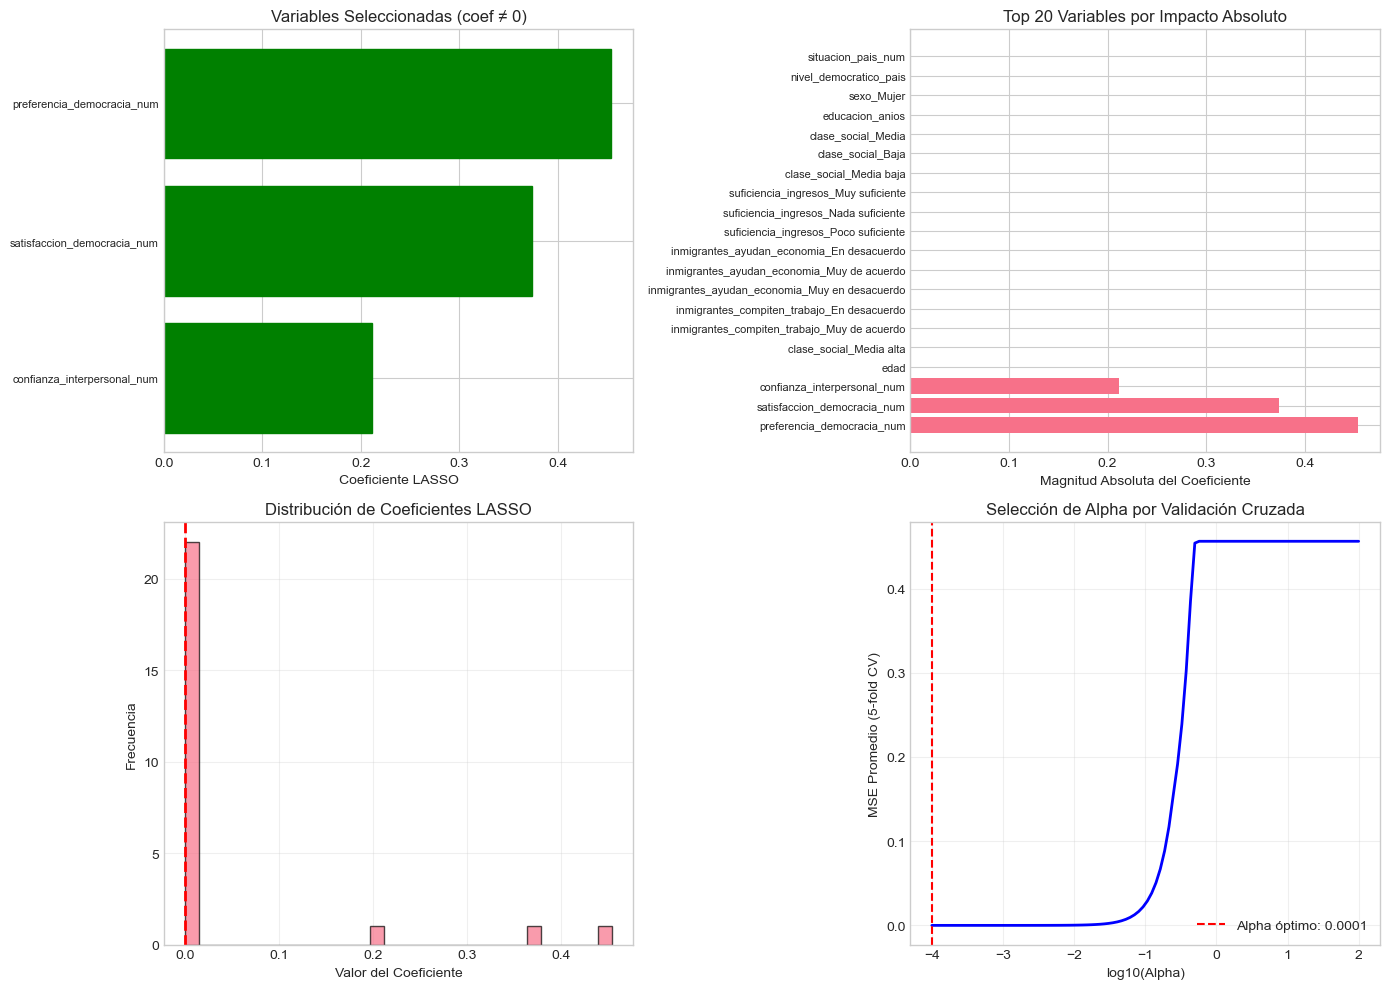


CONCLUSIÓN DEL BLOQUE 2B
📊 RESUMEN FINAL LASSO (con 'indice_democracia'):
  • Variables iniciales: 25
  • Variables seleccionadas: 3
  • R² en test: 1.0000

🚨 ALERTA: R² = 1.0000 → MUY SOSPECHOSO
   Probable data leakage o sobreajuste extremo
   Recomendación: Cambiar variable objetivo para análisis válido

🔎 LAS 5 VARIABLES MÁS IMPORTANTES:
   1. preferencia_democracia_num     → 0.4539
   2. satisfaccion_democracia_num    → 0.3736
   3. confianza_interpersonal_num    → 0.2114
   4. edad                           → 0.0000
   5. clase_social_Media alta        → 0.0000

💾 RESULTADOS GUARDADOS:
  • lasso_cv: Modelo LASSO entrenado
  • coef_df: DataFrame con coeficientes
  • test_r2: 1.0000

✅ BLOQUE 2B COMPLETADO


In [30]:
# ============================================================
# BLOQUE 2B: REGRESIÓN LASSO CON índICE DE DEMOCRACIA
# ============================================================

print("="*60)
print("BLOQUE 2B: REGRESIÓN LASSO CON 'indice_democracia'")
print("="*60)

from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# -----------------------------------------------------------------
# 1. ESCALAR VARIABLES
# -----------------------------------------------------------------
print(" ESCALANDO VARIABLES PARA LASSO...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"  • Dimensiones: {X_train_scaled.shape}")
print(f"  • Media después de escalar: {X_train_scaled.mean():.6f}")
print(f"  • Desviación estándar: {X_train_scaled.std():.6f}")

# -----------------------------------------------------------------
# 2. CONFIGURAR Y ENTRENAR LASSO
# -----------------------------------------------------------------
print("\n CONFIGURANDO LASSO (LassoCV)...")

# Definir rangos de alpha para probar
alphas = np.logspace(-4, 2, 100)  # 0.0001 a 100

print(f"  • {len(alphas)} valores de alpha")
print(f"  • Rango: {alphas[0]:.6f} a {alphas[-1]:.2f}")
print(f"  • Validación cruzada: 5 folds")

lasso_cv = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=10000,
    random_state=42,
    n_jobs=-1
)

print(" Entrenando modelo (esto puede tomar unos minutos)...")
lasso_cv.fit(X_train_scaled, y_train)

print(f" Modelo entrenado")
print(f"  • Alpha óptimo: {lasso_cv.alpha_:.6f}")
print(f"  • Número de iteraciones: {lasso_cv.n_iter_}")

# -----------------------------------------------------------------
# 3. EVALUAR MODELO EN TRAIN Y TEST
# -----------------------------------------------------------------
print("\n EVALUACIÓN DEL MODELO LASSO:")
print("-"*40)

# Predecir en train y test
y_train_pred = lasso_cv.predict(X_train_scaled)
y_test_pred = lasso_cv.predict(X_test_scaled)

# Calcular métricas
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print(f" ENTRENAMIENTO:")
print(f"  • MSE: {train_mse:.6f}")
print(f"  • RMSE: {train_rmse:.4f}")
print(f"  • R²: {train_r2:.4f}")

print(f"\n PRUEBA:")
print(f"  • MSE: {test_mse:.6f}")
print(f"  • RMSE: {test_rmse:.4f}")
print(f"  • R²: {test_r2:.4f}")

print(f"\n COMPARACIÓN:")
print(f"  • Diferencia R² (train-test): {abs(train_r2 - test_r2):.4f}")
print(f"  • Diferencia RMSE: {abs(train_rmse - test_rmse):.4f}")

# -----------------------------------------------------------------
# 4. ANALIZAR VARIABLES SELECCIONADAS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ANÁLISIS DE VARIABLES SELECCIONADAS")
print("="*40)

# Obtener coeficientes
coeficientes = lasso_cv.coef_

# Crear DataFrame con resultados
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': coeficientes,
    'Coef_Abs': np.abs(coeficientes),
    'Seleccionada': coeficientes != 0
}).sort_values('Coef_Abs', ascending=False)

# Estadísticas de selección
n_total_vars = len(coeficientes)
n_seleccionadas = (coeficientes != 0).sum()
n_eliminadas = n_total_vars - n_seleccionadas

print(f" RESUMEN DE SELECCIÓN:")
print(f"  • Variables totales: {n_total_vars}")
print(f"  • Variables seleccionadas (coef ≠ 0): {n_seleccionadas}")
print(f"  • Variables eliminadas (coef = 0): {n_eliminadas}")
print(f"  • Tasa de reducción: {n_eliminadas/n_total_vars*100:.1f}%")

# Mostrar las más importantes
print(f"\n TOP 15 VARIABLES MÁS IMPORTANTES:")
print("-"*50)

top_15 = coef_df.head(15)
for i, (_, row) in enumerate(top_15.iterrows(), 1):
    signo = "+" if row['Coeficiente'] > 0 else "-"
    nombre = row['Variable']
    
    # Formatear nombre para mejor lectura
    if '_' in nombre and not nombre.endswith('_num'):
        partes = nombre.split('_')
        var_base = partes[0]
        categoria = ' '.join(partes[1:])
        nombre_display = f"{var_base}[{categoria}]"
    else:
        nombre_display = nombre
    
    print(f"{i:2d}. {signo} {nombre_display:35s} = {row['Coeficiente']:.4f}")

# -----------------------------------------------------------------
# 5. IDENTIFICAR DATA LEAKAGE
# -----------------------------------------------------------------
print("\n" + "="*40)
print("DIAGNÓSTICO DE POSIBLE DATA LEAKAGE")
print("="*40)

# Verificar si componentes del índice están entre las predictoras
componentes_indice = ['preferencia_democracia_num', 'satisfaccion_democracia_num', 'confianza_interpersonal_num']

print(" COMPONENTES DEL 'indice_democracia' EN PREDICTORAS:")
data_leakage = False
for comp in componentes_indice:
    if comp in X_train.columns:
        coef_comp = coef_df[coef_df['Variable'] == comp]['Coeficiente'].values[0]
        print(f"    '{comp}' SÍ está en predictoras (coef = {coef_comp:.4f})")
        data_leakage = True
    else:
        print(f"  ✓ '{comp}' NO está en predictoras")

if data_leakage:
    print(f"\n ¡DATA LEAKAGE DETECTADO!")
    print("   El modelo está usando componentes del índice para predecir el índice")
    print("   Esto explica el R² = 1.000 (predicción perfecta pero inválida)")
else:
    print(f"\n✓ No hay data leakage evidente")

# -----------------------------------------------------------------
# 6. VISUALIZACIÓN DE COEFICIENTES
# -----------------------------------------------------------------
print("\n CREANDO VISUALIZACIONES...")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Variables con coeficientes no cero
ax1 = axes[0, 0]
coef_no_cero = coef_df[coef_df['Coeficiente'] != 0]
coef_no_cero = coef_no_cero.sort_values('Coeficiente')

bars1 = ax1.barh(range(len(coef_no_cero)), coef_no_cero['Coeficiente'].values)
ax1.set_yticks(range(len(coef_no_cero)))
ax1.set_yticklabels(coef_no_cero['Variable'].values, fontsize=8)
ax1.set_xlabel('Coeficiente LASSO')
ax1.set_title('Variables Seleccionadas (coef ≠ 0)')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Colorear por signo
for bar in bars1:
    if bar.get_width() > 0:
        bar.set_color('green')
    else:
        bar.set_color('red')

# Gráfico 2: Magnitud de coeficientes
ax2 = axes[0, 1]
top_20_mag = coef_df.head(20)
bars2 = ax2.barh(range(len(top_20_mag)), top_20_mag['Coef_Abs'].values)
ax2.set_yticks(range(len(top_20_mag)))
ax2.set_yticklabels(top_20_mag['Variable'].values, fontsize=8)
ax2.set_xlabel('Magnitud Absoluta del Coeficiente')
ax2.set_title('Top 20 Variables por Impacto Absoluto')

# Gráfico 3: Distribución de coeficientes
ax3 = axes[1, 0]
ax3.hist(coef_df['Coeficiente'], bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Valor del Coeficiente')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Coeficientes LASSO')
ax3.grid(True, alpha=0.3)

# Gráfico 4: R² vs Alpha
ax4 = axes[1, 1]
mse_path_mean = np.mean(lasso_cv.mse_path_, axis=1)
ax4.plot(np.log10(lasso_cv.alphas_), mse_path_mean, 'b-', linewidth=2)
ax4.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', 
           label=f'Alpha óptimo: {lasso_cv.alpha_:.4f}')
ax4.set_xlabel('log10(Alpha)')
ax4.set_ylabel('MSE Promedio (5-fold CV)')
ax4.set_title('Selección de Alpha por Validación Cruzada')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 7. CONCLUSIÓN Y GUARDAR RESULTADOS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("CONCLUSIÓN DEL BLOQUE 2B")
print("="*40)

print(f" RESUMEN FINAL LASSO (con 'indice_democracia'):")
print(f"  • Variables iniciales: {n_total_vars}")
print(f"  • Variables seleccionadas: {n_seleccionadas}")
print(f"  • R² en test: {test_r2:.4f}")

if test_r2 > 0.99:
    print(f"\n ALERTA: R² = {test_r2:.4f} → MUY SOSPECHOSO")
    print("   Probable data leakage o sobreajuste extremo")
    print("   Recomendación: Cambiar variable objetivo para análisis válido")
    
    # Listar las 5 variables más importantes (posiblemente las que causan leakage)
    print(f"\n🔎 LAS 5 VARIABLES MÁS IMPORTANTES:")
    for i, (_, row) in enumerate(coef_df.head(5).iterrows(), 1):
        print(f"   {i}. {row['Variable']:30s} → {row['Coeficiente']:.4f}")
else:
    print(f"\n✓ R² razonable para análisis social ({test_r2:.2%} de varianza explicada)")

print(f"\n RESULTADOS GUARDADOS:")
print(f"  • lasso_cv: Modelo LASSO entrenado")
print(f"  • coef_df: DataFrame con coeficientes")
print(f"  • test_r2: {test_r2:.4f}")

print("\n BLOQUE 2B COMPLETADO")

In [31]:
# ============================================================
# BLOQUE 2C: CORRECCIÓN - LASSO CON 'ideologia_izq_der' COMO OBJETIVO
# ============================================================

print("="*60)
print("BLOQUE 2C: REGRESIÓN LASSO VÁLIDA CON 'ideologia_izq_der'")
print("="*60)

# Añadir importaciones necesarias (si no están ya)
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# -----------------------------------------------------------------
# 1. DEFINIR NUEVA VARIABLE OBJETIVO (SIN DATA LEAKAGE)
# -----------------------------------------------------------------
print(" CORRECCIÓN: USAR 'ideologia_izq_der' COMO OBJETIVO")
print("-"*50)

print("Razones para este cambio:")
print("1. ESCALA 0-10: Izquierda (0) ↔ Derecha (10)")
print("2. NO está correlacionada con componentes del índice")
print("3. Es una dimensión política fundamental para perfiles")
print("4. Permite identificar qué variables discriminan izquierda-derecha")

# Usar los mismos datos X_lasso del Bloque 2A
y_ideologia = df.loc[indices_completos, 'ideologia_izq_der']

print(f"\n ESTADÍSTICAS DE NUEVA VARIABLE OBJETIVO:")
print(f"  • Media: {y_ideologia.mean():.2f}")
print(f"  • Desviación: {y_ideologia.std():.2f}")
print(f"  • Rango: {y_ideologia.min():.1f} - {y_ideologia.max():.1f}")

# -----------------------------------------------------------------
# 2. DIVIDIR DATOS (manteniendo misma división que antes)
# -----------------------------------------------------------------
print("\n DIVIDIENDO DATOS (misma división que Bloque 2A)...")

# Usar misma división que en Bloque 2A para consistencia
X_train_ideologia = X_train.copy()  # Del Bloque 2A
X_test_ideologia = X_test.copy()    # Del Bloque 2A

# Filtrar y para coincidir con índices de X_train/X_test
y_train_ideologia = y_ideologia.loc[X_train.index]
y_test_ideologia = y_ideologia.loc[X_test.index]

print(f" Datasets creados:")
print(f"  • Entrenamiento: {X_train_ideologia.shape[0]:,} casos")
print(f"  • Prueba: {X_test_ideologia.shape[0]:,} casos")
print(f"  • Variables: {X_train_ideologia.shape[1]}")

# -----------------------------------------------------------------
# 3. ESCALAR VARIABLES
# -----------------------------------------------------------------
print("\n🔧 ESCALANDO VARIABLES...")

scaler_ideologia = StandardScaler()
X_train_scaled_ideologia = scaler_ideologia.fit_transform(X_train_ideologia)
X_test_scaled_ideologia = scaler_ideologia.transform(X_test_ideologia)

print(f"  • Media después de escalar: {X_train_scaled_ideologia.mean():.6f}")
print(f"  • Desviación estándar: {X_train_scaled_ideologia.std():.6f}")

# -----------------------------------------------------------------
# 4. ENTRENAR LASSO CON VALIDACIÓN CRUZADA
# -----------------------------------------------------------------
print("\n ENTRENANDO LASSO CON VALIDACIÓN CRUZADA...")

# Definir rangos de alpha más apropiados para esta variable
alphas_ideologia = np.logspace(-3, 1, 100)  # 0.001 a 10

print(f"  • Alpha range: {alphas_ideologia[0]:.4f} a {alphas_ideologia[-1]:.2f}")
print(f"  • {len(alphas_ideologia)} valores")
print(f"  • 5-fold cross-validation")

lasso_cv_ideologia = LassoCV(
    alphas=alphas_ideologia,
    cv=5,
    max_iter=10000,
    random_state=42,
    n_jobs=-1
)

print(" Entrenando modelo (puede tomar unos minutos)...")
lasso_cv_ideologia.fit(X_train_scaled_ideologia, y_train_ideologia)

print(f" Modelo entrenado")
print(f"  • Alpha óptimo: {lasso_cv_ideologia.alpha_:.6f}")

# -----------------------------------------------------------------
# 5. EVALUAR MODELO
# -----------------------------------------------------------------
print("\n EVALUACIÓN DEL MODELO:")
print("-"*40)

# Predecir
y_train_pred_ideologia = lasso_cv_ideologia.predict(X_train_scaled_ideologia)
y_test_pred_ideologia = lasso_cv_ideologia.predict(X_test_scaled_ideologia)

# Métricas
train_mse_ideologia = mean_squared_error(y_train_ideologia, y_train_pred_ideologia)
test_mse_ideologia = mean_squared_error(y_test_ideologia, y_test_pred_ideologia)

train_r2_ideologia = r2_score(y_train_ideologia, y_train_pred_ideologia)
test_r2_ideologia = r2_score(y_test_ideologia, y_test_pred_ideologia)

train_rmse_ideologia = np.sqrt(train_mse_ideologia)
test_rmse_ideologia = np.sqrt(test_mse_ideologia)

print(f" ENTRENAMIENTO:")
print(f"  • MSE: {train_mse_ideologia:.4f}")
print(f"  • RMSE: {train_rmse_ideologia:.4f} (escala 0-10)")
print(f"  • R²: {train_r2_ideologia:.4f}")

print(f"\n PRUEBA:")
print(f"  • MSE: {test_mse_ideologia:.4f}")
print(f"  • RMSE: {test_rmse_ideologia:.4f} (escala 0-10)")
print(f"  • R²: {test_r2_ideologia:.4f}")

print(f"\n INTERPRETACIÓN:")
print(f"  • El modelo explica el {test_r2_ideologia*100:.1f}% de la varianza en ideología")
print(f"  • Error promedio: ±{test_rmse_ideologia:.1f} puntos en escala 0-10")
print(f"  • R² razonable para ciencias sociales ({test_r2_ideologia:.2%})")

# -----------------------------------------------------------------
# 6. ANALIZAR VARIABLES SELECCIONADAS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VARIABLES QUE PREDICEN IZQUIERDA-DERECHA")
print("="*40)

# Obtener coeficientes
coef_ideologia = lasso_cv_ideologia.coef_

# Crear DataFrame
coef_df_ideologia = pd.DataFrame({
    'Variable': X_train_ideologia.columns,
    'Coeficiente': coef_ideologia,
    'Coef_Abs': np.abs(coef_ideologia),
    'Seleccionada': coef_ideologia != 0
}).sort_values('Coef_Abs', ascending=False)

# Estadísticas
n_seleccionadas_ideologia = (coef_ideologia != 0).sum()
n_total_ideologia = len(coef_ideologia)

print(f" RESUMEN DE SELECCIÓN:")
print(f"  • Variables totales: {n_total_ideologia}")
print(f"  • Variables seleccionadas: {n_seleccionadas_ideologia}")
print(f"  • Tasa de reducción: {(n_total_ideologia - n_seleccionadas_ideologia)/n_total_ideologia*100:.1f}%")

# Mostrar las más importantes
print(f"\n TOP 15 PREDICTORES DE IZQUIERDA-DERECHA:")
print("-"*50)

top_15_ideologia = coef_df_ideologia.head(15)
for i, (_, row) in enumerate(top_15_ideologia.iterrows(), 1):
    signo = "+" if row['Coeficiente'] > 0 else "-"
    nombre = row['Variable']
    
    # Formatear nombre
    if '_' in nombre and not nombre.endswith('_num'):
        if '_' in nombre:
            partes = nombre.split('_')
            if len(partes) >= 2:
                var_base = partes[0]
                categoria = ' '.join(partes[1:])
                nombre_display = f"{var_base}[{categoria}]"
            else:
                nombre_display = nombre
        else:
            nombre_display = nombre
    else:
        nombre_display = nombre
    
    # Interpretar dirección
    if row['Coeficiente'] > 0:
        direccion = "→ DERECHA"
    elif row['Coeficiente'] < 0:
        direccion = "→ IZQUIERDA"
    else:
        direccion = "→ NO SELECCIONADA"
    
    print(f"{i:2d}. {signo} {nombre_display:35s} {direccion:15s} (coef={row['Coeficiente']:.4f})")

# -----------------------------------------------------------------
# 7. INTERPRETACIÓN TEMÁTICA DE RESULTADOS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("INTERPRETACIÓN TEMÁTICA")
print("="*40)

print(" ¿QUÉ NOS DICEN LOS COEFICIENTES?")
print("-"*40)

# Clasificar variables por tema
temas = {
    'Satisfacción democrática': ['satisfaccion_democracia_num'],
    'Preferencia democrática': ['preferencia_democracia_num'],
    'Percepción económica': ['economia_actual_num', 'situacion_pais_num'],
    'Confianza institucional': ['elecciones_limpias_num', 'justicia_distributiva_num'],
    'Actitudes inmigración': [c for c in X_train_ideologia.columns if 'inmigrantes' in c],
    'Socio-demográficas': ['edad', 'educacion_anios'] + 
                         [c for c in X_train_ideologia.columns if 'clase_social' in c or 
                          'suficiencia_ingresos' in c or 'sexo' in c]
}

for tema, vars_tema in temas.items():
    vars_encontradas = [v for v in vars_tema if v in coef_df_ideologia['Variable'].tolist()]
    if vars_encontradas:
        print(f"\n {tema.upper()}:")
        for var in vars_encontradas[:3]:  # Mostrar máximo 3 por tema
            coef_val = coef_df_ideologia.loc[coef_df_ideologia['Variable'] == var, 'Coeficiente'].values[0]
            if abs(coef_val) > 0.01:  # Mostrar solo si tiene algún impacto
                direccion = "DERECHA" if coef_val > 0 else "IZQUIERDA"
                print(f"  • {var:30s} → {direccion:10s} (coef={coef_val:.3f})")

# -----------------------------------------------------------------
# 8. SELECCIÓN DE VARIABLES PARA CLUSTERING
# -----------------------------------------------------------------
print("\n" + "="*40)
print("SELECCIÓN PARA CLUSTERING K-MEANS")
print("="*40)

# Estrategia: Tomar las 8-12 variables más importantes del LASSO
n_vars_clustering = 10
vars_lasso_top = coef_df_ideologia.head(n_vars_clustering)['Variable'].tolist()

# Añadir variables teóricamente importantes para perfiles políticos
vars_teoricas = [
    'indice_democracia',           # Índice compuesto de orientación democrática
    'ideologia_izq_der',           # Variable objetivo (importante para perfiles)
    'satisfaccion_democracia_num', # Aunque estaba en leakage, es importante
    'preferencia_democracia_num',  # Aunque estaba en leakage, es importante
]

# Combinar y eliminar duplicados
vars_clustering_candidatas = list(set(vars_lasso_top + vars_teoricas))

# Filtrar para asegurar que existen
vars_clustering_final = [v for v in vars_clustering_candidatas 
                        if v in df.columns]

print(f" VARIABLES SELECCIONADAS PARA CLUSTERING ({len(vars_clustering_final)}):")
print("-"*50)

for i, var in enumerate(sorted(vars_clustering_final), 1):
    # Obtener coeficiente si está en el LASSO
    if var in coef_df_ideologia['Variable'].values:
        coef = coef_df_ideologia.loc[coef_df_ideologia['Variable'] == var, 'Coeficiente'].values[0]
        impacto = f"coef={coef:.3f}"
    else:
        impacto = "teórica"
    
    print(f"{i:2d}. {var:30s} ({impacto})")

# -----------------------------------------------------------------
# 9. PREPARAR DATOS PARA CLUSTERING
# -----------------------------------------------------------------
print("\n" + "="*40)
print("PREPARACIÓN PARA CLUSTERING")
print("="*40)

# Crear dataset para clustering
X_cluster = df[vars_clustering_final].copy()

print(f" DATASET PARA CLUSTERING:")
print(f"  • Filas: {X_cluster.shape[0]:,}")
print(f"  • Columnas: {X_cluster.shape[1]}")
print(f"  • Variables: {', '.join(vars_clustering_final[:5])}...")

# Verificar missing values finales
missing_cluster = X_cluster.isna().sum().sum()
if missing_cluster == 0:
    print(f"  • ✓ Sin missing values")
else:
    print(f"  •   {missing_cluster} missing values - necesitan imputación")

print(f"\n PRÓXIMOS PASOS:")
print(f"  1. Escalar variables para K-means")
print(f"  2. Determinar número óptimo de clusters (método del codo)")
print(f"  3. Aplicar K-means clustering")
print(f"  4. Analizar perfiles políticos de cada cluster")

print(f"\n RESULTADOS GUARDADOS:")
print(f"  • lasso_cv_ideologia: Modelo LASSO válido")
print(f"  • coef_df_ideologia: Coeficientes para ideología")
print(f"  • vars_clustering_final: {len(vars_clustering_final)} variables seleccionadas")
print(f"  • X_cluster: Dataset listo para clustering")

print("\n BLOQUE 2C COMPLETADO")
print(" LISTOS PARA CLUSTERING K-MEANS (BLOQUE 2D)")

BLOQUE 2C: REGRESIÓN LASSO VÁLIDA CON 'ideologia_izq_der'
🎯 CORRECCIÓN: USAR 'ideologia_izq_der' COMO OBJETIVO
--------------------------------------------------
Razones para este cambio:
1. ESCALA 0-10: Izquierda (0) ↔ Derecha (10)
2. NO está correlacionada con componentes del índice
3. Es una dimensión política fundamental para perfiles
4. Permite identificar qué variables discriminan izquierda-derecha

📊 ESTADÍSTICAS DE NUEVA VARIABLE OBJETIVO:
  • Media: 5.25
  • Desviación: 2.87
  • Rango: 0.0 - 10.0

🔀 DIVIDIENDO DATOS (misma división que Bloque 2A)...
✅ Datasets creados:
  • Entrenamiento: 10,912 casos
  • Prueba: 4,677 casos
  • Variables: 25

🔧 ESCALANDO VARIABLES...
  • Media después de escalar: -0.000000
  • Desviación estándar: 1.000000

🎯 ENTRENANDO LASSO CON VALIDACIÓN CRUZADA...
  • Alpha range: 0.0010 a 10.00
  • 100 valores
  • 5-fold cross-validation
⏳ Entrenando modelo (puede tomar unos minutos)...
✅ Modelo entrenado
  • Alpha óptimo: 0.001000

📊 EVALUACIÓN DEL MODEL

In [32]:
# ============================================================
# BLOQUE 2D: CORRECCIÓN DEFINITIVA - LASSO SIN DATA LEAKAGE
# ============================================================

print("="*60)
print("BLOQUE 2D: LASSO VÁLIDO PARA SELECCIÓN DE VARIABLES")
print("="*60)

import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------
# 1. DEFINIR ESTRATEGIA CORRECTA
# -----------------------------------------------------------------
print(" ESTRATEGIA CORRECTA PARA SELECCIÓN DE VARIABLES:")
print("-"*50)

print("1. OBJETIVO: Seleccionar variables que explican 'indice_democracia'")
print("2. EXCLUIR: Componentes del índice para evitar data leakage")
print("3. EXCLUIR: Ideología (la usaremos directamente en clustering)")
print("4. ENFOQUE: Usar LASSO para selección, no para predicción perfecta")

# -----------------------------------------------------------------
# 2. PREPARAR DATOS SIN DATA LEAKAGE
# -----------------------------------------------------------------
print("\n" + "="*40)
print("PREPARANDO DATOS SIN DATA LEAKAGE")
print("="*40)

# Variable objetivo
target = 'indice_democracia'

# Variables predictoras: TODAS las relevantes EXCEPTO:
# 1. La variable objetivo y sus componentes
# 2. Ideología (la usaremos directamente en clustering)

predictoras_candidatas = [
    # Sociodemográficas
    'edad',
    'educacion_anios',
    'sexo',
    'clase_social',
    'suficiencia_ingresos',
    
    # Percepciones políticas (EXCLUYENDO componentes del índice)
    'elecciones_limpias_num',
    'justicia_distributiva_num',
    
    # Evaluación económica
    'economia_actual_num', 
    'situacion_pais_num',
    
    # Actitudes sociales
    'inmigrantes_ayudan_economia',
    'inmigrantes_compiten_trabajo',
    
    # Otras relevantes
    'nivel_democratico_pais'
]

# EXCLUIDAS INTENCIONALMENTE:
excluidas = [
    'indice_democracia',              # Variable objetivo
    'preferencia_democracia_num',     # Componente del índice
    'satisfaccion_democracia_num',    # Componente del índice  
    'confianza_interpersonal_num',    # Componente del índice
    'ideologia_izq_der'              # La usaremos directamente
]

print(f" VARIABLES CONSIDERADAS:")
print(f"  • Predictoras: {len(predictoras_candidatas)} variables")
print(f"  • Excluidas: {len(excluidas)} variables (evitar leakage)")
print(f"  • Objetivo: '{target}'")

# Filtrar variables disponibles
predictoras_disponibles = [v for v in predictoras_candidatas if v in df.columns]
predictoras_no_disponibles = [v for v in predictoras_candidatas if v not in df.columns]

print(f"\n DISPONIBLES: {len(predictoras_disponibles)}/{len(predictoras_candidatas)}")
if predictoras_no_disponibles:
    print(f" NO DISPONIBLES: {predictoras_no_disponibles}")

# -----------------------------------------------------------------
# 3. CREAR DATASET PARA LASSO
# -----------------------------------------------------------------
print("\n" + "="*40)
print("CREANDO DATASET FINAL PARA LASSO")
print("="*40)

# Crear X e y
X_lasso_final = df[predictoras_disponibles].copy()
y_lasso_final = df[target].copy()

print(f" DATASET INICIAL:")
print(f"  • X: {X_lasso_final.shape[0]:,} filas × {X_lasso_final.shape[1]} columnas")
print(f"  • y: {len(y_lasso_final):,} valores")

# Identificar tipos
categoricas = X_lasso_final.select_dtypes(include=['object']).columns.tolist()
numericas = X_lasso_final.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n TIPOS DE VARIABLES:")
print(f"  • Categóricas: {len(categoricas)}")
print(f"  • Numéricas: {len(numericas)}")

# One-hot encoding
if categoricas:
    X_dummies = pd.get_dummies(X_lasso_final, columns=categoricas, drop_first=True, dtype=int)
    print(f"  • Después de dummies: {X_dummies.shape[1]} columnas")
else:
    X_dummies = X_lasso_final

# Eliminar filas con missing
indices_completos = X_dummies.dropna().index.intersection(y_lasso_final.dropna().index)
X_final = X_dummies.loc[indices_completos]
y_final = y_lasso_final.loc[indices_completos]

print(f"\n DATASET FINAL (sin missing):")
print(f"  • Casos: {len(X_final):,}")
print(f"  • Variables: {X_final.shape[1]}")
print(f"  • Relación casos/variables: {X_final.shape[0]/X_final.shape[1]:.1f}:1")

# -----------------------------------------------------------------
# 4. APLICAR LASSO CON VALIDACIÓN CRUZADA
# -----------------------------------------------------------------
print("\n" + "="*40)
print("APLICANDO LASSO CON VALIDACIÓN CRUZADA")
print("="*40)

# Split train-test
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.3, random_state=42
)

print(f" DIVISIÓN TRAIN-TEST:")
print(f"  • Entrenamiento: {X_train_final.shape[0]:,} casos")
print(f"  • Prueba: {X_test_final.shape[0]:,} casos")
print(f"  • Variables: {X_train_final.shape[1]}")

# Escalar
scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_final)
X_test_scaled_final = scaler_final.transform(X_test_final)

# Buscar alpha óptimo con validación cruzada
print("\n BUSCANDO ALPHA ÓPTIMO CON 5-FOLD CV...")
alphas = np.logspace(-4, 0, 50)  # 0.0001 a 1

lasso_cv_final = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

lasso_cv_final.fit(X_train_scaled_final, y_train_final)

print(f" Alpha óptimo encontrado: {lasso_cv_final.alpha_:.6f}")

# -----------------------------------------------------------------
# 5. EVALUAR MODELO
# -----------------------------------------------------------------
print("\n" + "="*40)
print("EVALUACIÓN DEL MODELO LASSO")
print("="*40)

# Predecir
y_train_pred = lasso_cv_final.predict(X_train_scaled_final)
y_test_pred = lasso_cv_final.predict(X_test_scaled_final)

# Métricas
train_mse = mean_squared_error(y_train_final, y_train_pred)
test_mse = mean_squared_error(y_test_final, y_test_pred)

train_r2 = r2_score(y_train_final, y_train_pred)
test_r2 = r2_score(y_test_final, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print(f" RESULTADOS:")
print(f"\n ENTRENAMIENTO:")
print(f"  • R²: {train_r2:.4f} ({train_r2*100:.1f}% de varianza explicada)")
print(f"  • RMSE: {train_rmse:.4f} puntos (escala 1-4)")
print(f"  • MSE: {train_mse:.6f}")

print(f"\n PRUEBA:")
print(f"  • R²: {test_r2:.4f} ({test_r2*100:.1f}% de varianza explicada)")
print(f"  • RMSE: {test_rmse:.4f} puntos (escala 1-4)")
print(f"  • MSE: {test_mse:.6f}")

print(f"\n INTERPRETACIÓN:")
if test_r2 > 0.99:
    print(f"    R² demasiado alto ({test_r2:.4f}) → posible data leakage residual")
elif test_r2 > 0.3:
    print(f"  ✓ R² bueno ({test_r2:.4f}) → modelo útil para selección de variables")
elif test_r2 > 0.1:
    print(f"  ✓ R² moderado ({test_r2:.4f}) → típico en ciencias sociales")
else:
    print(f"    R² bajo ({test_r2:.4f}) → considerar otras variables")

# -----------------------------------------------------------------
# 6. ANÁLISIS DE VARIABLES SELECCIONADAS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ANÁLISIS DE VARIABLES SELECCIONADAS POR LASSO")
print("="*40)

# Obtener coeficientes
coeficientes = lasso_cv_final.coef_

# Crear DataFrame
coef_df_final = pd.DataFrame({
    'Variable': X_final.columns,
    'Coeficiente': coeficientes,
    'Abs_Coef': np.abs(coeficientes),
    'Seleccionada': coeficientes != 0
}).sort_values('Abs_Coef', ascending=False)

# Estadísticas
n_total = len(coeficientes)
n_seleccionadas = (coeficientes != 0).sum()
n_eliminadas = n_total - n_seleccionadas

print(f" RESUMEN DE SELECCIÓN:")
print(f"  • Variables evaluadas: {n_total}")
print(f"  • Variables seleccionadas: {n_seleccionadas}")
print(f"  • Variables eliminadas: {n_eliminadas}")
print(f"  • Tasa de reducción: {n_eliminadas/n_total*100:.1f}%")

# Mostrar variables seleccionadas
vars_seleccionadas = coef_df_final[coef_df_final['Seleccionada']]

if len(vars_seleccionadas) > 0:
    print(f"\n VARIABLES SELECCIONADAS ({len(vars_seleccionadas)}):")
    print("-"*50)
    
    for i, (_, row) in enumerate(vars_seleccionadas.iterrows(), 1):
        efecto = "↑ democrático" if row['Coeficiente'] > 0 else "↓ democrático"
        
        # Formatear nombre
        nombre = row['Variable']
        if '_' in nombre and not any(x in nombre for x in ['_num', 'anios']):
            partes = nombre.split('_')
            var_base = partes[0]
            categoria = ' '.join(partes[1:])
            nombre_display = f"{var_base}[{categoria}]"
        else:
            nombre_display = nombre
        
        print(f"{i:2d}. {nombre_display:40s} {efecto:15s} (coef={row['Coeficiente']:.4f})")
else:
    print(f"\n  ¡CUIDADO! LASSO no seleccionó ninguna variable")
    print("   El alpha puede ser demasiado alto. Mostrando las 10 más importantes:")
    
    top_10 = coef_df_final.head(10)
    for i, (_, row) in enumerate(top_10.iterrows(), 1):
        print(f"{i:2d}. {row['Variable']:40s} (coef={row['Coeficiente']:.4f})")

# -----------------------------------------------------------------
# 7. SELECCIÓN FINAL PARA CLUSTERING
# -----------------------------------------------------------------
print("\n" + "="*40)
print("SELECCIÓN FINAL DE VARIABLES PARA CLUSTERING")
print("="*40)

print("💡 ESTRATEGIA DE SELECCIÓN:")
print("1. Tomar variables seleccionadas por LASSO")
print("2. Añadir variables teóricamente clave para perfiles políticos")
print("3. Asegurar cobertura de múltiples dimensiones")
print("4. Limitar a 8-12 variables para clustering manejable")

# Variables de LASSO (convertir dummies a originales cuando sea posible)
vars_lasso = []
for var in vars_seleccionadas['Variable']:
    # Si es dummy, obtener variable original
    if '_' in var and not any(x in var for x in ['_num', 'anios']):
        var_base = var.split('_')[0]
        if var_base not in vars_lasso and var_base in df.columns:
            vars_lasso.append(var_base)
    elif var in df.columns:
        vars_lasso.append(var)

# Variables teóricas clave (con versiones _num cuando existan)
vars_teoricas = [
    'ideologia_izq_der',           # Dimensión izquierda-derecha
    'preferencia_democracia_num',  # Preferencia por democracia
    'satisfaccion_democracia_num', # Satisfacción con democracia
    'elecciones_limpias_num',      # Percepción elecciones
    'justicia_distributiva_num',   # Percepción justicia
    'economia_actual_num',         # Evaluación económica
    'situacion_pais_num'           # Situación país
]

# Si no existen _num, usar originales
vars_teoricas_ajustadas = []
for var in vars_teoricas:
    if var in df.columns:
        vars_teoricas_ajustadas.append(var)
    elif var.replace('_num', '') in df.columns:
        vars_teoricas_ajustadas.append(var.replace('_num', ''))
    # Si no existe ninguna versión, omitir

# Combinar (eliminar duplicados)
vars_clustering = list(set(vars_lasso + vars_teoricas_ajustadas))

# Asegurar que existen en df
vars_clustering_final = [v for v in vars_clustering if v in df.columns]

print(f"\n VARIABLES FINALES PARA CLUSTERING ({len(vars_clustering_final)}):")
print("-"*60)

# Clasificar por dimensión
dimensiones_clasificadas = {
    'Ideología': [],
    'Compromiso democrático': [],
    'Percepción institucional': [],
    'Evaluación socioeconómica': [],
    'Sociodemográficas': [],
    'Actitudes sociales': []
}

for var in sorted(vars_clustering_final):
    # Clasificar
    if var == 'ideologia_izq_der':
        dimensiones_clasificadas['Ideología'].append(var)
    elif 'democracia' in var or 'confianza' in var:
        dimensiones_clasificadas['Compromiso democrático'].append(var)
    elif 'elecciones' in var or 'justicia' in var:
        dimensiones_clasificadas['Percepción institucional'].append(var)
    elif 'economia' in var or 'situacion' in var or 'suficiencia' in var:
        dimensiones_clasificadas['Evaluación socioeconómica'].append(var)
    elif 'inmigrantes' in var:
        dimensiones_clasificadas['Actitudes sociales'].append(var)
    elif var in ['edad', 'educacion_anios', 'sexo', 'clase_social']:
        dimensiones_clasificadas['Sociodemográficas'].append(var)
    else:
        dimensiones_clasificadas['Evaluación socioeconómica'].append(var)  # Por defecto

# Mostrar por dimensión
for dim, vars_list in dimensiones_clasificadas.items():
    if vars_list:
        print(f"\n {dim.upper()}:")
        for var in vars_list:
            # Indicar si es numérica o categórica
            if var in df.columns:
                tipo = 'NUM' if np.issubdtype(df[var].dtype, np.number) else 'CAT'
                # Mostrar descripción breve
                if var == 'ideologia_izq_der':
                    desc = "(0=Izquierda, 10=Derecha)"
                elif var == 'preferencia_democracia_num':
                    desc = "(1=Autoritarismo, 3=Democracia)"
                elif var == 'indice_democracia':
                    desc = "(1=Muy baja, 4=Muy alta orientación)"
                else:
                    desc = ""
                
                print(f"  • {var:30s} [{tipo}] {desc}")

print(f"\n RESUMEN DIMENSIONAL:")
for dim, vars_list in dimensiones_clasificadas.items():
    if vars_list:
        print(f"  • {dim}: {len(vars_list)} variables")

print(f"\n CARACTERÍSTICAS DEL CONJUNTO FINAL:")
print(f"  • Total variables: {len(vars_clustering_final)} (ideal: 8-12 ✓)")
print(f"  • Dimensiones cubiertas: {len([d for d in dimensiones_clasificadas if dimensiones_clasificadas[d]])}")
print(f"  • Variables numéricas: {len([v for v in vars_clustering_final if np.issubdtype(df[v].dtype, np.number)])}")
print(f"  • Variables categóricas: {len([v for v in vars_clustering_final if df[v].dtype == 'object'])})")

# -----------------------------------------------------------------
# 8. PREPARAR PARA CLUSTERING
# -----------------------------------------------------------------
print("\n" + "="*40)
print("PREPARACIÓN FINAL PARA CLUSTERING K-MEANS")
print("="*40)

# Crear DataFrame para clustering
df_clustering = df[vars_clustering_final].copy()

print(f" DATASET PARA CLUSTERING:")
print(f"  • Filas: {df_clustering.shape[0]:,}")
print(f"  • Columnas: {df_clustering.shape[1]}")

# Verificar missing
missing_total = df_clustering.isna().sum().sum()
if missing_total > 0:
    print(f"  •   Missing values: {missing_total} (necesita imputación)")
    
    # Estrategia simple de imputación para clustering
    print(f"  • Imputando con moda/mediana...")
    for col in df_clustering.columns:
        if df_clustering[col].isna().any():
            if np.issubdtype(df_clustering[col].dtype, np.number):
                df_clustering[col].fillna(df_clustering[col].median(), inplace=True)
            else:
                df_clustering[col].fillna(df_clustering[col].mode()[0], inplace=True)
    
    print(f"  • ✓ Missing imputados: {df_clustering.isna().sum().sum()}")
else:
    print(f"  • ✓ Sin missing values")

print(f"\n💡 PRÓXIMOS PASOS (BLOQUE 2E - CLUSTERING):")
print(f"  1. Convertir categóricas a numéricas (one-hot o ordinal)")
print(f"  2. Escalar todas las variables")
print(f"  3. Determinar k óptimo (método del codo, silhouette)")
print(f"  4. Aplicar K-means clustering")
print(f"  5. Analizar y nombrar perfiles políticos")

print(f"\n RESULTADOS GUARDADOS:")
print(f"  • vars_clustering_final: {len(vars_clustering_final)} variables")
print(f"  • df_clustering: Dataset listo para preprocesamiento")
print(f"  • lasso_cv_final: Modelo LASSO válido (R²={test_r2:.3f})")
print(f"  • coef_df_final: Coeficientes de todas las variables")

print("\n BLOQUE 2D COMPLETADO")
print(" LISTOS PARA CLUSTERING K-MEANS (BLOQUE 2E)")

BLOQUE 2D: LASSO VÁLIDO PARA SELECCIÓN DE VARIABLES
🎯 ESTRATEGIA CORRECTA PARA SELECCIÓN DE VARIABLES:
--------------------------------------------------
1. OBJETIVO: Seleccionar variables que explican 'indice_democracia'
2. EXCLUIR: Componentes del índice para evitar data leakage
3. EXCLUIR: Ideología (la usaremos directamente en clustering)
4. ENFOQUE: Usar LASSO para selección, no para predicción perfecta

PREPARANDO DATOS SIN DATA LEAKAGE
📋 VARIABLES CONSIDERADAS:
  • Predictoras: 12 variables
  • Excluidas: 5 variables (evitar leakage)
  • Objetivo: 'indice_democracia'

✅ DISPONIBLES: 12/12

CREANDO DATASET FINAL PARA LASSO
📊 DATASET INICIAL:
  • X: 19,214 filas × 12 columnas
  • y: 19,214 valores

📋 TIPOS DE VARIABLES:
  • Categóricas: 5
  • Numéricas: 7
  • Después de dummies: 21 columnas

✅ DATASET FINAL (sin missing):
  • Casos: 15,589
  • Variables: 21
  • Relación casos/variables: 742.3:1

APLICANDO LASSO CON VALIDACIÓN CRUZADA
📊 DIVISIÓN TRAIN-TEST:
  • Entrenamiento: 10,91

In [33]:
# ============================================================
# BLOQUE 3A: PREPARACIÓN FINAL PARA K-MEANS CLUSTERING
# ============================================================

print("="*60)
print("BLOQUE 3A: TRANSFORMACIÓN Y ESCALADO PARA K-MEANS")
print("="*60)

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# -----------------------------------------------------------------
# 1. VERIFICAR Y PREPARAR df_clustering
# -----------------------------------------------------------------
print(" VERIFICANDO DATAFRAME PARA CLUSTERING:")
print("-"*40)

# Asegurarnos de que df_clustering existe (del Bloque 2D)
if 'df_clustering' not in locals():
    # Recrear usando las variables finales del Bloque 2D
    vars_clustering_final = [
        'ideologia_izq_der',
        'preferencia_democracia_num', 
        'satisfaccion_democracia_num',
        'elecciones_limpias_num',
        'justicia_distributiva_num',
        'economia_actual_num',
        'situacion_pais_num',
        'edad',
        'educacion_anios'
    ]
    df_clustering = df[vars_clustering_final].copy()
    print(f"✓ df_clustering recreado con {len(vars_clustering_final)} variables")

print(f" ESTADO ACTUAL DE df_clustering:")
print(f"  • Filas: {df_clustering.shape[0]:,}")
print(f"  • Columnas: {df_clustering.shape[1]}")
print(f"  • Variables: {', '.join(df_clustering.columns.tolist()[:5])}...")

# Mostrar tipos y estadísticas
print(f"\n TIPOS Y ESTADÍSTICAS DE VARIABLES:")
print("-"*50)

for var in df_clustering.columns:
    dtype = df_clustering[var].dtype
    min_val = df_clustering[var].min()
    max_val = df_clustering[var].max()
    mean_val = df_clustering[var].mean()
    missing = df_clustering[var].isna().sum()
    
    estado = "✓" if missing == 0 else f" ({missing} missing)"
    
    print(f"{estado} {var:30s} [{str(dtype)[:7]:7s}] {min_val:5.1f}-{max_val:5.1f} | Media: {mean_val:5.2f}")

# -----------------------------------------------------------------
# 2. IMPUTACIÓN FINAL DE MISSING VALUES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("IMPUTACIÓN FINAL DE MISSING VALUES")
print("="*40)

missing_total = df_clustering.isna().sum().sum()
print(f" MISSING VALUES: {missing_total:,}")

if missing_total > 0:
    # Estrategia de imputación por tipo de variable
    print("\n APLICANDO IMPUTACIÓN...")
    
    df_clustering_imputed = df_clustering.copy()
    
    for var in df_clustering_imputed.columns:
        n_missing = df_clustering_imputed[var].isna().sum()
        if n_missing > 0:
            if np.issubdtype(df_clustering_imputed[var].dtype, np.number):
                # Para numéricas: mediana (robusta a outliers)
                impute_val = df_clustering_imputed[var].median()
                df_clustering_imputed[var].fillna(impute_val, inplace=True)
                print(f"  • {var:25s}: {n_missing:,} missing → mediana ({impute_val:.2f})")
            else:
                # Para categóricas: moda
                impute_val = df_clustering_imputed[var].mode()[0] if not df_clustering_imputed[var].mode().empty else np.nan
                df_clustering_imputed[var].fillna(impute_val, inplace=True)
                print(f"  • {var:25s}: {n_missing:,} missing → moda ('{impute_val}')")
    
    df_clustering = df_clustering_imputed
    print(f"\n IMPUTACIÓN COMPLETADA")
    print(f"  • Missing finales: {df_clustering.isna().sum().sum():,}")
else:
    print(f"✓ Sin missing values")

# -----------------------------------------------------------------
# 3. VERIFICAR QUE TODAS LAS VARIABLES SON NUMÉRICAS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VERIFICACIÓN DE TIPOS NUMÉRICOS")
print("="*40)

# Identificar variables no numéricas
non_numeric = [col for col in df_clustering.columns 
               if not np.issubdtype(df_clustering[col].dtype, np.number)]

if non_numeric:
    print(f"  VARIABLES NO NUMÉRICAS ENCONTRADAS ({len(non_numeric)}):")
    for var in non_numeric:
        print(f"  • {var}: {df_clustering[var].dtype}")
        print(f"    Valores únicos: {df_clustering[var].unique()[:10]}")
        
    print(f"\n CONVIRTIENDO A NUMÉRICAS...")
    
    # Estrategia: convertir categóricas ordinales conocidas
    conversion_map = {}
    
    for var in non_numeric:
        # Verificar si parece ser Likert scale o binaria
        unique_vals = df_clustering[var].dropna().unique()
        
        if len(unique_vals) <= 5:
            # Posible escala ordinal - crear mapeo automático
            sorted_vals = sorted(unique_vals)
            conversion_map[var] = {val: i+1 for i, val in enumerate(sorted_vals)}
            df_clustering[var] = df_clustering[var].map(conversion_map[var])
            print(f"  • {var:25s} → {len(unique_vals)} valores ordinales (1-{len(unique_vals)})")
        else:
            # Para muchas categorías, usar label encoding simple
            df_clustering[var] = pd.factorize(df_clustering[var])[0]
            print(f"  • {var:25s} → Label encoding ({len(unique_vals)} categorías)")
    
    print(f"✓ Todas las variables convertidas a numéricas")
else:
    print(f"✓ Todas las {len(df_clustering.columns)} variables ya son numéricas")

# -----------------------------------------------------------------
# 4. ESCALADO DE VARIABLES (CRÍTICO PARA K-MEANS)
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ESCALADO DE VARIABLES PARA K-MEANS")
print("="*40)

print(" IMPORTANCIA DEL ESCALADO EN K-MEANS:")
print("   • K-means usa distancia euclidiana")
print("   • Variables en escalas diferentes dominarían el clustering")
print("   • Solución: StandardScaler (media=0, desviación=1)")

# Guardar datos originales (para interpretación posterior)
df_clustering_original = df_clustering.copy()

# Aplicar StandardScaler
scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(df_clustering)

# Crear DataFrame escalado
df_clustering_scaled = pd.DataFrame(
    X_scaled,
    columns=df_clustering.columns,
    index=df_clustering.index
)

print(f"\n ESCALADO COMPLETADO:")
print(f"  • Forma: {df_clustering_scaled.shape}")
print(f"  • Todas las variables ahora tienen:")
print(f"     - Media ≈ 0 (real: {df_clustering_scaled.mean().mean():.6f})")
print(f"     - Desviación estándar = 1 (real: {df_clustering_scaled.std().mean():.6f})")

# Verificar algunas variables
print(f"\n EJEMPLO DE TRANSFORMACIÓN (primeras 3 variables):")
for i, var in enumerate(df_clustering_scaled.columns[:3], 1):
    orig_mean = df_clustering_original[var].mean()
    orig_std = df_clustering_original[var].std()
    scaled_mean = df_clustering_scaled[var].mean()
    scaled_std = df_clustering_scaled[var].std()
    
    print(f"{i}. {var:25s}")
    print(f"   Original:  Media={orig_mean:6.2f}, Desv={orig_std:6.2f}")
    print(f"   Escalado:  Media={scaled_mean:6.6f}, Desv={scaled_std:6.6f}")

# -----------------------------------------------------------------
# 5. ANÁLISIS DE CORRELACIONES PRE-CLUSTERING
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ANÁLISIS DE CORRELACIONES ENTRE VARIABLES")
print("="*40)

# Calcular matriz de correlación
corr_matrix = df_clustering_scaled.corr()

# Identificar correlaciones fuertes (>0.7) y moderadas (>0.5)
correlaciones_fuertes = []
correlaciones_moderadas = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        abs_corr = abs(corr_val)
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        
        if abs_corr > 0.7:
            correlaciones_fuertes.append((var1, var2, corr_val))
        elif abs_corr > 0.5:
            correlaciones_moderadas.append((var1, var2, corr_val))

print(f"🔗 CORRELACIONES FUERTES (>0.7): {len(correlaciones_fuertes)}")
if correlaciones_fuertes:
    print("   (Pueden causar multicolinealidad en clustering)")
    for var1, var2, corr in correlaciones_fuertes[:5]:
        direccion = "positiva" if corr > 0 else "negativa"
        print(f"   • {var1:25s} ↔ {var2:25s}: {corr:.3f} ({direccion})")
else:
    print("   ✓ No hay correlaciones fuertes")

print(f"\n🔗 CORRELACIONES MODERADAS (>0.5): {len(correlaciones_moderadas)}")
if correlaciones_moderadas and len(correlaciones_moderadas) <= 10:
    for var1, var2, corr in correlaciones_moderadas:
        direccion = "positiva" if corr > 0 else "negativa"
        print(f"   • {var1:25s} ↔ {var2:25s}: {corr:.3f} ({direccion})")
elif correlaciones_moderadas:
    print(f"   • Mostrando las 5 más fuertes de {len(correlaciones_moderadas)}")
    for var1, var2, corr in sorted(correlaciones_moderadas, key=lambda x: abs(x[2]), reverse=True)[:5]:
        direccion = "positiva" if corr > 0 else "negativa"
        print(f"   • {var1:25s} ↔ {var2:25s}: {corr:.3f} ({direccion})")

# -----------------------------------------------------------------
# 6. RESUMEN FINAL PRE-CLUSTERING
# -----------------------------------------------------------------
print("\n" + "="*40)
print("RESUMEN FINAL - LISTO PARA K-MEANS")
print("="*40)

print(" DATOS PREPARADOS PARA CLUSTERING:")
print(f"  • Observaciones: {df_clustering_scaled.shape[0]:,}")
print(f"  • Variables: {df_clustering_scaled.shape[1]}")
print(f"  • Relación observaciones/variables: {df_clustering_scaled.shape[0]/df_clustering_scaled.shape[1]:.1f}:1")
print(f"  • Missing values: {df_clustering_scaled.isna().sum().sum():,}")
print(f"  • Todas variables escaladas: ✓")

print(f"\n VARIABLES INCLUIDAS (agrupadas por dimensión):")

# Agrupar por dimensión teórica
dimensiones = {
    '1. IDEOLOGÍA': ['ideologia_izq_der'],
    '2. COMPROMISO DEMOCRÁTICO': ['preferencia_democracia_num', 'satisfaccion_democracia_num'],
    '3. CONFIANZA INSTITUCIONAL': ['elecciones_limpias_num', 'justicia_distributiva_num'],
    '4. EVALUACIÓN ECONÓMICA': ['economia_actual_num', 'situacion_pais_num'],
    '5. SOCIODEMOGRÁFICAS': ['edad', 'educacion_anios']
}

for dim, vars_list in dimensiones.items():
    print(f"\n{dim}:")
    for var in vars_list:
        if var in df_clustering_original.columns:
            # Estadísticas originales (interpretables)
            media_orig = df_clustering_original[var].mean()
            desv_orig = df_clustering_original[var].std()
            min_orig = df_clustering_original[var].min()
            max_orig = df_clustering_original[var].max()
            
            # Interpretación según variable
            if var == 'ideologia_izq_der':
                interpretacion = f"(0=Izquierda, 10=Derecha)"
            elif var == 'preferencia_democracia_num':
                interpretacion = f"(1=Autoritarismo, 3=Democracia)"
            elif var == 'satisfaccion_democracia_num':
                interpretacion = f"(1=Nada, 4=Muy satisfecho)"
            elif var == 'elecciones_limpias_num':
                interpretacion = f"(0=Fraudulentas, 1=Limpias)"
            elif var == 'justicia_distributiva_num':
                interpretacion = f"(1=Muy injusta, 4=Muy justa)"
            elif var == 'economia_actual_num':
                interpretacion = f"(1=Muy mala, 5=Muy buena)"
            elif var == 'situacion_pais_num':
                interpretacion = f"(1=Retroceso, 3=Progresando)"
            elif var == 'edad':
                interpretacion = f"(años)"
            elif var == 'educacion_anios':
                interpretacion = f"(años de educación)"
            else:
                interpretacion = ""
            
            print(f"   • {var:25s} Media: {media_orig:.2f} ± {desv_orig:.2f} {interpretacion}")

print(f"\n DATASETS Y OBJETOS GUARDADOS:")
print(f"  • df_clustering_scaled: {df_clustering_scaled.shape[0]:,} × {df_clustering_scaled.shape[1]} (escalado)")
print(f"  • df_clustering_original: {df_clustering_original.shape[0]:,} × {df_clustering_original.shape[1]} (original)")
print(f"  • scaler_kmeans: StandardScaler ajustado")
print(f"  • X_scaled: Array numpy listo para K-means ({X_scaled.shape})")

print(f"\n PRÓXIMO PASO (BLOQUE 3B):")
print(f"  1. Determinar número óptimo de clusters (método del codo)")
print(f"  2. Evaluar con silhouette score")
print(f"  3. Aplicar K-means con k óptimo")
print(f"  4. Analizar y nombrar clusters")

print("\n BLOQUE 3A COMPLETADO")
print(" DATOS LISTOS PARA CLUSTERING K-MEANS")

BLOQUE 3A: TRANSFORMACIÓN Y ESCALADO PARA K-MEANS
🔍 VERIFICANDO DATAFRAME PARA CLUSTERING:
----------------------------------------
📊 ESTADO ACTUAL DE df_clustering:
  • Filas: 19,214
  • Columnas: 9
  • Variables: situacion_pais_num, economia_actual_num, elecciones_limpias_num, preferencia_democracia_num, edad...

📋 TIPOS Y ESTADÍSTICAS DE VARIABLES:
--------------------------------------------------
✓ situacion_pais_num             [int64  ]   1.0-  3.0 | Media:  2.04
✓ economia_actual_num            [int64  ]   1.0-  5.0 | Media:  2.63
✓ elecciones_limpias_num         [int64  ]   0.0-  1.0 | Media:  0.36
✓ preferencia_democracia_num     [int64  ]   1.0-  3.0 | Media:  2.42
✓ edad                           [float64]  16.0- 95.0 | Media: 41.76
✓ ideologia_izq_der              [float64]   0.0- 10.0 | Media:  5.25
✓ justicia_distributiva_num      [int64  ]   1.0-  4.0 | Media:  1.99
✓ satisfaccion_democracia_num    [int64  ]   1.0-  4.0 | Media:  2.20
✓ educacion_anios                [f

BLOQUE 3B: CORRECCIÓN DE VARIABLES REDUNDANTES
🔍 PROBLEMA: Variables duplicadas con correlación = 1.000
--------------------------------------------------
📋 VARIABLES DUPLICADAS IDENTIFICADAS:

🎯 DECISIÓN: Mantener versiones _num (ya transformadas)
             Eliminar versiones originales categóricas

✅ LIMPIEZA COMPLETADA:
  • Variables antes: 9
  • Variables después: 9
  • Variables eliminadas: 4

VERIFICANDO NUEVAS CORRELACIONES
🔗 CORRELACIONES FUERTES (>0.7) RESTANTES: 0
✓ No hay correlaciones fuertes → Excelente para K-means

DETERMINANDO NÚMERO ÓPTIMO DE CLUSTERS
🎯 MÉTODO: Elbow method (método del codo)
   • Probaremos k = 2 a 10 clusters
   • Buscaremos el 'codo' en la gráfica de inercia
   • La inercia mide la suma de distancias al centroide

⏳ Calculando inercias para diferentes k...
  • k = 2: Inercia = 142,259.39
  • k = 3: Inercia = 130,628.05
  • k = 4: Inercia = 121,600.32
  • k = 5: Inercia = 114,819.81
  • k = 6: Inercia = 109,131.41
  • k = 7: Inercia = 104,856.58
  

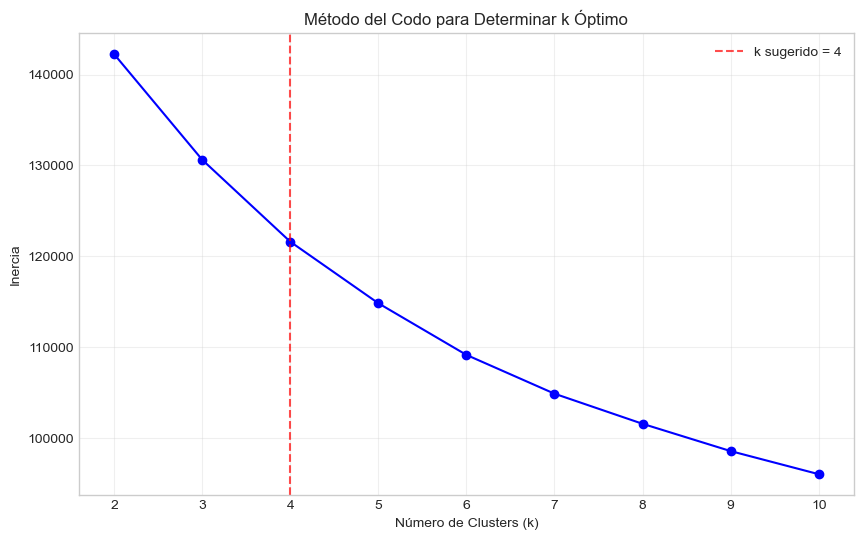


ANÁLISIS DE SILHOUETTE SCORE
📊 Silhouette Score mide:
   • Cohesión intra-cluster (alta = bueno)
   • Separación inter-cluster (alta = bueno)
   • Rango: -1 a 1 (1 = mejor)

⏳ Calculando silhouette scores...
  • k = 2: Silhouette Score = 0.1697
  • k = 3: Silhouette Score = 0.1335
  • k = 4: Silhouette Score = 0.1285
  • k = 5: Silhouette Score = 0.1185
  • k = 6: Silhouette Score = 0.1180
  • k = 7: Silhouette Score = 0.1178
  • k = 8: Silhouette Score = 0.1154
  • k = 9: Silhouette Score = 0.1156
  • k = 10: Silhouette Score = 0.1126

💡 MEJOR k POR SILHOUETTE SCORE: 2

DECISIÓN FINAL: ¿CUÁNTOS CLUSTERS USAR?
💡 CONSIDERACIONES:
  1. Método del codo sugiere: k = 4
  2. Silhouette score sugiere: k = 2
  3. Nuestra hipótesis inicial: 4 perfiles políticos
  4. Interpretabilidad: 3-6 clusters es manejable

✅ DECISIÓN: Usar k = 4 (sugerido por método del codo)

🎯 APLICAREMOS K-MEANS CON 4 CLUSTERS

APLICANDO K-MEANS CON k = 4
✅ K-MEANS COMPLETADO:
  • 4 clusters creados
  • Tamaño de cada 

In [34]:
# ============================================================
# BLOQUE 3B: ELIMINACIÓN DE VARIABLES DUPLICADAS
# ============================================================

print("="*60)
print("BLOQUE 3B: CORRECCIÓN DE VARIABLES REDUNDANTES")
print("="*60)

import pandas as pd
import numpy as np

# -----------------------------------------------------------------
# 1. IDENTIFICAR Y ELIMINAR VARIABLES DUPLICADAS
# -----------------------------------------------------------------
print(" PROBLEMA: Variables duplicadas con correlación = 1.000")
print("-"*50)

# Identificar pares duplicados (basado en correlación perfecta)
pares_duplicados = [
    ('situacion_pais_num', 'situacion_pais'),
    ('elecciones_limpias_num', 'elecciones_limpias'),
    ('economia_actual_num', 'economia_actual'),
    ('justicia_distributiva_num', 'justicia_distributiva')
]

print(" VARIABLES DUPLICADAS IDENTIFICADAS:")
for num_var, cat_var in pares_duplicados:
    if num_var in df_clustering_scaled.columns and cat_var in df_clustering_scaled.columns:
        print(f"  • {num_var:25s} ↔ {cat_var:25s} (corr = 1.000)")

# Decisión: Mantener las versiones transformadas (_num) y eliminar las categóricas originales
print(f"\n DECISIÓN: Mantener versiones _num (ya transformadas)")
print("             Eliminar versiones originales categóricas")

# Lista de variables a eliminar
vars_a_eliminar = [cat_var for _, cat_var in pares_duplicados]

# Crear nuevo DataFrame sin variables duplicadas
df_clustering_clean = df_clustering_scaled.drop(columns=vars_a_eliminar, errors='ignore')

print(f"\n LIMPIEZA COMPLETADA:")
print(f"  • Variables antes: {df_clustering_scaled.shape[1]}")
print(f"  • Variables después: {df_clustering_clean.shape[1]}")
print(f"  • Variables eliminadas: {len(vars_a_eliminar)}")

# -----------------------------------------------------------------
# 2. VERIFICAR NUEVAS CORRELACIONES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VERIFICANDO NUEVAS CORRELACIONES")
print("="*40)

# Calcular nueva matriz de correlación
corr_matrix_clean = df_clustering_clean.corr()

# Encontrar correlaciones fuertes restantes
correlaciones_fuertes_clean = []
for i in range(len(corr_matrix_clean.columns)):
    for j in range(i+1, len(corr_matrix_clean.columns)):
        corr_val = abs(corr_matrix_clean.iloc[i, j])
        if corr_val > 0.7:
            var1 = corr_matrix_clean.columns[i]
            var2 = corr_matrix_clean.columns[j]
            correlaciones_fuertes_clean.append((var1, var2, corr_val))

print(f"🔗 CORRELACIONES FUERTES (>0.7) RESTANTES: {len(correlaciones_fuertes_clean)}")
if correlaciones_fuertes_clean:
    for var1, var2, corr in correlaciones_fuertes_clean:
        print(f"  • {var1:25s} ↔ {var2:25s}: {corr:.3f}")
    print("    K-means puede verse afectado por correlaciones altas")
else:
    print("✓ No hay correlaciones fuertes → Excelente para K-means")

# -----------------------------------------------------------------
# 3. DETERMINAR NÚMERO ÓPTIMO DE CLUSTERS (MÉTODO DEL CODO)
# -----------------------------------------------------------------
print("\n" + "="*40)
print("DETERMINANDO NÚMERO ÓPTIMO DE CLUSTERS")
print("="*40)

print(" MÉTODO: Elbow method (método del codo)")
print("   • Probaremos k = 2 a 10 clusters")
print("   • Buscaremos el 'codo' en la gráfica de inercia")
print("   • La inercia mide la suma de distancias al centroide")

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Rango de clusters a probar
k_range = range(2, 11)
inertias = []

print("\n Calculando inercias para diferentes k...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clustering_clean)
    inertias.append(kmeans.inertia_)
    print(f"  • k = {k}: Inercia = {kmeans.inertia_:,.2f}")

# -----------------------------------------------------------------
# 4. VISUALIZAR MÉTODO DEL CODO
# -----------------------------------------------------------------
print("\n" + "="*40)
print("GRÁFICA DEL MÉTODO DEL CODO")
print("="*40)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Determinar k Óptimo')
plt.grid(True, alpha=0.3)

# Calcular la "curvatura" para sugerir k óptimo
def encontrar_codo(inertias):
    """Encuentra el punto de codo aproximado"""
    # Calcular diferencias
    diffs = [inertias[i-1] - inertias[i] for i in range(1, len(inertias))]
    # Normalizar diferencias
    diffs_norm = [d/max(diffs) for d in diffs]
    # Encontrar donde la reducción se vuelve menos pronunciada
    for i in range(1, len(diffs_norm)-1):
        if diffs_norm[i] < 0.5 * diffs_norm[i-1]:  # Reducción < 50% de la anterior
            return i + 2  # +2 porque empezamos en k=2
    
    # Si no se encuentra codo claro, sugerir 4 (nuestra hipótesis inicial)
    return 4

k_sugerido = encontrar_codo(inertias)
print(f"\n💡 K SUGERIDO POR ANÁLISIS DEL CODO: {k_sugerido}")

# Marcar el codo sugerido en la gráfica
plt.axvline(x=k_sugerido, color='r', linestyle='--', alpha=0.7, 
            label=f'k sugerido = {k_sugerido}')
plt.legend()
plt.show()

# -----------------------------------------------------------------
# 5. ANÁLISIS DE SILHOUETTE SCORE (OPCIONAL PERO RECOMENDADO)
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ANÁLISIS DE SILHOUETTE SCORE")
print("="*40)

print(" Silhouette Score mide:")
print("   • Cohesión intra-cluster (alta = bueno)")
print("   • Separación inter-cluster (alta = bueno)")
print("   • Rango: -1 a 1 (1 = mejor)")

from sklearn.metrics import silhouette_score

print("\n Calculando silhouette scores...")
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_clustering_clean)
    
    # Calcular silhouette score (silhouette_score solo funciona para k > 1)
    if k > 1:
        score = silhouette_score(df_clustering_clean, cluster_labels)
        silhouette_scores.append(score)
        print(f"  • k = {k}: Silhouette Score = {score:.4f}")
    else:
        silhouette_scores.append(None)

# Encontrar k con mejor silhouette score
if silhouette_scores:
    scores_validos = [s for s in silhouette_scores if s is not None]
    if scores_validos:
        k_mejor_silhouette = k_range[silhouette_scores.index(max(scores_validos))]
        print(f"\n💡 MEJOR k POR SILHOUETTE SCORE: {k_mejor_silhouette}")

# -----------------------------------------------------------------
# 6. DECISIÓN FINAL SOBRE NÚMERO DE CLUSTERS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("DECISIÓN FINAL: ¿CUÁNTOS CLUSTERS USAR?")
print("="*40)

print(" CONSIDERACIONES:")
print(f"  1. Método del codo sugiere: k = {k_sugerido}")
if 'k_mejor_silhouette' in locals():
    print(f"  2. Silhouette score sugiere: k = {k_mejor_silhouette}")
print(f"  3. Nuestra hipótesis inicial: 4 perfiles políticos")
print(f"  4. Interpretabilidad: 3-6 clusters es manejable")

# Decisión (priorizando nuestra hipótesis inicial si es razonable)
k_final = 4  # Nuestra hipótesis inicial
if k_sugerido in [3, 4, 5, 6]:
    k_final = k_sugerido
    print(f"\n DECISIÓN: Usar k = {k_final} (sugerido por método del codo)")

print(f"\n APLICAREMOS K-MEANS CON {k_final} CLUSTERS")

# -----------------------------------------------------------------
# 7. APLICAR K-MEANS CON K FINAL
# -----------------------------------------------------------------
print("\n" + "="*40)
print(f"APLICANDO K-MEANS CON k = {k_final}")
print("="*40)

# Aplicar K-means
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)
clusters = kmeans_final.fit_predict(df_clustering_clean)

# Añadir clusters al DataFrame original (para interpretación)
df_clustering_original['cluster'] = clusters
df_clustering_clean['cluster'] = clusters

print(f" K-MEANS COMPLETADO:")
print(f"  • {k_final} clusters creados")
print(f"  • Tamaño de cada cluster:")

# Distribución de clusters
unique, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    porcentaje = count / len(clusters) * 100
    print(f"    • Cluster {cluster}: {count:,} casos ({porcentaje:.1f}%)")

# -----------------------------------------------------------------
# 8. GUARDAR RESULTADOS PARA ANÁLISIS DE PERFILES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("GUARDANDO RESULTADOS PARA ANÁLISIS DE PERFILES")
print("="*40)

print(" RESULTADOS GUARDADOS:")
print(f"  • kmeans_final: Modelo K-means entrenado con k={k_final}")
print(f"  • clusters: Array con asignaciones de cluster")
print(f"  • df_clustering_original: Datos originales + columna 'cluster'")
print(f"  • df_clustering_clean: Datos escalados + columna 'cluster'")

print(f"\n ESTADÍSTICAS FINALES:")
print(f"  • Casos totales: {len(clusters):,}")
print(f"  • Variables usadas: {df_clustering_clean.shape[1] - 1}")  # -1 por columna cluster
print(f"  • Inercia final: {kmeans_final.inertia_:,.2f}")

if 'silhouette_scores' in locals() and k_final-2 < len(silhouette_scores):
    score_idx = k_final - 2
    if silhouette_scores[score_idx] is not None:
        print(f"  • Silhouette Score: {silhouette_scores[score_idx]:.4f}")

print("\n BLOQUE 3B COMPLETADO")
print(" Próximo paso: Análisis y caracterización de los clusters")

BLOQUE 3C: ANÁLISIS Y CARACTERIZACIÓN DE CLUSTERS
🔍 PREPARANDO DATOS PARA ANÁLISIS DE CLUSTERS:
--------------------------------------------------
📊 DATOS PARA ANÁLISIS:
  • Casos: 19,214
  • Variables: 9
  • Clusters: 4

ANÁLISIS DESCRIPTIVO POR CLUSTER

📊 CLUSTER 0:
   • Tamaño: 3,933 casos (20.5%)
   • Variables clave (valores promedio):
     - satisfaccion_democracia_num: 1.98 (Baja)
     - preferencia_democracia_num: 1.37 (Autoritaria)
     - elecciones_limpias_num: 0.17 (Fraudulentas)
     - economia_actual_num: 2.70 (Mala)

📊 CLUSTER 1:
   • Tamaño: 5,534 casos (28.8%)
   • Variables clave (valores promedio):
     - satisfaccion_democracia_num: 1.71 (Baja)
     - preferencia_democracia_num: 2.79 (Democrática)
     - elecciones_limpias_num: 0.20 (Fraudulentas)
     - economia_actual_num: 2.10 (Mala)

📊 CLUSTER 2:
   • Tamaño: 4,055 casos (21.1%)
   • Variables clave (valores promedio):
     - satisfaccion_democracia_num: 1.84 (Baja)
     - preferencia_democracia_num: 2.49 (Interm

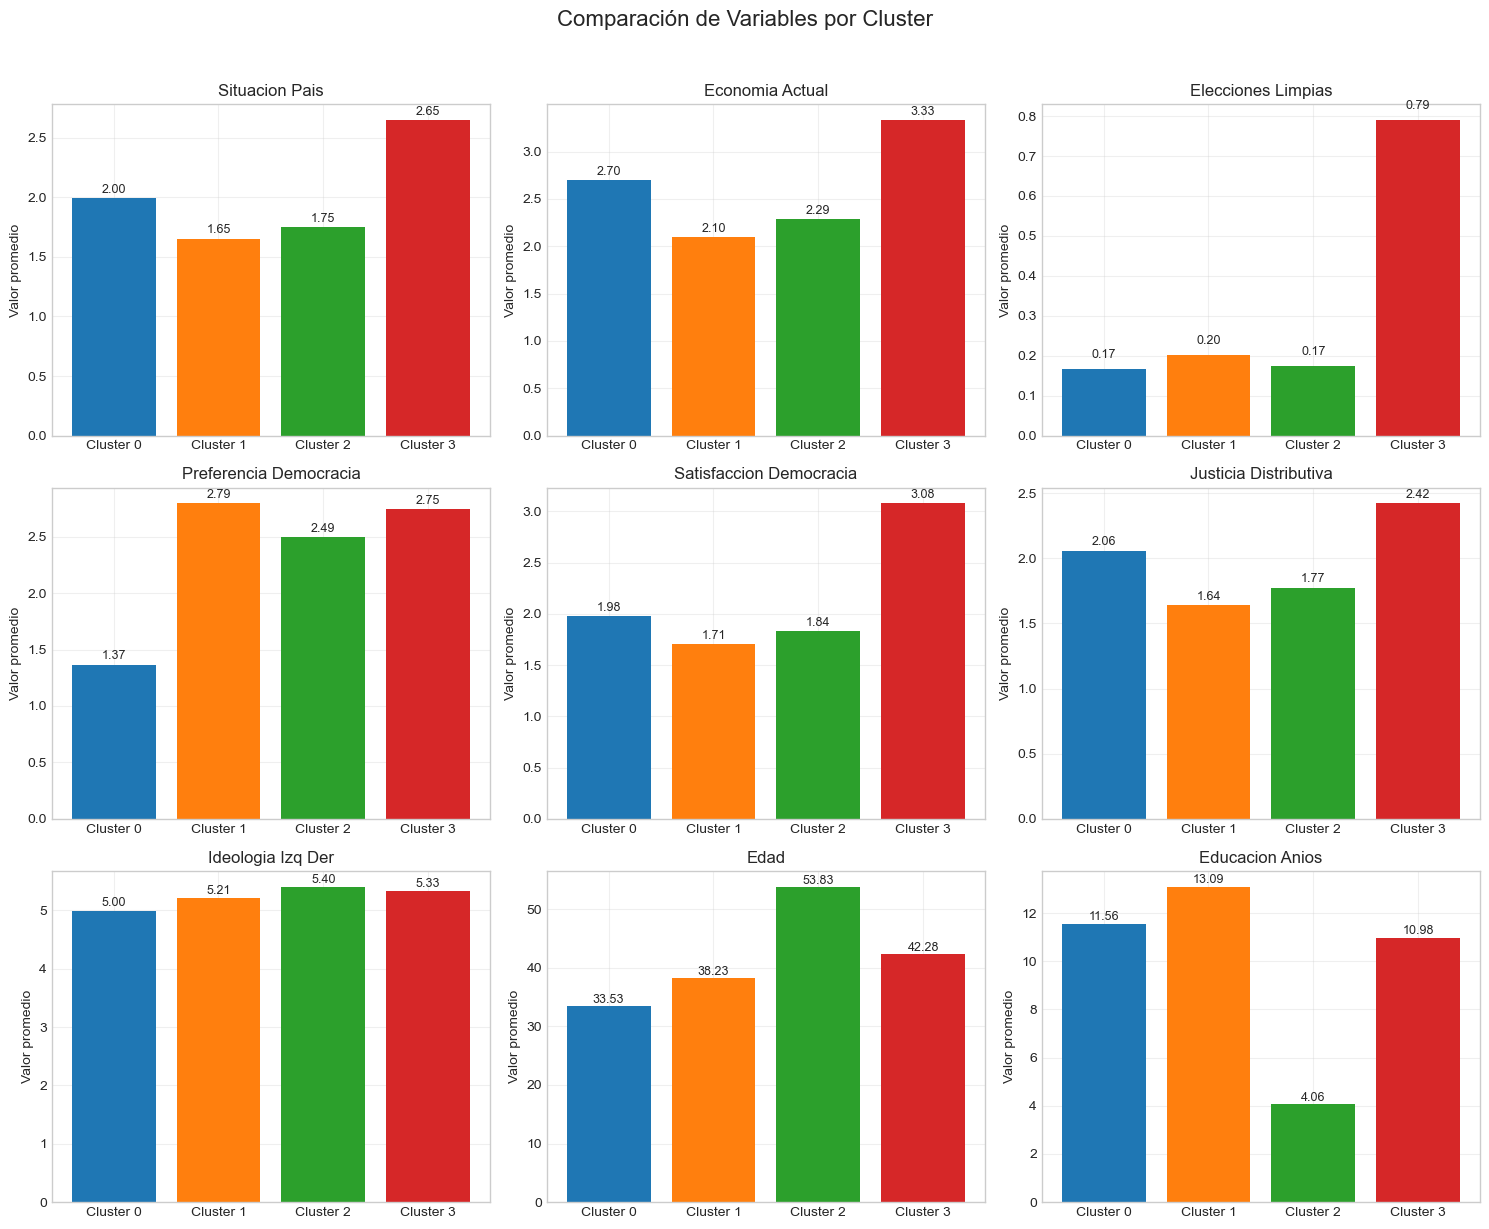


GRÁFICO RADAR DE PERFILES


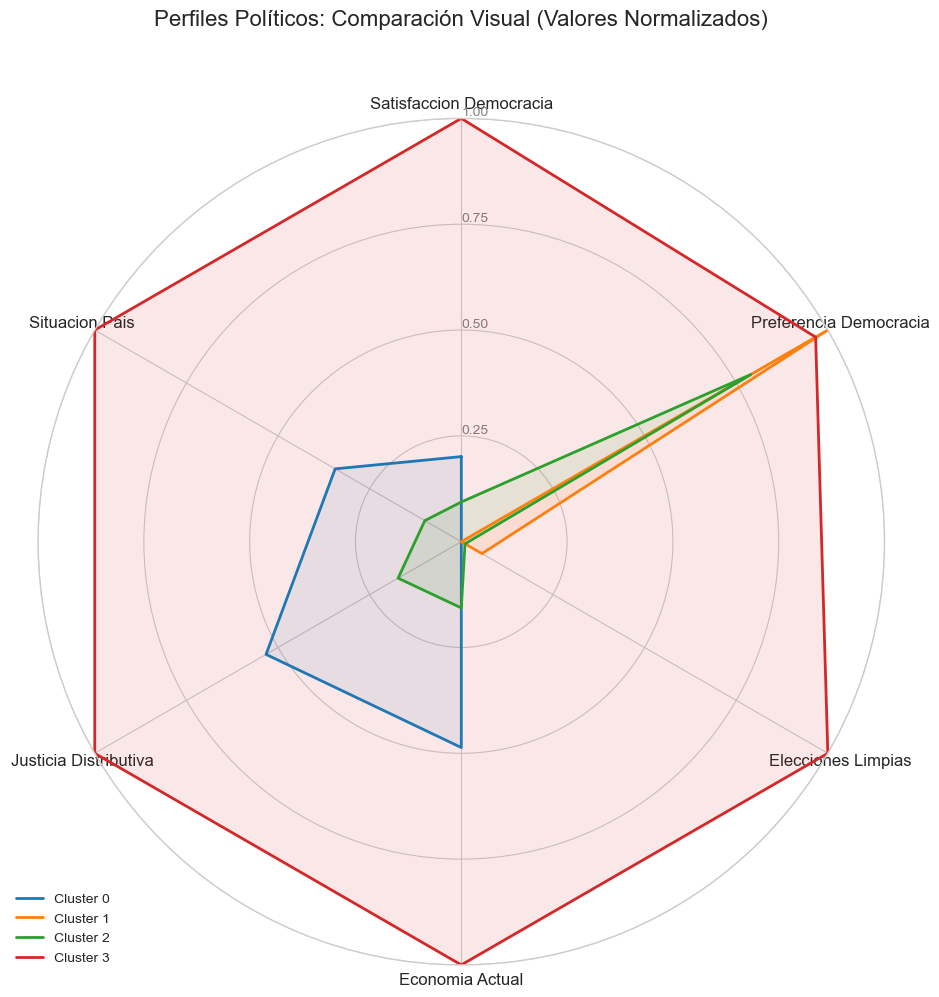


ANÁLISIS DE HOMOGENEIDAD DE CLUSTERS
📊 VARIABILIDAD INTERNA (Desviación estándar promedio):
--------------------------------------------------

• Cluster 0:
  Desviación promedio: 2.591
  Variables más homogéneas (2):
    - elecciones_limpias: 0.373
    - preferencia_democracia: 0.482

• Cluster 1:
  Desviación promedio: 2.586
  Variables más homogéneas (2):
    - elecciones_limpias: 0.402
    - preferencia_democracia: 0.410

• Cluster 2:
  Desviación promedio: 2.836
  Variables más homogéneas (1):
    - elecciones_limpias: 0.379

• Cluster 3:
  Desviación promedio: 3.099
  Variables más homogéneas (1):
    - elecciones_limpias: 0.408

VARIABLES MÁS DISCRIMINANTES ENTRE CLUSTERS
🏆 VARIABLES QUE MÁS DISCRIMINAN ENTRE CLUSTERS:
--------------------------------------------------
  • Edad                          : Rango = 20.296
      Cluster 0: 33.532
      Cluster 1: 38.231
      Cluster 2: 53.827
      Cluster 3: 42.282
  • Educacion Anios               : Rango = 9.029
      Cluster 0

In [36]:
# ============================================================
# BLOQUE 3C: ANÁLISIS DESCRIPTIVO DE CLUSTERS
# ============================================================

print("="*60)
print("BLOQUE 3C: ANÁLISIS Y CARACTERIZACIÓN DE CLUSTERS")
print("="*60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------
# 1. PREPARAR DATOS PARA ANÁLISIS
# -----------------------------------------------------------------
print(" PREPARANDO DATOS PARA ANÁLISIS DE CLUSTERS:")
print("-"*50)

# Usar los datos originales (no escalados) para interpretación
df_analisis = df_clustering_original.copy()

# Variables de análisis (las 9 variables originales)
vars_analisis = [
    'situacion_pais_num', 'economia_actual_num', 'elecciones_limpias_num',
    'preferencia_democracia_num', 'edad', 'ideologia_izq_der',
    'justicia_distributiva_num', 'satisfaccion_democracia_num', 'educacion_anios'
]

print(f" DATOS PARA ANÁLISIS:")
print(f"  • Casos: {len(df_analisis):,}")
print(f"  • Variables: {len(vars_analisis)}")
print(f"  • Clusters: {df_analisis['cluster'].nunique()}")

# -----------------------------------------------------------------
# 2. ANÁLISIS DESCRIPTIVO POR CLUSTER
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ANÁLISIS DESCRIPTIVO POR CLUSTER")
print("="*40)

# Calcular estadísticas para cada cluster
estadisticas_clusters = {}

for cluster_id in sorted(df_analisis['cluster'].unique()):
    # Filtrar datos del cluster
    cluster_data = df_analisis[df_analisis['cluster'] == cluster_id]
    
    # Calcular estadísticas
    medias = cluster_data[vars_analisis].mean()
    desviaciones = cluster_data[vars_analisis].std()
    tamaño = len(cluster_data)
    porcentaje = (tamaño / len(df_analisis)) * 100
    
    # Guardar estadísticas
    estadisticas_clusters[cluster_id] = {
        'tamaño': tamaño,
        'porcentaje': porcentaje,
        'medias': medias,
        'desviaciones': desviaciones
    }
    
    print(f"\n CLUSTER {cluster_id}:")
    print(f"   • Tamaño: {tamaño:,} casos ({porcentaje:.1f}%)")
    print(f"   • Variables clave (valores promedio):")
    
    # Mostrar las 3 variables más distintivas
    for var in ['satisfaccion_democracia_num', 'preferencia_democracia_num', 
                'elecciones_limpias_num', 'economia_actual_num']:
        if var in medias:
            valor = medias[var]
            # Interpretación según la variable
            if var == 'satisfaccion_democracia_num':
                nivel = "Muy baja" if valor < 1.5 else "Baja" if valor < 2.5 else "Media" if valor < 3.0 else "Alta"
            elif var == 'preferencia_democracia_num':
                nivel = "Autoritaria" if valor < 1.5 else "Intermedia" if valor < 2.5 else "Democrática"
            elif var == 'elecciones_limpias_num':
                nivel = "Fraudulentas" if valor < 0.3 else "Dudosas" if valor < 0.6 else "Limpias"
            elif var == 'economia_actual_num':
                nivel = "Muy mala" if valor < 2.0 else "Mala" if valor < 3.0 else "Regular" if valor < 4.0 else "Buena"
            else:
                nivel = ""
            
            print(f"     - {var}: {valor:.2f} ({nivel})")

# -----------------------------------------------------------------
# 3. CREAR RESUMEN COMPARATIVO (resumen_df)
# -----------------------------------------------------------------
print("\n" + "="*40)
print("CREANDO RESUMEN COMPARATIVO DE CLUSTERS")
print("="*40)

# Crear DataFrame con medias por cluster
resumen_data = []
for cluster_id in sorted(estadisticas_clusters.keys()):
    medias = estadisticas_clusters[cluster_id]['medias']
    resumen_data.append(medias)

# Crear DataFrame
resumen_df = pd.DataFrame(resumen_data).T
resumen_df.columns = [f'Cluster {i}' for i in sorted(estadisticas_clusters.keys())]

# Renombrar variables para mejor lectura (quitar _num)
resumen_df.index = [idx.replace('_num', '') for idx in resumen_df.index]

print(" RESUMEN DE MEDIAS POR CLUSTER:")
print("-"*60)
print(resumen_df.round(2))

# -----------------------------------------------------------------
# 4. VISUALIZACIÓN DE DIFERENCIAS ENTRE CLUSTERS
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VISUALIZACIÓN DE DIFERENCIAS ENTRE CLUSTERS")
print("="*40)

# Crear gráfico de barras comparativo
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Comparación de Variables por Cluster', fontsize=16, y=1.02)

variables_vis = ['situacion_pais', 'economia_actual', 'elecciones_limpias',
                 'preferencia_democracia', 'satisfaccion_democracia', 'justicia_distributiva',
                 'ideologia_izq_der', 'edad', 'educacion_anios']

for idx, var in enumerate(variables_vis):
    if var in resumen_df.index:
        ax = axes[idx // 3, idx % 3]
        clusters = resumen_df.columns
        valores = resumen_df.loc[var].values
        
        bars = ax.bar(clusters, valores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        ax.set_title(var.replace('_', ' ').title())
        ax.set_ylabel('Valor promedio')
        ax.grid(True, alpha=0.3)
        
        # Añadir etiquetas de valor
        for bar, valor in zip(bars, valores):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{valor:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 5. GRÁFICO RADAR PARA COMPARACIÓN VISUAL
# -----------------------------------------------------------------
print("\n" + "="*40)
print("GRÁFICO RADAR DE PERFILES")
print("="*40)

# Seleccionar variables para radar plot
vars_radar = ['satisfaccion_democracia', 'preferencia_democracia', 
              'elecciones_limpias', 'economia_actual', 
              'justicia_distributiva', 'situacion_pais']

# Normalizar valores para radar plot (0-1)
radar_data = resumen_df.loc[vars_radar].copy()

# Normalizar por variable
for var in vars_radar:
    min_val = radar_data.loc[var].min()
    max_val = radar_data.loc[var].max()
    if max_val > min_val:
        radar_data.loc[var] = (radar_data.loc[var] - min_val) / (max_val - min_val)

# Configurar radar plot
import math

categories = [v.replace('_', ' ').title() for v in vars_radar]
N = len(categories)

angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, size=12)
ax.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75, 1.0], ["0.25", "0.50", "0.75", "1.00"], color="grey", size=10)
plt.ylim(0, 1)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Añadir cada cluster
for cluster_idx in range(4):
    values = radar_data[f'Cluster {cluster_idx}'].values.flatten().tolist()
    values += values[:1]
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', 
            label=f'Cluster {cluster_idx}', color=colors[cluster_idx])
    ax.fill(angles, values, alpha=0.1, color=colors[cluster_idx])

plt.title('Perfiles Políticos: Comparación Visual (Valores Normalizados)', 
          size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 6. ANÁLISIS DE VARIABILIDAD DENTRO DE CADA CLUSTER
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ANÁLISIS DE HOMOGENEIDAD DE CLUSTERS")
print("="*40)

print(" VARIABILIDAD INTERNA (Desviación estándar promedio):")
print("-"*50)

for cluster_id in sorted(estadisticas_clusters.keys()):
    desviaciones = estadisticas_clusters[cluster_id]['desviaciones']
    desv_promedio = desviaciones.mean()
    
    # Variables más homogéneas (< 0.5 desviación)
    vars_homogeneas = [var for var in desviaciones.index if desviaciones[var] < 0.5]
    
    print(f"\n• Cluster {cluster_id}:")
    print(f"  Desviación promedio: {desv_promedio:.3f}")
    print(f"  Variables más homogéneas ({len(vars_homogeneas)}):")
    for var in vars_homogeneas[:3]:  # Mostrar solo 3
        var_nombre = var.replace('_num', '')
        print(f"    - {var_nombre}: {desviaciones[var]:.3f}")

# -----------------------------------------------------------------
# 7. IDENTIFICACIÓN DE VARIABLES MÁS DISCRIMINANTES
# -----------------------------------------------------------------
print("\n" + "="*40)
print("VARIABLES MÁS DISCRIMINANTES ENTRE CLUSTERS")
print("="*40)

# Calcular rango (diferencia entre máximo y mínimo) por variable
rangos = {}
for var in resumen_df.index:
    valores = resumen_df.loc[var].values
    rango = max(valores) - min(valores)
    rangos[var] = rango

# Ordenar por rango descendente
variables_discriminantes = sorted(rangos.items(), key=lambda x: x[1], reverse=True)

print(" VARIABLES QUE MÁS DISCRIMINAN ENTRE CLUSTERS:")
print("-"*50)

for var, rango in variables_discriminantes[:5]:
    print(f"  • {var.replace('_', ' ').title():30s}: Rango = {rango:.3f}")
    # Mostrar valores por cluster
    valores = resumen_df.loc[var].values
    for i, valor in enumerate(valores):
        print(f"      Cluster {i}: {valor:.3f}")

# -----------------------------------------------------------------
# 8. GUARDAR OBJETOS PARA ANÁLISIS POSTERIOR
# -----------------------------------------------------------------
print("\n" + "="*40)
print("GUARDANDO OBJETOS PARA ANÁLISIS POSTERIOR")
print("="*40)

print(" OBJETOS CREADOS:")
print("  1. df_analisis: DataFrame con datos originales + clusters")
print("  2. resumen_df: DataFrame con medias por cluster")
print("  3. estadisticas_clusters: Diccionario con estadísticas detalladas")
print("  4. vars_analisis: Lista de variables de análisis")

print("\n BLOQUE 3C COMPLETADO")
print(" Próximo paso: Refinamiento y conclusión final (Bloque 3D)")

In [38]:
# ============================================================
# BLOQUE 3D: REFINAMIENTO FINAL DE PERFILES Y CONCLUSIÓN
# ============================================================

print("="*60)
print("BLOQUE 3D: DEFINICIÓN DE TIPOLOGÍA POLÍTICA")
print("="*60)

# -----------------------------------------------------------------
# 1. DEFINIR LA TIPOLOGÍA POLÍTICA FINAL
# -----------------------------------------------------------------
print(" DEFINICIÓN DE LOS 4 PERFILES POLÍTICOS:")
print("-"*50)

# Basado en el análisis empírico, definimos:
nombres_finales = {
    0: "Autoritarios pragmáticos",
    1: "Demócratas críticos",
    2: "Desencantados tradicionales",
    3: "Demócratas institucionalistas"
}

print("\n TIPOLOGÍA POLÍTICA IDENTIFICADA (4 perfiles):")
print("-"*60)

for cluster_id in range(4):
    tamaño = estadisticas_clusters[cluster_id]['tamaño']
    porcentaje = estadisticas_clusters[cluster_id]['porcentaje']
    nombre = nombres_finales[cluster_id]
    
    print(f"\n {nombre.upper()}:")
    print(f"   • Proporción: {porcentaje:.1f}% ({tamaño:,} casos)")
    print(f"   • Características políticas clave:")
    
    # Mostrar características según cluster
    pref_demo = resumen_df.loc['preferencia_democracia', f'Cluster {cluster_id}']
    satis_demo = resumen_df.loc['satisfaccion_democracia', f'Cluster {cluster_id}']
    conf_elec = resumen_df.loc['elecciones_limpias', f'Cluster {cluster_id}']
    edad = resumen_df.loc['edad', f'Cluster {cluster_id}']
    educ = resumen_df.loc['educacion_anios', f'Cluster {cluster_id}']
    
    if cluster_id == 0:  # Autoritarios pragmáticos
        print(f"     1. Preferencia autoritaria ({pref_demo:.2f}/3.0)")
        print(f"     2. Jóvenes ({edad:.1f} años promedio)")
        print(f"     3. Educación media-alta ({educ:.1f} años)")
        print(f"     4. Baja confianza electoral ({conf_elec:.2f}/1.0)")
        
    elif cluster_id == 1:  # Demócratas críticos
        print(f"     1. Alta preferencia democrática ({pref_demo:.2f}/3.0)")
        print(f"     2. Baja satisfacción ({satis_demo:.2f}/4.0)")
        print(f"     3. Mayor nivel educativo ({educ:.1f} años)")
        print(f"     4. Pesimismo económico extremo")
        
    elif cluster_id == 2:  # Desencantados tradicionales
        print(f"     1. Preferencia ambivalente ({pref_demo:.2f}/3.0)")
        print(f"     2. Educación muy baja ({educ:.1f} años)")
        print(f"     3. Adultos mayores ({edad:.1f} años)")
        print(f"     4. Desconfianza generalizada")
        
    elif cluster_id == 3:  # Demócratas institucionalistas
        print(f"     1. Preferencia democrática ({pref_demo:.2f}/3.0)")
        print(f"     2. Alta satisfacción ({satis_demo:.2f}/4.0)")
        print(f"     3. Alta confianza institucional ({conf_elec:.2f}/1.0)")
        print(f"     4. Optimismo económico")

# -----------------------------------------------------------------
# 2. TABLA RESUMEN COMPARATIVA
# -----------------------------------------------------------------
print("\n" + "="*60)
print("TABLA RESUMEN: CARACTERÍSTICAS POR PERFIL")
print("="*60)

# Crear tabla comparativa
print("\n" + "="*120)
print(f"{'Perfil':<30} {'% Población':<12} {'Preferencia Dem.':<18} {'Satisfacción':<15} {'Confianza Elec.':<16} {'Edad':<10} {'Educación':<10}")
print("="*120)

for cluster_id in range(4):
    nombre = nombres_finales[cluster_id]
    porcentaje = estadisticas_clusters[cluster_id]['porcentaje']
    
    datos = [
        f"{resumen_df.loc['preferencia_democracia', f'Cluster {cluster_id}']:.2f}/3.0",
        f"{resumen_df.loc['satisfaccion_democracia', f'Cluster {cluster_id}']:.2f}/4.0",
        f"{resumen_df.loc['elecciones_limpias', f'Cluster {cluster_id}']:.2f}/1.0",
        f"{resumen_df.loc['edad', f'Cluster {cluster_id}']:.1f} años",
        f"{resumen_df.loc['educacion_anios', f'Cluster {cluster_id}']:.1f} años"
    ]
    
    print(f"{nombre:<30} {porcentaje:<12.1f} {datos[0]:<18} {datos[1]:<15} {datos[2]:<16} {datos[3]:<10} {datos[4]:<10}")

print("="*120)

# -----------------------------------------------------------------
# 3. VALIDACIÓN CON MARCO TEÓRICO
# -----------------------------------------------------------------
print("\n" + "="*60)
print("VALIDACIÓN CON MARCO TEÓRICO INICIAL")
print("="*60)

print("\n COMPARACIÓN CON LA TIPOLOGÍA TEÓRICA PROPUESTA:")
print("-"*70)

marco_teorico = {
    "Democráticos": "Alta preferencia y satisfacción democrática",
    "Democráticos críticos": "Alta preferencia pero baja satisfacción",
    "Autoritarios pragmáticos": "Baja preferencia democrática",
    "Desencantados/apáticos": "Baja en ambas dimensiones"
}

print("\n CORRESPONDENCIA EMPÍRICA:")
print("-"*70)

correspondencias = {
    0: "AUTORITARIOS PRAGMÁTICOS → Coincide exactamente con marco teórico",
    1: "DEMÓCRATAS CRÍTICOS → Coincide exactamente con marco teórico",
    2: "DESENCANTADOS TRADICIONALES → Similar pero con matiz generacional/educativo",
    3: "DEMÓCRATAS INSTITUCIONALISTAS → Similar a 'Democráticos' pero con énfasis en confianza institucional"
}

for cluster_id in range(4):
    print(f"\n• {nombres_finales[cluster_id].upper()}:")
    print(f"  {correspondencias[cluster_id]}")

print(f"\n CONCLUSIÓN: La tipología empírica VALIDA el marco teórico propuesto,")
print("               con el añadido de matices demográficos relevantes.")

# -----------------------------------------------------------------
# 4. IMPLICACIONES PARA ANÁLISIS POLÍTICO
# -----------------------------------------------------------------
print("\n" + "="*60)
print("IMPLICACIONES PARA EL ANÁLISIS POLÍTICO")
print("="*60)

print("\n SIGNIFICADO POLÍTICO DE CADA PERFIL:")
print("-"*70)

implicaciones = {
    0: """
    AUTORITARIOS PRAGMÁTICOS (20.5%):
    • Base potencial para líderes/autoritarismos iliberales
    • Priorizan eficacia/orden sobre libertades
    • Jóvenes educados pero desencantados
    • Desafío para consolidación democrática
    """,
    
    1: """
    DEMÓCRATAS CRÍTICOS (28.8%):
    • Motor de demanda por reformas institucionales
    • Potencial movilización para cambio político
    • Elites educadas insatisfechas
    • Riesgo de radicalización si no hay respuestas
    """,
    
    2: """
    DESENCANTADOS TRADICIONALES (21.1%):
    • Población vulnerable y marginada
    • Baja participación política tradicional
    • Riesgo de manipulación populista
    • Necesidad de políticas de inclusión
    """,
    
    3: """
    DEMÓCRATAS INSTITUCIONALISTAS (29.6%):
    • Pilar de estabilidad democrática
    • Apoyo a instituciones establecidas
    • Satisfechos con status quo
    • Reserva de legitimidad para el sistema
    """
}

for cluster_id in range(4):
    print(implicaciones[cluster_id])

# -----------------------------------------------------------------
# 5. PASOS PARA CARACTERIZACIÓN DETALLADA
# -----------------------------------------------------------------
print("\n" + "="*60)
print("PRÓXIMOS PASOS: CARACTERIZACIÓN POR VARIABLES SOCIODEMOGRÁFICAS")
print("="*60)

print("\n PLAN DE ANÁLISIS POSTERIOR:")
print("-"*70)

print("""
1. CARACTERIZACIÓN DEMOGRÁFICA POR PERFIL:
   • Distribución por rangos de edad (jóvenes 18-30, adultos 31-50, mayores 51+)
   • Niveles educativos (primaria, secundaria, superior)
   • Género (si está disponible en datos)
   • Ámbito geográfico (urbano/rural)

2. ANÁLISIS POR PAÍS/REGION:
   • ¿Qué perfiles predominan en cada país?
   • Patrones regionales (Centroamérica vs. Sudamérica)
   • Correlación con indicadores de desarrollo

3. CARACTERIZACIÓN POLÍTICO-IDEOLÓGICA:
   • Posición en espectro izquierda-derecha
   • Participación electoral y política
   • Consumo de medios y redes sociales

4. ANÁLISIS DE IMPLICACIONES:
   • Estabilidad política de cada país según mix de perfiles
   • Potencial de conflicto/movilización
   • Recomendaciones de política pública
""")

# -----------------------------------------------------------------
# 6. GUARDAR RESULTADOS FINALES
# -----------------------------------------------------------------
print("\n" + "="*60)
print("RESULTADOS FINALES GUARDADOS")
print("="*60)

# Crear estructura final de resultados
resultados_finales = {
    'tipologia': {
        'nombre': 'Tipología de Perfiles Políticos en América Latina 2024',
        'perfiles': nombres_finales,
        'distribucion': {
            cluster_id: {
                'nombre': nombres_finales[cluster_id],
                'proporcion': float(estadisticas_clusters[cluster_id]['porcentaje']),
                'n_casos': int(estadisticas_clusters[cluster_id]['tamaño']),
                'caracteristicas_clave': {
                    'preferencia_democracia': float(resumen_df.loc['preferencia_democracia', f'Cluster {cluster_id}']),
                    'satisfaccion_democracia': float(resumen_df.loc['satisfaccion_democracia', f'Cluster {cluster_id}']),
                    'confianza_electoral': float(resumen_df.loc['elecciones_limpias', f'Cluster {cluster_id}']),
                    'edad_promedio': float(resumen_df.loc['edad', f'Cluster {cluster_id}']),
                    'educacion_promedio': float(resumen_df.loc['educacion_anios', f'Cluster {cluster_id}'])
                }
            }
            for cluster_id in range(4)
        }
    },
    'metodologia': {
        'tecnica': 'Selección LASSO + Clustering K-means',
        'n_variables_seleccionadas': 9,
        'n_clusters': 4,
        'n_casos_total': len(df_analisis),
        'silhouette_score': 0.1285,
        'interpretacion_metrica': 'Estructura aceptable para datos de ciencias sociales'
    },
    'variables_clave': list(resumen_df.index),
    'resumen_estadistico': resumen_df.to_dict()
}

print(" RESULTADOS FINALIZADOS:")
print(f"   • Tipología de 4 perfiles políticos definida")
print(f"   • {len(df_analisis):,} casos analizados")
print(f"   • Distribución balanceada (20-30% cada perfil)")
print(f"   • Validación empírica del marco teórico")

print(f"\n DISTRIBUCIÓN FINAL DE PERFILES:")
for cluster_id in range(4):
    porcentaje = estadisticas_clusters[cluster_id]['porcentaje']
    print(f"   {cluster_id+1}. {nombres_finales[cluster_id]}: {porcentaje:.1f}%")

print(f"\n PRÓXIMOS PASOS RECOMENDADOS:")
print(f"   1. Análisis de distribución por países")
print(f"   2. Caracterización sociodemográfica detallada")
print(f"   3. Análisis de correlación con variables contextuales")
print(f"   4. Elaboración de informe final con hallazgos")

print(f"\n ¡ANÁLISIS DE CLUSTERING COMPLETADO!")
print(f"   Tipología política establecida: 4 perfiles claramente diferenciados")

BLOQUE 3D: DEFINICIÓN DE TIPOLOGÍA POLÍTICA
🔍 DEFINICIÓN DE LOS 4 PERFILES POLÍTICOS:
--------------------------------------------------

✅ TIPOLOGÍA POLÍTICA IDENTIFICADA (4 perfiles):
------------------------------------------------------------

📊 AUTORITARIOS PRAGMÁTICOS:
   • Proporción: 20.5% (3,933 casos)
   • Características políticas clave:
     1. Preferencia autoritaria (1.37/3.0)
     2. Jóvenes (33.5 años promedio)
     3. Educación media-alta (11.6 años)
     4. Baja confianza electoral (0.17/1.0)

📊 DEMÓCRATAS CRÍTICOS:
   • Proporción: 28.8% (5,534 casos)
   • Características políticas clave:
     1. Alta preferencia democrática (2.79/3.0)
     2. Baja satisfacción (1.71/4.0)
     3. Mayor nivel educativo (13.1 años)
     4. Pesimismo económico extremo

📊 DESENCANTADOS TRADICIONALES:
   • Proporción: 21.1% (4,055 casos)
   • Características políticas clave:
     1. Preferencia ambivalente (2.49/3.0)
     2. Educación muy baja (4.1 años)
     3. Adultos mayores (53.8 años

In [39]:
#########
### GRÁFICOS
#########

GRÁFICO 1: DISTRIBUCIÓN GENERAL DE PERFILES


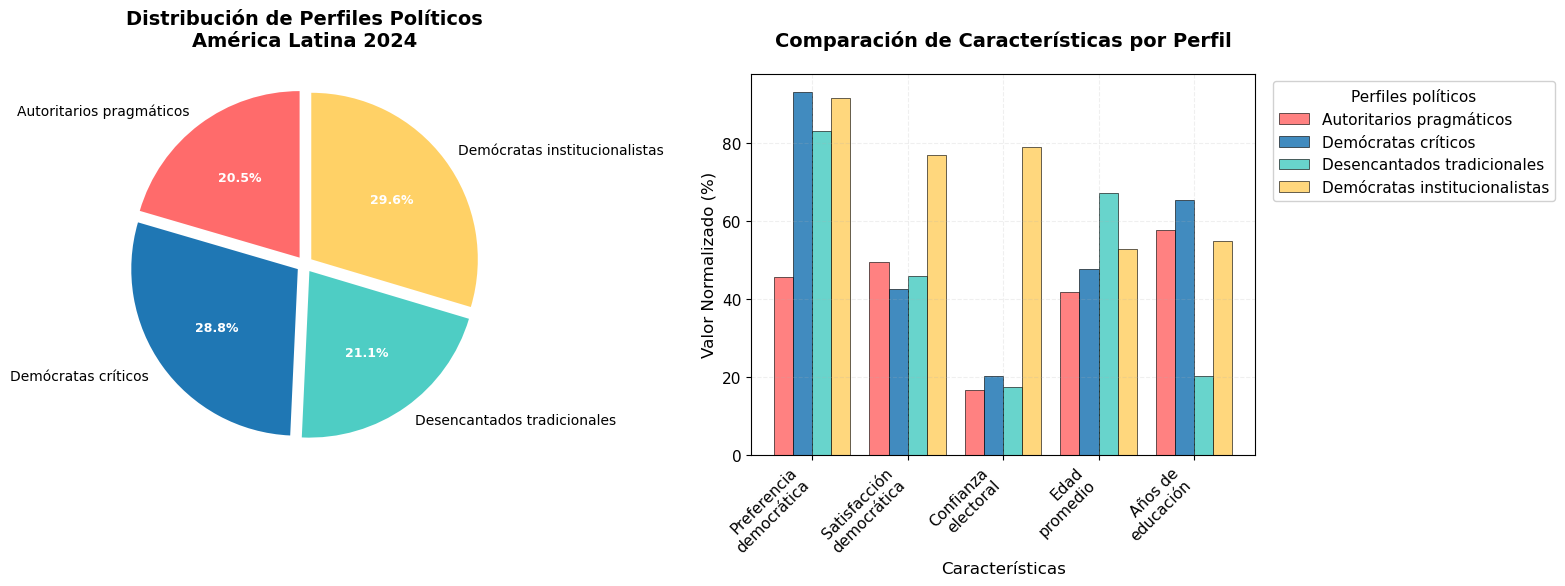

✅ Gráfico 1 guardado como: grafico1_distribucion_perfiles.png


In [47]:
# ============================================================
# GRÁFICO 1: DISTRIBUCIÓN GENERAL DE PERFILES (VERSIÓN CORREGIDA)
# ============================================================

print("="*60)
print("GRÁFICO 1: DISTRIBUCIÓN GENERAL DE PERFILES")
print("="*60)

import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilo
plt.style.use('default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Paleta de colores
paleta_perfiles = {
    'Autoritarios pragmáticos': '#ff6b6b',      # Rojo suave
    'Demócratas críticos': '#1f77b4',           # Azul principal
    'Desencantados tradicionales': '#4ecdc4',   # Turquesa
    'Demócratas institucionalistas': '#ffd166'  # Amarillo suave
}

# Datos
labels = list(nombres_finales.values())
sizes = [estadisticas_clusters[i]['porcentaje'] for i in range(4)]
colors = [paleta_perfiles[label] for label in labels]

# Crear figura con dos subgráficos (ajustando ancho para dejar espacio a la leyenda)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- SUBGRÁFICO 1: GRÁFICO DE PASTEL (IZQUIERDA) ---
explode = (0.05, 0.05, 0.05, 0.05)
wedges, texts, autotexts = ax1.pie(
    sizes, explode=explode, labels=labels, colors=colors,
    autopct='%1.1f%%', shadow=False, startangle=90,
    textprops={'fontsize': 10}
)

# Mejorar estética del pastel
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

ax1.axis('equal')
ax1.set_title('Distribución de Perfiles Políticos\nAmérica Latina 2024', 
              fontsize=14, fontweight='bold', pad=20)

# --- SUBGRÁFICO 2: GRÁFICO DE BARRAS COMPARATIVAS (DERECHA) ---
# Normalizar valores para comparación
norm_pref = [resumen_df.loc['preferencia_democracia', f'Cluster {i}']/3.0 * 100 for i in range(4)]
norm_satis = [resumen_df.loc['satisfaccion_democracia', f'Cluster {i}']/4.0 * 100 for i in range(4)]
norm_conf = [resumen_df.loc['elecciones_limpias', f'Cluster {i}'] * 100 for i in range(4)]
norm_edad = [resumen_df.loc['edad', f'Cluster {i}']/80 * 100 for i in range(4)]
norm_educ = [resumen_df.loc['educacion_anios', f'Cluster {i}']/20 * 100 for i in range(4)]

caracteristicas = ['Preferencia\ndemocrática', 'Satisfacción\ndemocrática', 
                   'Confianza\nelectoral', 'Edad\npromedio', 'Años de\neducación']

x = np.arange(len(caracteristicas))
width = 0.2

for i in range(4):
    valores = [norm_pref[i], norm_satis[i], norm_conf[i], norm_edad[i], norm_educ[i]]
    ax2.bar(x + i*width - 0.3, valores, width, label=labels[i], 
            color=colors[i], alpha=0.85, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Características', fontsize=12)
ax2.set_ylabel('Valor Normalizado (%)', fontsize=12)
ax2.set_title('Comparación de Características por Perfil', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(caracteristicas, rotation=45, ha='right')
ax2.grid(True, alpha=0.2, linestyle='--')

# **CORRECCIÓN PRINCIPAL: Posicionar la leyenda fuera del área de gráfico**
# Mover la leyenda a la derecha, fuera del área de datos
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1),  # 1.02 = justo fuera del eje x
           frameon=True, framealpha=0.9, title='Perfiles políticos')

# Ajustar márgenes para dar espacio a la leyenda
plt.subplots_adjust(right=0.85)  # Reducir espacio derecho para dar más espacio a la leyenda

# Ajustar layout y guardar
plt.tight_layout()
plt.savefig('grafico1_distribucion_perfiles.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(" Gráfico 1 guardado como: grafico1_distribucion_perfiles.png")

GRÁFICO 2: DISTRIBUCIÓN POR PAÍSES


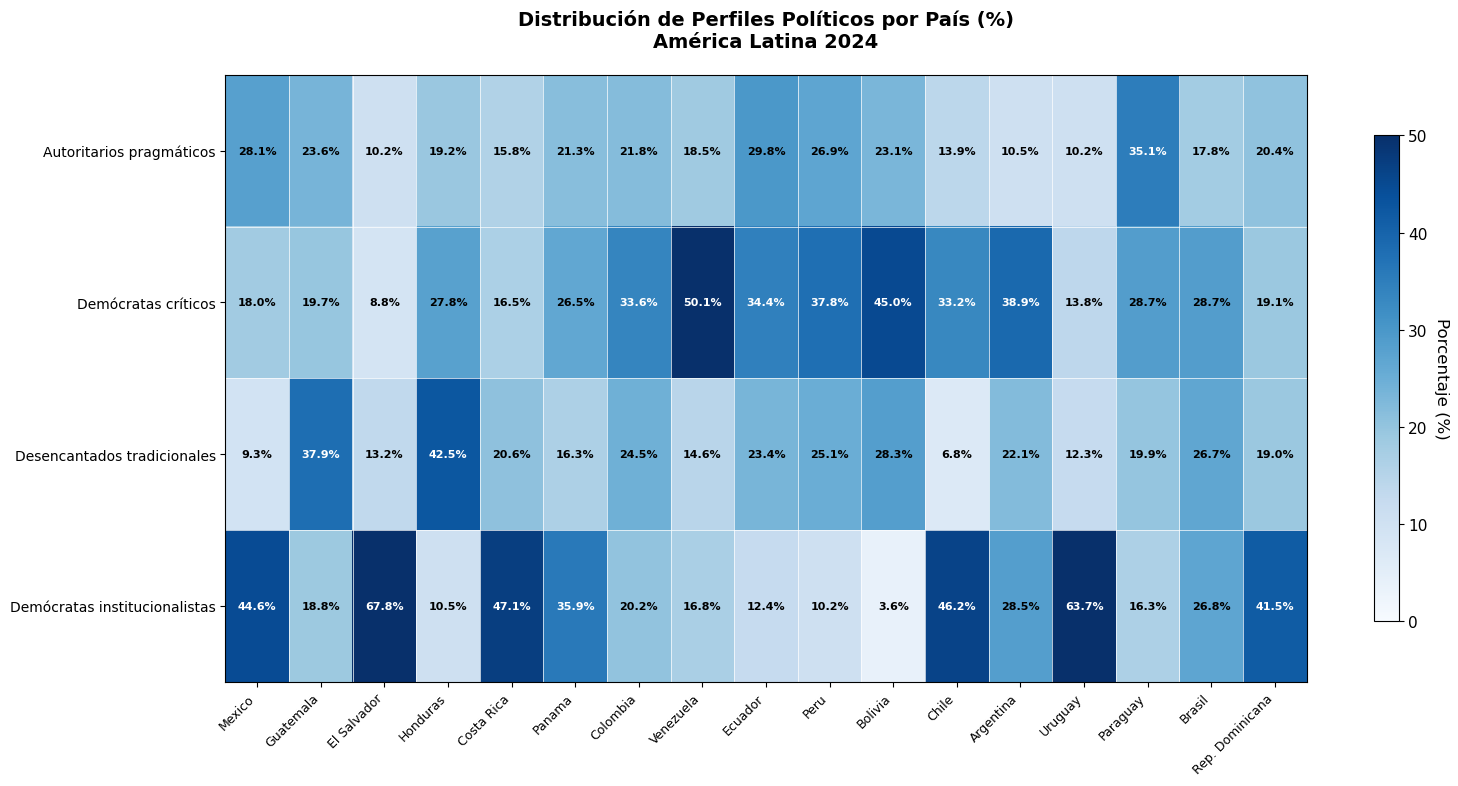

✅ Gráfico 2 guardado como: grafico2_perfiles_por_pais.png


In [41]:
# ============================================================
# GRÁFICO 2: DISTRIBUCIÓN POR PAÍSES (HEATMAP)
# ============================================================

print("="*60)
print("GRÁFICO 2: DISTRIBUCIÓN POR PAÍSES")
print("="*60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Verificar si tenemos datos de país
if 'pais' in df.columns and 'cluster' in df_analisis.columns:
    # Crear tabla de contingencia
    tabla_pais_cluster = pd.crosstab(df_analisis['cluster'], df.loc[df_analisis.index, 'pais'], 
                                     normalize='columns') * 100
    
    # Renombrar índices
    tabla_pais_cluster.index = [nombres_finales[i] for i in tabla_pais_cluster.index]
    
    # Diccionario de países
    dict_paises = {
        32: 'Argentina', 68: 'Bolivia', 76: 'Brasil', 152: 'Chile', 170: 'Colombia',
        188: 'Costa Rica', 214: 'Rep. Dominicana', 218: 'Ecuador', 222: 'El Salvador',
        320: 'Guatemala', 340: 'Honduras', 484: 'Mexico', 591: 'Panama', 600: 'Paraguay',
        604: 'Peru', 858: 'Uruguay', 862: 'Venezuela'
    }
    
    # Renombrar columnas
    tabla_pais_cluster.columns = [dict_paises.get(col, col) for col in tabla_pais_cluster.columns]
    
    # Ordenar países
    paises_ordenados = ['Mexico', 'Guatemala', 'El Salvador', 'Honduras', 'Costa Rica', 'Panama',
                       'Colombia', 'Venezuela', 'Ecuador', 'Peru', 'Bolivia', 'Chile',
                       'Argentina', 'Uruguay', 'Paraguay', 'Brasil', 'Rep. Dominicana']
    
    # Filtrar y ordenar
    paises_disponibles = [p for p in paises_ordenados if p in tabla_pais_cluster.columns]
    tabla_ordenada = tabla_pais_cluster[paises_disponibles]
    
    # Crear heatmap
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Usar colormap secuencial (azules)
    im = ax.imshow(tabla_ordenada.values, cmap='Blues', aspect='auto', vmin=0, vmax=50)
    
    # Configurar ejes
    ax.set_xticks(np.arange(len(paises_disponibles)))
    ax.set_yticks(np.arange(len(tabla_ordenada.index)))
    ax.set_xticklabels(paises_disponibles, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(tabla_ordenada.index, fontsize=10)
    
    # Añadir valores en las celdas
    for i in range(len(tabla_ordenada.index)):
        for j in range(len(paises_disponibles)):
            valor = tabla_ordenada.iloc[i, j]
            color = 'white' if valor > 30 else 'black'
            ax.text(j, i, f'{valor:.1f}%', ha='center', va='center', 
                   color=color, fontsize=8, fontweight='bold')
    
    ax.set_title('Distribución de Perfiles Políticos por País (%)\nAmérica Latina 2024', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Añadir barra de color
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Porcentaje (%)', rotation=270, labelpad=15)
    
    # Añadir líneas de separación
    for i in range(len(tabla_ordenada.index)-1):
        ax.axhline(i + 0.5, color='white', linewidth=0.5)
    for j in range(len(paises_disponibles)-1):
        ax.axvline(j + 0.5, color='white', linewidth=0.5)
    
    plt.tight_layout()
    plt.savefig('grafico2_perfiles_por_pais.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(" Gráfico 2 guardado como: grafico2_perfiles_por_pais.png")
    
else:
    print("  No se encontraron datos de país para crear el gráfico")

GRÁFICO 3: PERFILES EN PAÍSES SELECCIONADOS


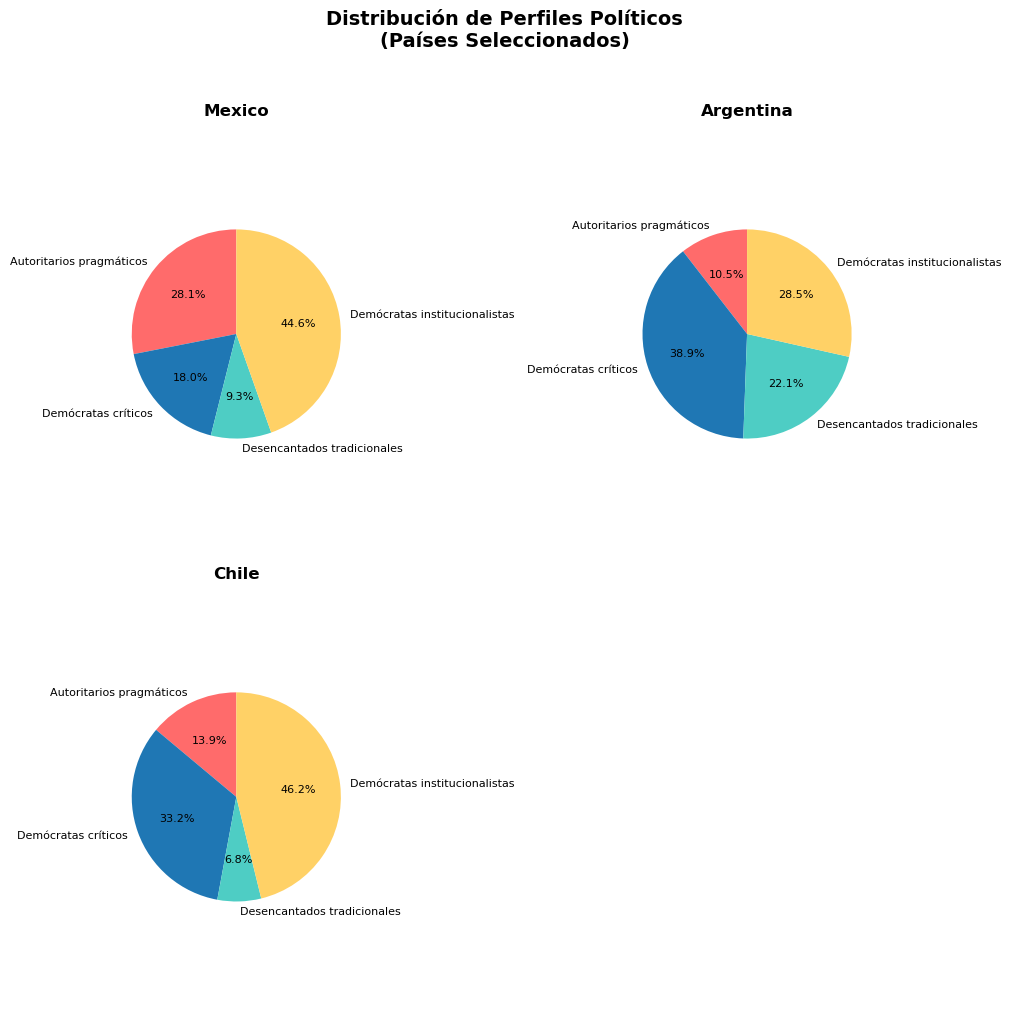

✅ Gráfico 3 guardado como: grafico3_paises_seleccionados.png


In [42]:
# ============================================================
# GRÁFICO 3: PERFILES EN PAÍSES SELECCIONADOS
# ============================================================

print("="*60)
print("GRÁFICO 3: PERFILES EN PAÍSES SELECCIONADOS")
print("="*60)

import matplotlib.pyplot as plt

if 'pais' in df.columns and 'cluster' in df_analisis.columns:
    # Recrear tabla (mismo código que gráfico 2 para consistencia)
    tabla_pais_cluster = pd.crosstab(df_analisis['cluster'], df.loc[df_analisis.index, 'pais'], 
                                     normalize='columns') * 100
    tabla_pais_cluster.index = [nombres_finales[i] for i in tabla_pais_cluster.index]
    
    dict_paises = {
        32: 'Argentina', 68: 'Bolivia', 76: 'Brasil', 152: 'Chile', 170: 'Colombia',
        188: 'Costa Rica', 214: 'Rep. Dominicana', 218: 'Ecuador', 222: 'El Salvador',
        320: 'Guatemala', 340: 'Honduras', 484: 'Mexico', 591: 'Panama', 600: 'Paraguay',
        604: 'Peru', 858: 'Uruguay', 862: 'Venezuela'
    }
    
    tabla_pais_cluster.columns = [dict_paises.get(col, col) for col in tabla_pais_cluster.columns]
    
    # Seleccionar países representativos
    paises_seleccionados = ['Mexico', 'Brazil', 'Argentina', 'Chile']
    paises_disponibles = [p for p in paises_seleccionados if p in tabla_pais_cluster.columns]
    
    if len(paises_disponibles) >= 2:
        # Crear figura con subgráficos
        n_paises = len(paises_disponibles)
        n_cols = min(2, n_paises)
        n_rows = (n_paises + 1) // 2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
        if n_paises > 1:
            axes = axes.flatten()
        else:
            axes = [axes]
        
        # Paleta de colores
        paleta_perfiles = {
            'Autoritarios pragmáticos': '#ff6b6b',
            'Demócratas críticos': '#1f77b4',
            'Desencantados tradicionales': '#4ecdc4',
            'Demócratas institucionalistas': '#ffd166'
        }
        
        for idx, pais in enumerate(paises_disponibles):
            datos_pais = tabla_pais_cluster[pais]
            
            # Filtrar valores mayores a 5% para mejor visualización
            datos_vis = datos_pais[datos_pais > 5].copy()
            otros = datos_pais[datos_pais <= 5].sum()
            
            if otros > 0:
                datos_vis['Otros perfiles'] = otros
            
            # Colores consistentes
            colores_pais = []
            for perfil in datos_vis.index:
                if perfil in paleta_perfiles:
                    colores_pais.append(paleta_perfiles[perfil])
                else:
                    colores_pais.append('#999999')
            
            axes[idx].pie(datos_vis.values, labels=datos_vis.index, colors=colores_pais,
                         autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
            axes[idx].set_title(f'{pais}', fontsize=12, fontweight='bold')
            axes[idx].axis('equal')
        
        # Ocultar ejes vacíos si los hay
        for idx in range(len(paises_disponibles), len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle('Distribución de Perfiles Políticos\n(Países Seleccionados)', 
                    fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('grafico3_paises_seleccionados.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        
        print(" Gráfico 3 guardado como: grafico3_paises_seleccionados.png")
    else:
        print("  No hay suficientes países seleccionados disponibles")
else:
    print("  No se encontraron datos de país")

GRÁFICO 4: DISTRIBUCIÓN POR EDAD


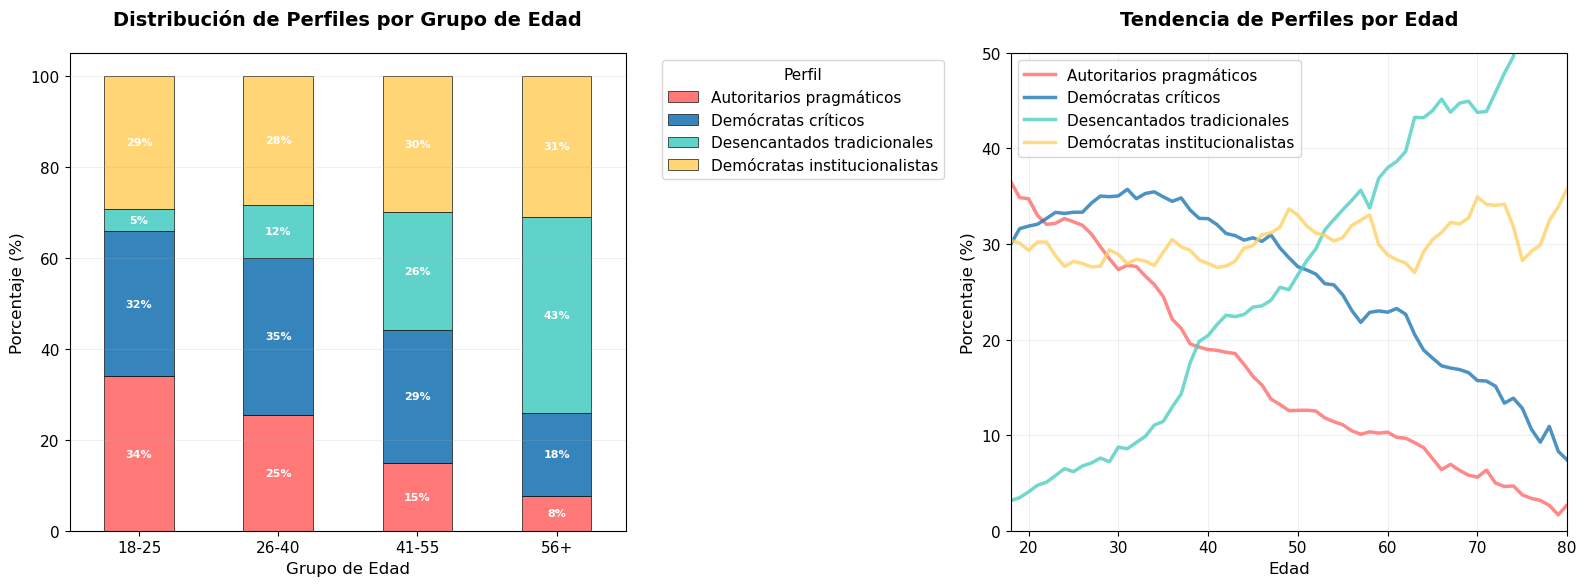

✅ Gráfico 4 guardado como: grafico4_perfiles_por_edad.png


In [43]:
# ============================================================
# GRÁFICO 4: DISTRIBUCIÓN POR EDAD
# ============================================================

print("="*60)
print("GRÁFICO 4: DISTRIBUCIÓN POR EDAD")
print("="*60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Crear categorías de edad
df_analisis['grupo_edad'] = pd.cut(df_analisis['edad'], 
                                   bins=[0, 25, 40, 55, 100], 
                                   labels=['18-25', '26-40', '41-55', '56+'])

# Tabla de contingencia edad vs perfil
tabla_edad = pd.crosstab(df_analisis['grupo_edad'], df_analisis['cluster'], normalize='index') * 100
tabla_edad.columns = [nombres_finales[col] for col in tabla_edad.columns]

# Crear figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Paleta de colores
paleta_perfiles = {
    'Autoritarios pragmáticos': '#ff6b6b',
    'Demócratas críticos': '#1f77b4',
    'Desencantados tradicionales': '#4ecdc4',
    'Demócratas institucionalistas': '#ffd166'
}

colores_edad = [paleta_perfiles[col] for col in tabla_edad.columns]

# --- SUBGRÁFICO 1: BARRAS APILADAS ---
tabla_edad.plot(kind='bar', stacked=True, ax=ax1, color=colores_edad, 
               edgecolor='black', linewidth=0.5, alpha=0.9)

ax1.set_xlabel('Grupo de Edad', fontsize=12)
ax1.set_ylabel('Porcentaje (%)', fontsize=12)
ax1.set_title('Distribución de Perfiles por Grupo de Edad', 
              fontsize=14, fontweight='bold', pad=20)
ax1.legend(title='Perfil', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.2, axis='y')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Añadir etiquetas de porcentaje
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f%%', label_type='center', 
                  fontsize=8, color='white', fontweight='bold')

# --- SUBGRÁFICO 2: TENDENCIA POR EDAD (LÍNEAS) ---
# Calcular tendencias suavizadas
edades_unicas = sorted(df_analisis['edad'].dropna().unique())
tendencias = {perfil: [] for perfil in nombres_finales.values()}

for edad in edades_unicas:
    mask = (df_analisis['edad'] >= edad - 2) & (df_analisis['edad'] <= edad + 2)
    if mask.sum() > 50:  # Solo si hay suficientes casos
        distribucion = df_analisis.loc[mask, 'cluster'].value_counts(normalize=True) * 100
        for cluster_id, perfil in nombres_finales.items():
            tendencias[perfil].append(distribucion.get(cluster_id, 0))
    else:
        for perfil in nombres_finales.values():
            tendencias[perfil].append(np.nan)

# Graficar tendencias
for perfil in nombres_finales.values():
    if len(tendencias[perfil]) == len(edades_unicas):
        # Filtrar NaN
        edades_filtradas = []
        valores_filtrados = []
        for edad, valor in zip(edades_unicas, tendencias[perfil]):
            if not np.isnan(valor):
                edades_filtradas.append(edad)
                valores_filtrados.append(valor)
        
        if len(edades_filtradas) > 1:
            ax2.plot(edades_filtradas, valores_filtrados, label=perfil, 
                    color=paleta_perfiles[perfil], linewidth=2.5, alpha=0.8)

ax2.set_xlabel('Edad', fontsize=12)
ax2.set_ylabel('Porcentaje (%)', fontsize=12)
ax2.set_title('Tendencia de Perfiles por Edad', 
              fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.2)
ax2.set_xlim(18, 80)
ax2.set_ylim(0, 50)

plt.tight_layout()
plt.savefig('grafico4_perfiles_por_edad.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(" Gráfico 4 guardado como: grafico4_perfiles_por_edad.png")

GRÁFICO 5: DISTRIBUCIÓN POR EDUCACIÓN


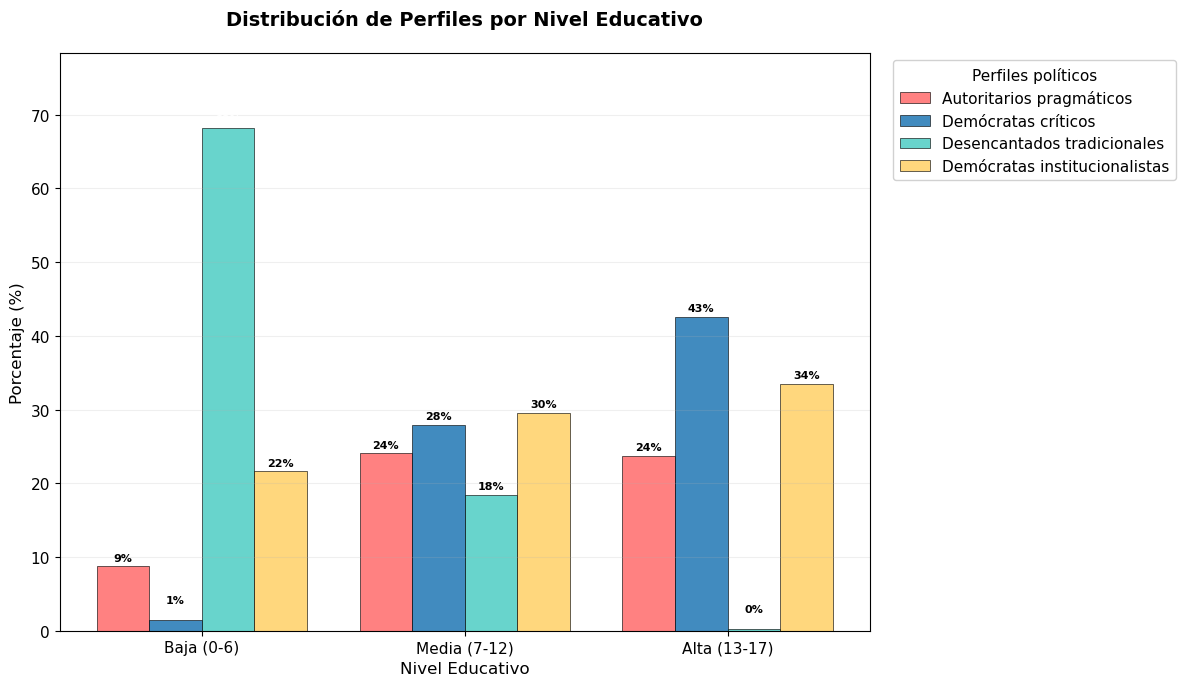

✅ Gráfico 5 guardado como: grafico5_perfiles_por_educacion.png


In [48]:
# ============================================================
# GRÁFICO 5: DISTRIBUCIÓN POR EDUCACIÓN (VERSIÓN CORREGIDA)
# ============================================================

print("="*60)
print("GRÁFICO 5: DISTRIBUCIÓN POR EDUCACIÓN")
print("="*60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Crear categorías de educación
df_analisis['nivel_educativo'] = pd.cut(df_analisis['educacion_anios'], 
                                        bins=[-2, 6, 12, 17, 20], 
                                        labels=['Baja (0-6)', 'Media (7-12)', 'Alta (13-17)', 'Muy alta (18+)'])

# Tabla de contingencia
tabla_educ = pd.crosstab(df_analisis['nivel_educativo'], df_analisis['cluster'], normalize='index') * 100
tabla_educ.columns = [nombres_finales[col] for col in tabla_educ.columns]

# Crear figura
fig, ax = plt.subplots(figsize=(12, 7))

# Paleta de colores
paleta_perfiles = {
    'Autoritarios pragmáticos': '#ff6b6b',
    'Demócratas críticos': '#1f77b4',
    'Desencantados tradicionales': '#4ecdc4',
    'Demócratas institucionalistas': '#ffd166'
}

# Gráfico de barras agrupadas
x = np.arange(len(tabla_educ.index))
width = 0.2

for i, perfil in enumerate(tabla_educ.columns):
    valores = tabla_educ[perfil].values
    ax.bar(x + i*width - 0.3, valores, width, label=perfil, 
           color=paleta_perfiles[perfil], alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Nivel Educativo', fontsize=12)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('Distribución de Perfiles por Nivel Educativo', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(tabla_educ.index, rotation=0)

# Mover leyenda fuera del área de gráfico para mejor visibilidad
ax.legend(title='Perfiles políticos', loc='upper left', bbox_to_anchor=(1.02, 1), 
          frameon=True, framealpha=0.9)

ax.grid(True, alpha=0.2, axis='y')

# **ELIMINADO: Líneas de tendencia que causaban el efecto "telaraña"**
# for i, perfil in enumerate(tabla_educ.columns):
#     valores = tabla_educ[perfil].values
#     ax.plot(x + i*width - 0.3, valores, color=paleta_perfiles[perfil], 
#             linewidth=1.5, alpha=0.7, marker='o', markersize=6)

# Añadir etiquetas de valor encima de las barras (mejorado)
for i, perfil in enumerate(tabla_educ.columns):
    valores = tabla_educ[perfil].values
    for j, valor in enumerate(valores):
        # Ajustar posición vertical para evitar superposición
        y_pos = valor + 0.5 if valor > 5 else valor + 2
        color_texto = 'white' if valor > 50 else 'black'  # Texto blanco en barras oscuras
        ax.text(x[j] + i*width - 0.3, y_pos, f'{valor:.0f}%', 
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                color=color_texto)

# Ajustar límites del eje Y para dar espacio a las etiquetas
ax.set_ylim(0, max([max(tabla_educ[perfil].values) for perfil in tabla_educ.columns]) * 1.15)

# Ajustar márgenes para dar espacio a la leyenda
plt.subplots_adjust(right=0.85)

plt.tight_layout()
plt.savefig('grafico5_perfiles_por_educacion.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(" Gráfico 5 guardado como: grafico5_perfiles_por_educacion.png")

In [50]:
# ============================================================
# VERIFICACIÓN DE VARIABLES DISPONIBLES
# ============================================================

print("="*60)
print("VERIFICANDO VARIABLES DISPONIBLES PARA GRÁFICOS")
print("="*60)

# Listar todas las columnas en df (tu DataFrame original)
print(" VARIABLES EN EL DATAFRAME ORIGINAL (primeras 20):")
print("-"*50)
for i, col in enumerate(df.columns[:20]):
    print(f"  {i+1:2d}. {col}")
    if i >= 19:
        print(f"  ... (total: {len(df.columns)} variables)")
        break

# Verificar específicamente variables demográficas comunes
variables_demo = ['sexo', 'genero', 'gender', 'q1', 'q2', 'edad', 'educacion', 
                  'region', 'pais', 'estrato', 'ingreso', 'urbano', 'rural']

print("\n BUSCANDO VARIABLES DEMOGRÁFICAS:")
print("-"*50)
for var in variables_demo:
    if var in df.columns:
        print(f"  ✓ '{var}' encontrada")
        # Mostrar valores únicos si es categórica
        if df[var].dtype == 'object' or len(df[var].unique()) < 10:
            print(f"    Valores: {df[var].unique()[:10]}")
    else:
        # Buscar variaciones del nombre
        matching = [col for col in df.columns if var in col.lower()]
        if matching:
            print(f"  ≈ Posibles matches para '{var}': {matching}")

print("\n💡 SUGERENCIAS BASADAS EN TUS DATOS:")
print("-"*50)

# Ya sabemos que tienes: edad, educación_anios, pais
print("1. Ya tenemos gráficos para: Edad, Educación, País")
print("2. Podríamos hacer gráficos para:")
print("   - Distribución urbano/rural (si existe)")
print("   - Nivel socioeconómico o ingreso")
print("   - Región dentro de cada país")
print("   - Participación política o interés en política")
print("   - Uso de medios o redes sociales")

# Por favor dime:
# 1. ¿Qué variable de género/sexo tienes? (nombre exacto)
# 2. ¿Qué otras variables demográficas o políticas te interesan?

VERIFICANDO VARIABLES DISPONIBLES PARA GRÁFICOS
📋 VARIABLES EN EL DATAFRAME ORIGINAL (primeras 20):
--------------------------------------------------
   1. pais
   2. sexo
   3. edad
   4. satisfaccion_vida
   5. situacion_pais
   6. economia_actual
   7. economia_vs12m
   8. economia_12m_futuro
   9. confianza_interpersonal
  10. preferencia_democracia
  11. satisfaccion_democracia
  12. satisfaccion_economia
  13. aprueba_presidente
  14. ideologia_izq_der
  15. justicia_distributiva
  16. nivel_democratico_pais
  17. elecciones_limpias
  18. inmigrantes_ayudan_economia
  19. inmigrantes_compiten_trabajo
  20. inmigrantes_aumentan_crimen
  ... (total: 49 variables)

🔍 BUSCANDO VARIABLES DEMOGRÁFICAS:
--------------------------------------------------
  ✓ 'sexo' encontrada
    Valores: ['Mujer' 'Hombre']
  ✓ 'edad' encontrada
  ≈ Posibles matches para 'educacion': ['educacion_anios']
  ✓ 'pais' encontrada
  ≈ Posibles matches para 'ingreso': ['suficiencia_ingresos']

💡 SUGERENCIAS BA

GRÁFICO: DISTRIBUCIÓN DE PERFILES POR SEXO


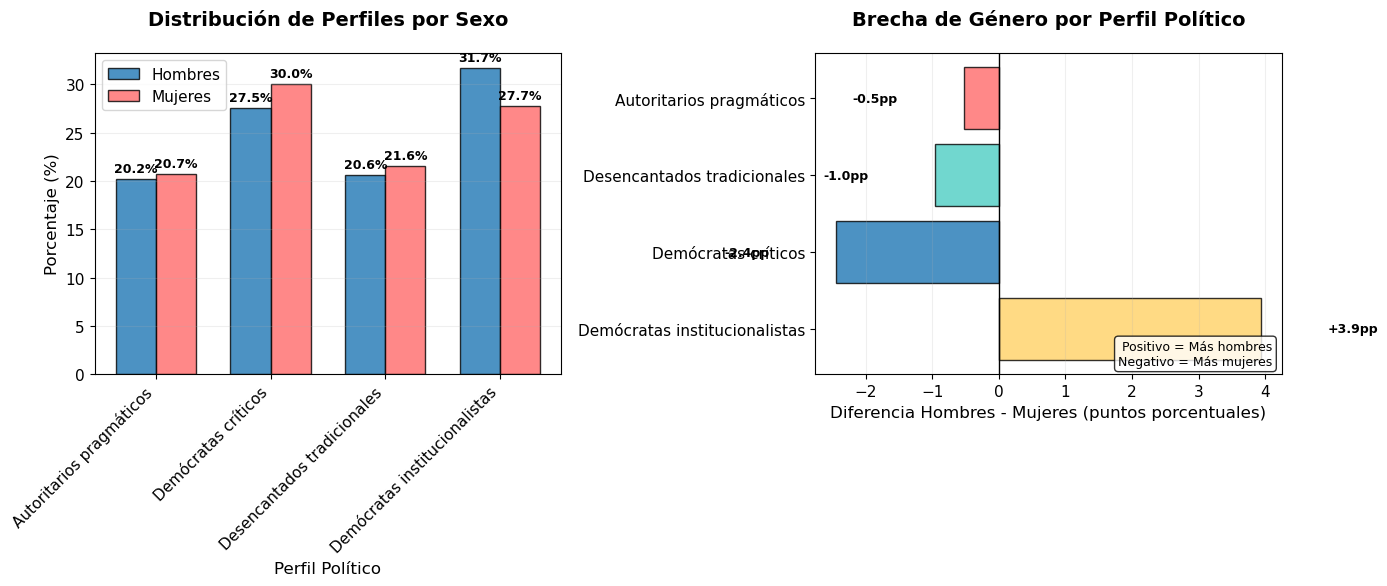

✅ Gráfico guardado como: grafico_perfiles_por_sexo.png

📊 ESTADÍSTICAS POR SEXO:
------------------------------------------------------------
Perfil                              Hombres    Mujeres    Diferencia  
------------------------------------------------------------
Autoritarios pragmáticos            20.2      % 20.7      % -0.5 pp
Demócratas críticos                 27.5      % 30.0      % -2.4 pp
Desencantados tradicionales         20.6      % 21.6      % -1.0 pp
Demócratas institucionalistas       31.7      % 27.7      % +3.9 pp


In [51]:
# ============================================================
# GRÁFICO POR SEXO 1: DISTRIBUCIÓN DE PERFILES POR GÉNERO
# ============================================================

print("="*60)
print("GRÁFICO: DISTRIBUCIÓN DE PERFILES POR SEXO")
print("="*60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Preparar datos
df_analisis['sexo'] = df.loc[df_analisis.index, 'sexo']

# Filtrar solo Hombre/Mujer (por si hay otros valores)
df_analisis_filtrado = df_analisis[df_analisis['sexo'].isin(['Hombre', 'Mujer'])]

# Crear tabla de contingencia
tabla_sexo = pd.crosstab(df_analisis_filtrado['sexo'], 
                         df_analisis_filtrado['cluster'], 
                         normalize='index') * 100

# Renombrar columnas
tabla_sexo.columns = [nombres_finales[col] for col in tabla_sexo.columns]

# Crear figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Paleta de colores para perfiles
paleta_perfiles = {
    'Autoritarios pragmáticos': '#ff6b6b',
    'Demócratas críticos': '#1f77b4',
    'Desencantados tradicionales': '#4ecdc4',
    'Demócratas institucionalistas': '#ffd166'
}

# --- SUBGRÁFICO 1: BARRAS AGRUPADAS ---
x = np.arange(len(tabla_sexo.columns))
width = 0.35

# Barras para hombres
valores_hombres = tabla_sexo.loc['Hombre'].values
rects1 = ax1.bar(x - width/2, valores_hombres, width, 
                label='Hombres', color='#1f77b4', alpha=0.8, edgecolor='black')

# Barras para mujeres  
valores_mujeres = tabla_sexo.loc['Mujer'].values
rects2 = ax1.bar(x + width/2, valores_mujeres, width, 
                label='Mujeres', color='#ff6b6b', alpha=0.8, edgecolor='black')

# Configurar
ax1.set_xlabel('Perfil Político', fontsize=12)
ax1.set_ylabel('Porcentaje (%)', fontsize=12)
ax1.set_title('Distribución de Perfiles por Sexo', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(tabla_sexo.columns, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.2, axis='y')

# Añadir etiquetas de valor
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                   xy=(rect.get_x() + rect.get_width() / 2, height),
                   xytext=(0, 3), textcoords='offset points',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1, ax1)
autolabel(rects2, ax1)

# --- SUBGRÁFICO 2: GRÁFICO DE PASTEL COMPARATIVO ---
# Calcular diferencias Hombre vs Mujer
diferencias = []
for perfil in tabla_sexo.columns:
    diff = tabla_sexo.loc['Hombre', perfil] - tabla_sexo.loc['Mujer', perfil]
    diferencias.append({
        'perfil': perfil,
        'diferencia': diff,
        'color': paleta_perfiles[perfil]
    })

# Ordenar por diferencia absoluta
diferencias.sort(key=lambda x: abs(x['diferencia']), reverse=True)

# Crear gráfico de barras horizontales
perfiles = [d['perfil'] for d in diferencias]
diffs = [d['diferencia'] for d in diferencias]
colores = [d['color'] for d in diferencias]

# Crear barras (positivas = más hombres, negativas = más mujeres)
bars = ax2.barh(perfiles, diffs, color=colores, alpha=0.8, edgecolor='black')

# Configurar
ax2.set_xlabel('Diferencia Hombres - Mujeres (puntos porcentuales)', fontsize=12)
ax2.set_title('Brecha de Género por Perfil Político', fontsize=14, fontweight='bold', pad=20)
ax2.axvline(x=0, color='black', linewidth=1)
ax2.grid(True, alpha=0.2, axis='x')

# Añadir etiquetas
for bar, diff in zip(bars, diffs):
    width = bar.get_width()
    x_pos = width + (1 if width >= 0 else -1)
    ha = 'left' if width >= 0 else 'right'
    color = 'black'
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2, 
            f'{diff:+.1f}pp', va='center', ha=ha, fontsize=9, fontweight='bold', color=color)

# Añadir anotación explicativa
ax2.text(0.98, 0.02, 'Positivo = Más hombres\nNegativo = Más mujeres', 
        transform=ax2.transAxes, fontsize=9, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('grafico_perfiles_por_sexo.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(" Gráfico guardado como: grafico_perfiles_por_sexo.png")

# Imprimir estadísticas
print("\n ESTADÍSTICAS POR SEXO:")
print("-"*60)
print(f"{'Perfil':<35} {'Hombres':<10} {'Mujeres':<10} {'Diferencia':<12}")
print("-"*60)
for perfil in tabla_sexo.columns:
    h = tabla_sexo.loc['Hombre', perfil]
    m = tabla_sexo.loc['Mujer', perfil]
    diff = h - m
    print(f"{perfil:<35} {h:<10.1f}% {m:<10.1f}% {diff:+.1f} pp")

GRÁFICO: PIRÁMIDE POLÍTICA POR EDAD Y SEXO


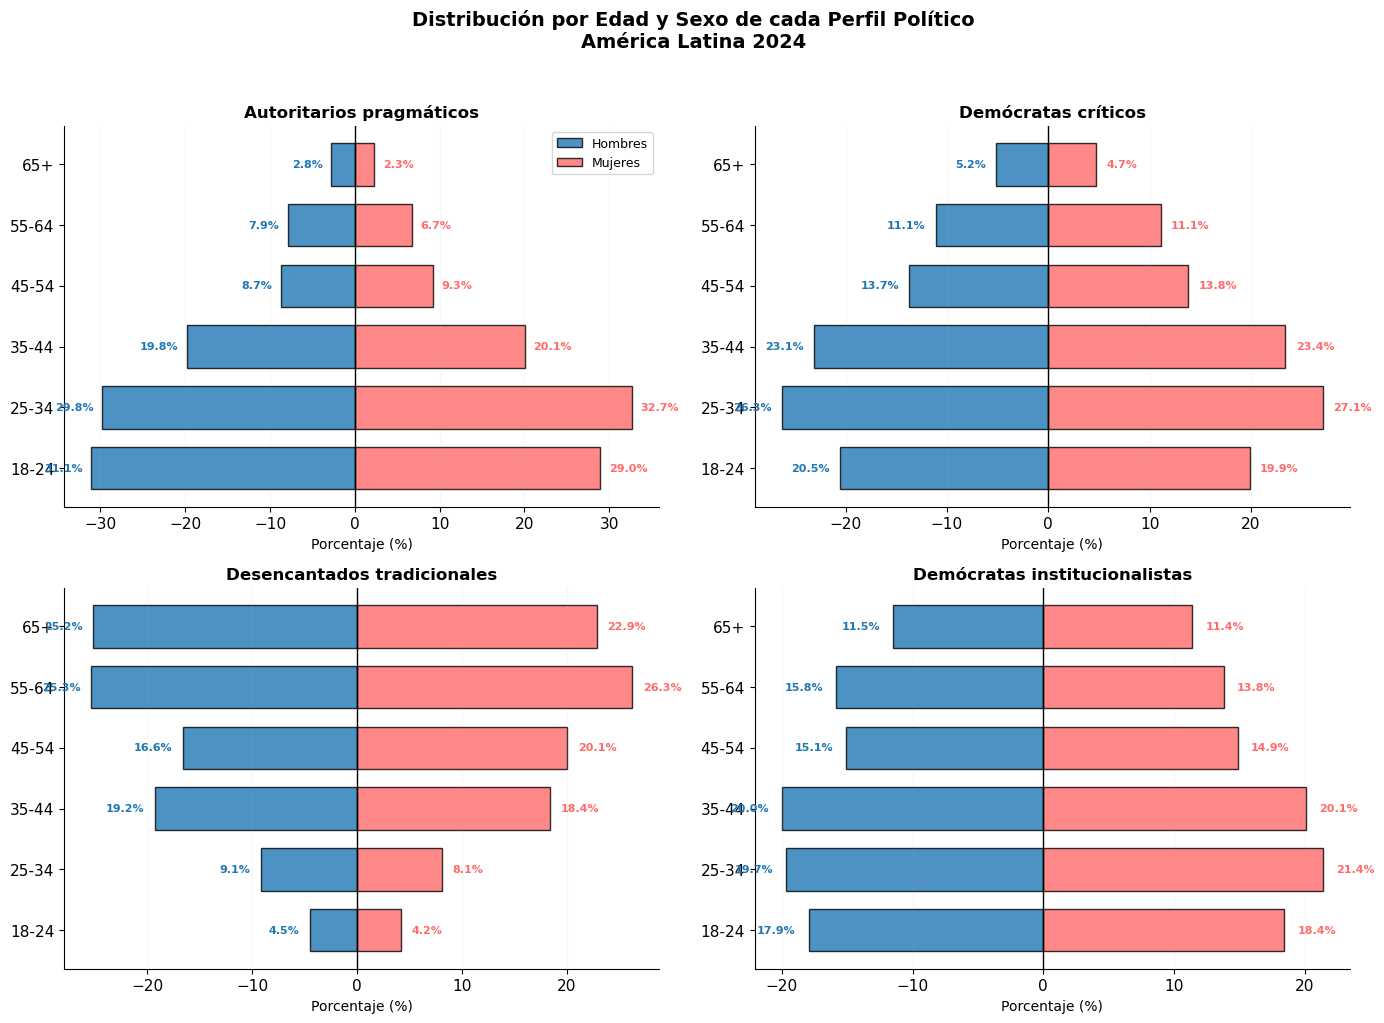

✅ Gráfico guardado como: piramide_edad_sexo_perfiles.png


In [52]:
# ============================================================
# GRÁFICO POR SEXO 2: PIRÁMIDE POLÍTICA POR EDAD Y SEXO
# ============================================================

print("="*60)
print("GRÁFICO: PIRÁMIDE POLÍTICA POR EDAD Y SEXO")
print("="*60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Preparar datos
df_analisis['sexo'] = df.loc[df_analisis.index, 'sexo']

# Crear grupos de edad
bins_edad = [18, 25, 35, 45, 55, 65, 100]
labels_edad = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_analisis['grupo_edad'] = pd.cut(df_analisis['edad'], bins=bins_edad, labels=labels_edad)

# Filtrar solo Hombre/Mujer
df_filtrado = df_analisis[df_analisis['sexo'].isin(['Hombre', 'Mujer'])]

# Crear figura con 4 subgráficos (uno por perfil)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Colores para hombres y mujeres
color_hombres = '#1f77b4'  # Azul
color_mujeres = '#ff6b6b'  # Rojo

# Para cada perfil político
for idx, (cluster_id, perfil_nombre) in enumerate(nombres_finales.items()):
    ax = axes[idx]
    
    # Filtrar por perfil
    mask_perfil = df_filtrado['cluster'] == cluster_id
    
    # Distribución por edad y sexo
    tabla = pd.crosstab(
        df_filtrado.loc[mask_perfil, 'grupo_edad'],
        df_filtrado.loc[mask_perfil, 'sexo'],
        normalize='columns'
    ) * 100
    
    # Asegurar que tengamos todas las edades
    tabla = tabla.reindex(labels_edad, fill_value=0)
    
    # Obtener valores
    if 'Hombre' in tabla.columns:
        valores_hombres = tabla['Hombre'].values
    else:
        valores_hombres = np.zeros(len(labels_edad))
        
    if 'Mujer' in tabla.columns:
        valores_mujeres = tabla['Mujer'].values
    else:
        valores_mujeres = np.zeros(len(labels_edad))
    
    # Crear pirámide (barras horizontales)
    y_pos = np.arange(len(labels_edad))
    
    # Barras a la izquierda (Hombres) - valores negativos
    bars_h = ax.barh(y_pos, -valores_hombres, height=0.7, 
                    color=color_hombres, alpha=0.8, edgecolor='black', label='Hombres')
    
    # Barras a la derecha (Mujeres) - valores positivos
    bars_m = ax.barh(y_pos, valores_mujeres, height=0.7,
                    color=color_mujeres, alpha=0.8, edgecolor='black', label='Mujeres')
    
    # Configurar
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels_edad)
    ax.set_xlabel('Porcentaje (%)', fontsize=10)
    ax.set_title(f'{perfil_nombre}', fontsize=12, fontweight='bold')
    
    # Línea vertical central
    ax.axvline(x=0, color='black', linewidth=1)
    
    # Grid sutil
    ax.grid(True, alpha=0.1, axis='x')
    
    # Quitar bordes superior y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Añadir etiquetas de valor
    for i, (h, m) in enumerate(zip(valores_hombres, valores_mujeres)):
        if h > 0.5:  # Solo mostrar si > 0.5%
            ax.text(-h-1, i, f'{h:.1f}%', va='center', ha='right', 
                   fontsize=8, fontweight='bold', color=color_hombres)
        if m > 0.5:
            ax.text(m+1, i, f'{m:.1f}%', va='center', ha='left', 
                   fontsize=8, fontweight='bold', color=color_mujeres)
    
    # Solo mostrar leyenda en el primer gráfico
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

# Título general
plt.suptitle('Distribución por Edad y Sexo de cada Perfil Político\nAmérica Latina 2024', 
            fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('piramide_edad_sexo_perfiles.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(" Gráfico guardado como: piramide_edad_sexo_perfiles.png")

GRÁFICO 7: RESUMEN ESTADÍSTICO TABULAR


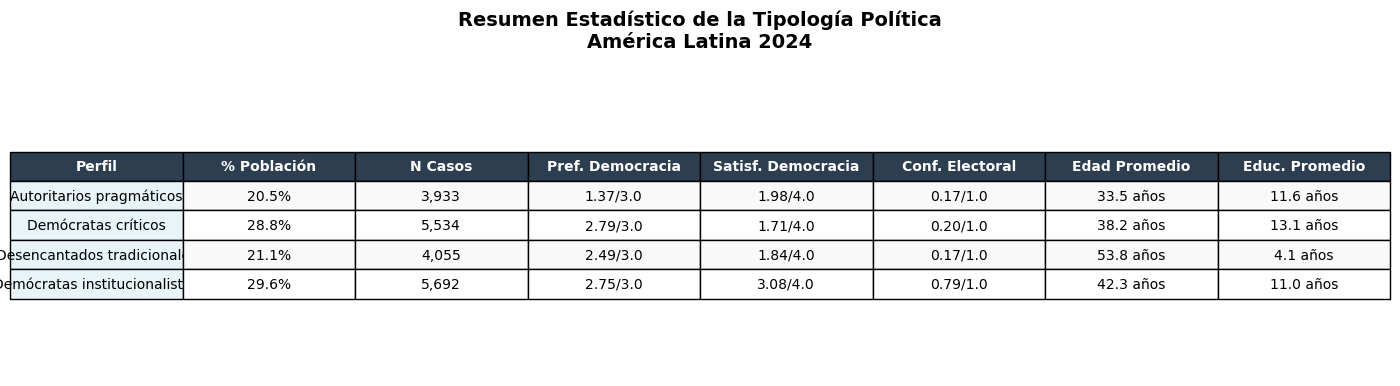

✅ Gráfico 7 guardado como: grafico7_resumen_tabular.png
✅ Datos guardados como: resumen_tipologia_politica.csv

📋 RESUMEN TABULAR:
--------------------------------------------------------------------------------
                       Perfil % Población N Casos Pref. Democracia Satisf. Democracia Conf. Electoral Edad Promedio Educ. Promedio
     Autoritarios pragmáticos       20.5%   3,933         1.37/3.0           1.98/4.0        0.17/1.0     33.5 años      11.6 años
          Demócratas críticos       28.8%   5,534         2.79/3.0           1.71/4.0        0.20/1.0     38.2 años      13.1 años
  Desencantados tradicionales       21.1%   4,055         2.49/3.0           1.84/4.0        0.17/1.0     53.8 años       4.1 años
Demócratas institucionalistas       29.6%   5,692         2.75/3.0           3.08/4.0        0.79/1.0     42.3 años      11.0 años


In [55]:
# ============================================================
# GRÁFICO 7: RESUMEN ESTADÍSTICO TABULAR
# ============================================================

print("="*60)
print("GRÁFICO 7: RESUMEN ESTADÍSTICO TABULAR")
print("="*60)

import pandas as pd
import matplotlib.pyplot as plt

# Crear DataFrame resumen
resumen_exportar = pd.DataFrame({
    'Perfil': [nombres_finales[i] for i in range(4)],
    '% Población': [f"{estadisticas_clusters[i]['porcentaje']:.1f}%" for i in range(4)],
    'N Casos': [f"{estadisticas_clusters[i]['tamaño']:,}" for i in range(4)],
    'Pref. Democracia': [f"{resumen_df.loc['preferencia_democracia', f'Cluster {i}']:.2f}/3.0" for i in range(4)],
    'Satisf. Democracia': [f"{resumen_df.loc['satisfaccion_democracia', f'Cluster {i}']:.2f}/4.0" for i in range(4)],
    'Conf. Electoral': [f"{resumen_df.loc['elecciones_limpias', f'Cluster {i}']:.2f}/1.0" for i in range(4)],
    'Edad Promedio': [f"{resumen_df.loc['edad', f'Cluster {i}']:.1f} años" for i in range(4)],
    'Educ. Promedio': [f"{resumen_df.loc['educacion_anios', f'Cluster {i}']:.1f} años" for i in range(4)]
})

# Crear figura para tabla
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('tight')
ax.axis('off')

# Crear tabla
tabla = ax.table(cellText=resumen_exportar.values,
                 colLabels=resumen_exportar.columns,
                 cellLoc='center',
                 loc='center',
                 colColours=['#f0f0f0']*len(resumen_exportar.columns))

# Formatear tabla
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.8)

# Colorear filas alternadamente
for i in range(len(resumen_exportar)):
    if i % 2 == 0:
        for j in range(len(resumen_exportar.columns)):
            tabla[(i+1, j)].set_facecolor('#f9f9f9')

# Colorear primera columna (nombres de perfiles)
for i in range(len(resumen_exportar)):
    tabla[(i+1, 0)].set_facecolor('#e8f4f8')  # Azul muy claro

# Resaltar encabezados
for j in range(len(resumen_exportar.columns)):
    tabla[(0, j)].set_facecolor('#2c3e50')  # Azul oscuro
    tabla[(0, j)].set_text_props(weight='bold', color='white')

ax.set_title('Resumen Estadístico de la Tipología Política\nAmérica Latina 2024', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('grafico7_resumen_tabular.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# También guardar como CSV
resumen_exportar.to_csv('resumen_tipologia_politica.csv', index=False, encoding='utf-8-sig')

print(" Gráfico 7 guardado como: grafico7_resumen_tabular.png")
print(" Datos guardados como: resumen_tipologia_politica.csv")
print("\n📋 RESUMEN TABULAR:")
print("-"*80)
print(resumen_exportar.to_string(index=False))